# 1. Rationale

### 1.1 Why the weights cannot be tuned on the training objective

The cost function that trains every logical-gate pulse in this project is a fidelity plus three
penalty terms, evaluated on a waveform that is itself a *constrained function* of the raw
optimizer variable $x$:

$$\mathcal{C}(x) \;=\; -\,\overline{F_{\mathrm{coh}}}(u)
\;+\; \lambda_{\mathrm{disc}}\!\!\sum_{i\neq j}\!(F_i-F_j)^2
\;+\; \lambda_{\mathrm{deriv}}\, g_d(u)
\;+\; \lambda_{\mathrm{amp}}\, g_a(u),
\qquad u \;=\; \underbrace{\mathrm{env}(T_{\mathrm{ramp}})}_{\text{ramp}} \odot\;
\underbrace{P(x)}_{\text{band limit}}$$

**Reading the second equation.** L-BFGS-B never touches the pulse directly. It varies a raw
*pre-image* $x$, and the waveform the physics sees is what comes out of a two-stage chain applied
to it. Read the product **right to left**:

| symbol | what it is |
|---|---|
| $x$ | the raw optimizer variable: $(550, 4)$ real numbers — cavity $I,Q$ and transmon $I,Q$ at each 2 ns step. Not a physical pulse. `hard_amp_limit` boxes *this*. |
| $P(x)$ | **the frequency band limit.** $\mathrm{IFFT}\circ\mathrm{mask}\circ\mathrm{FFT}$, applied to each complex drive ($\epsilon_C = x_0 + ix_1$, $\epsilon_T = x_2 + ix_3$) on its own: every Fourier component outside $\pm27$ MHz (cavity) or $\pm33$ MHz (transmon) is set to **exactly zero**. These are baseband quadratures, so that is a bandpass of full width 54 / 66 MHz about each drive's carrier once up-converted. |
| $\mathrm{env}(T_{\mathrm{ramp}}) \odot$ | **the ramp envelope.** One real 550-long window — a pedestal-subtracted Gaussian with $\sigma = T_{\mathrm{ramp}}/2$, near zero at both ends and exactly 1 across the flat top — multiplied in element-wise at each time step, the same window on all four quadratures. It forces the drive to switch on and off smoothly. |

So the order is **band-limit first, then ramp**: $x \rightarrow$ filter $\rightarrow$ taper the
edges $\rightarrow u$. That order is a measured choice rather than a convention. Ramping last is
what actually pulls the endpoints down, and it costs a small out-of-band tail that the projection
had just removed — because multiplying by a finite-duration window puts some power back outside
the mask. §2.3 gives both orderings' numbers and Table 1 measures the tail.

Two consequences to carry forward. **Only $u$ is physical, and only $u$ is ever scored** — every
penalty in $\mathcal{C}$ is evaluated on $u$, never on $x$. And because the chain sits *inside*
the objective, the gradient returns through its adjoint, $P(\mathrm{env} \odot g)$: envelope
first, then project — the mirror image of the forward order (§2.3).

Every $\lambda$ term is a **regularizer**: non-negative, and able only to *raise* the cost.
Tuning the weights against the training objective therefore has exactly one fixed point: all of
them at zero. The optimizer obliges, and returns a pulse that is rougher, wider in bandwidth, and
better at exploiting the finite Hilbert space it trained in. The training number goes up; the
pulse gets worse.

So the weights cannot be chosen by optimizing the quantity they appear in. They have to be chosen
against something training never sees. This notebook does that in three steps: **sweep** the
weights, **score** each candidate on the reported fidelity at held-out cavity truncations, then
**select** under a hardware spectral-width budget.

### 1.2 The three penalty terms, and the one that was removed

| term | definition (`core/grape_core.py`) | what it suppresses |
|---|---|---|
| $g_d$ | $\sum_k \lVert u_{k+1}-u_k\rVert^2$ | step-to-step roughness, hence high-frequency content |
| $g_a$ | $\sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$ | drive amplitude above a soft cap $\epsilon_{\max}$ |
| disc | $\sum_{i\neq j}(F_i-F_j)^2$ over `trunc_list` | fidelity that depends on where the Hilbert space is cut |

The first two are **shape** penalties on the waveform; the third is a **robustness** penalty on
the solution. Only the third touches the physics of the target; the rest are hardware realism.

**A fourth term used to be here, and its absence is the reason this notebook was rebuilt.**
$g_b = \lVert u_0\rVert^2 + \lVert u_{N-1}\rVert^2$ penalized a discontinuous switch-on at the
pulse edges. It was structurally broken: its gradient touched 2 of 550 rows and was then smeared
across all 550 by the circular-FFT band projection $P$, which does not preserve endpoint zeros.
Swept over a full $5\times5$ grid, its marginal effect on held-out fidelity ranged
$8.1\times10^{-4}$–$4.8\times10^{-3}$ — straddling the basin-noise floor and non-monotonic in
every row.

It was **removed outright** and replaced by a *structural* constraint: the raw variable $x$ is
band-limited and then multiplied by a pedestal-subtracted Gaussian envelope,
$u = \mathrm{env} \odot P(x)$, so the endpoint condition is enforced by the parametrization
rather than paid for in the cost. There is no weight left to sweep — but the constraint has a
**duration**, $T_{\mathrm{ramp}}$, and a duration has a cost of its own (§1.4). That is the third
axis of this study.

### 1.3 What each knob is physically for

$\mathcal{C}(x)$ is not a bag of arbitrary regularizers. Each term stands in for something the
Schrödinger equation in `core/grape_core.py` does **not** model — an amplifier that compresses, a
filter that rings, a Hilbert space that was truncated — and each is therefore only as useful as
the hardware scale it is set against. This subsection states those scales once, so §5–§8 can be
read as measurements rather than as a search over unlabelled dials.

The device constants are `core/grape_core.py`'s: $\chi/2\pi = -2.194$ MHz (dispersive shift),
$K/2\pi = -3.7$ kHz (cavity self-Kerr), $\chi'/2\pi = -19$ kHz (second-order dispersive shift),
$\alpha/2\pi = -236$ MHz (transmon anharmonicity). Controls are in rad/µs, so a drive amplitude
$\epsilon$ corresponds to $\epsilon/2\pi$ MHz. The pulse is $N = 550$ steps of
$\mathrm{d}t = 2$ ns.

| knob | acts on | the hardware or model fact behind it | status in this study |
|---|---|---|---|
| $\lambda_{\mathrm{deriv}}$ | waveform slope | DAC reconstruction filter and IQ-mixer bandwidth; in-band power placement | **live** (§6.3) |
| $\epsilon_{\max}$ (via $\lambda_{\mathrm{amp}}$) | peak drive | amplifier compression; validity of the 3-level transmon | **inert at the incumbent**, swept as a threshold (§6.1) |
| $\lambda_{\mathrm{disc}}$ | truncation agreement | $n_c$ is a modelling choice, not a device property | **inert by construction** (§6.1) |
| $T_{\mathrm{ramp}}$ | pulse edges | switch-on transient; pulse concatenation | **structural**, and it works (§6.4) |
| `hard_amp_limit` | pre-image $x$ | the only bound on edge pre-image inflation | **fixed**, and the failure detector (§4) |
| band masks | spectral support | AWG and line bandwidth (Heeres Supp. Eq. 22) | **fixed** |

**$\lambda_{\mathrm{deriv}}$ — the DAC does not play what the optimizer wrote.** At
$\mathrm{d}t = 2$ ns the control grid's Nyquist frequency is 250 MHz, an order above either band
mask, so the mask (§1.6) already removes everything a reconstruction filter would distort *outside*
the band. What it cannot express is a preference *inside* the band: "flat out to the edge" and
"clustered near DC" are equally admissible to an orthogonal projection. That is what $g_d$ charges
for, and it is why this is the knob that moves occupied width — across its ladder $W_{99}$ runs
37.0% → 77.1% of the binding drive's allowance. Two reasons to care beyond aesthetics. A waveform
whose adjacent 2 ns samples differ by an appreciable fraction of the peak is reshaped by the
analog chain before it reaches the fridge, so the commanded and delivered pulses diverge in a way
no term in $\mathcal{C}$ knows about. And power pushed against the mask edge is power where the
mask's own discontinuity sits, so small LO or timing errors move a lot of spectral weight.
The $\lambda_{\mathrm{deriv}} = 0$ control shows what is being bought: 77.1% of the cavity
allowance (10-seed mean; 75.8% on the seed-42 waveform Table 1 dissects), a 33.1 rad/µs peak, and
a drive centred on $\bar n = 5.35$ photons against the incumbent's 2.47 — i.e. addressing number
states well outside the $\alpha^2 = 3$ cat it is supposed to act on.

**$\epsilon_{\max}$ — a guard rail, not a constraint, at the current recipe.** Each quadrature is
a DAC channel feeding an IQ mixer and an amplifier chain with a compression point; above it the
transfer function is nonlinear and the played pulse is not the commanded one. Separately, the
model keeps only $n_t = 3$ transmon levels, which requires the drive to stay far below
$\lvert\alpha\rvert/2\pi = 236$ MHz. The production cap is $\epsilon_{\max} = 40$ rad/µs
$= 6.4$ MHz, and converged pulses peak element-wise at 15.4–21.8 rad/µs ($2.5$–$3.5$ MHz) across
the ten seeds — one to two orders inside both limits. So the term is exactly zero with an exactly zero gradient
(§6.1), which is why the axis has to be the **threshold** and not the weight: the ladder
$\{10, 14, 18, 22, 26, 30\}$ walks the cap down through the pulse's own peak to find where a
peak-power constraint would begin to bite.

**$\lambda_{\mathrm{disc}}$ — a model penalty, and the only one that is not about hardware.** The
cavity is truncated at $n_c$ levels, and a pulse can score well at a given $n_c$ by parking
amplitude in the top few Fock levels, which a truncated model *reflects* rather than leaks. Charging
for disagreement between truncations is meant to price that. Measured, it cannot: the three training
truncations already agree to $\sim\!10^{-4}$, so $\sum_{i\neq j}(F_i-F_j)^2 \sim 10^{-8}$ against an
$O(1)$ fidelity term. What actually catches wall exploitation here is **scoring** on truncations
training never saw (§1.5), which is a selection mechanism rather than a gradient — and is why
widening the held-out set cannot make this term bite (§2.4).

**$T_{\mathrm{ramp}}$ — a drive has to start off, and the line rings if it does not.** The DAC
output passes a finite-bandwidth reconstruction filter and a line with its own group delay. A
waveform that begins at 4–6% of its peak on the first 2 ns sample is a step into that filter, and
the first nanoseconds delivered are not the ones commanded. It matters twice over here, because
the encode → gate → decode pipeline plays three pulses back to back and a nonzero endpoint is a
discontinuity at each seam. This was the $g_b$ penalty's job and it failed (§1.2); as a structural
envelope it succeeds — across the production set `endpoint_rel_to_peak` fell from 6.06% → 1.13%
($U_{\rm opt}$), 4.98% → 0.47% ($T$), 4.75% → 2.39% ($X$), typically $\sim\!3\times$ and up to
$11\times$. The residual has two named causes, and both are the reason the next row of the table
exists: midpoint sampling leaves $\mathrm{env}[0] = 0.0135$ rather than 0, and the envelope
removes control authority over the first and last 24 steps, which L-BFGS-B buys back by inflating
the **pre-image** there ($\lvert P(x)_0\rvert = 30.6$ against a 5.03 mid-pulse RMS on
`u_X_main`).

**`hard_amp_limit` — not a penalty, but the limit that has actually broken a pulse.** It is
L-BFGS-B's box on the raw variable $x$, and it is the *only* thing bounding the edge inflation just
described; the envelope does not bound it. Raising it would quietly give back part of what the ramp
bought. It can also bind, with consequences no fidelity term reveals: retraining $U_Y$ cold at seed
42 drove $\max\lvert x\rvert$ to exactly 40.0 and landed in a 44%-leakage basin whose *training*
fidelity looked healthy (held-out $F_{\mathrm{ped}}$ 0.9973 → 0.7491). Two columns exist in this
sweep to catch that — `max_abs_preimage` and `preimage_at_bound_frac` — and §4 checks them before
any fidelity number here is read.

**The band masks — fixed, and worth sizing against the physics.** $\pm27$ MHz cavity, $\pm33$ MHz
transmon. The cavity's 54 MHz window spans $\approx 25$ number-splitting intervals $\chi/2\pi$, so
there is room to address individual Fock peaks across a several-photon cat and to sit off-centre
while doing it — which is what `n_bar_drive` reads back. Both masks are far inside
$\lvert\alpha\rvert/2\pi = 236$ MHz, so neither drive can reach the transmon's second transition.
These are not swept; they set the denominator every width in this notebook is quoted against.

### 1.4 What the ramp costs, and the hypothesis this sweep tests

$T_{\mathrm{ramp}}$ is not a regularizer and does not belong on a Pareto front. It buys a lower
endpoint amplitude, and it was expected to pay in four currencies:

| lengthening the ramp | effect |
|---|---|
| $\mathrm{env}[0]$: $0.0219 \to 0.0091$ across $30 \to 70$ ns | the drive starts closer to *off* — this is what it buys |
| ramped window: 5.5% $\to$ 12.7% of the 550 steps | control authority is removed at the edges |
| pre-image inflation | L-BFGS-B buys that authority back by inflating $x$, bounded only by `hard_amp_limit` |
| out-of-band energy | the envelope is applied *after* $P$, so it reintroduces a sub-percent spectral tail |

> **That table is the hypothesis, and this sweep tests it. Row 1 survives; row 3 is
> unresolved, having reversed direction as seeds were added.**
> The endpoint does fall with ramp duration, cleanly and near-monotonically ($\rho = -0.94$),
> and that has held at every sample size.
> Pre-image inflation is the open question. At three seeds it showed no relationship to ramp
> duration at all ($\rho = +0.03$, with the *longest* ramp producing the *smallest* pre-image);
> at ten seeds the seed-mean rank correlation between $T_{\mathrm{ramp}}$ and
> $\max\lvert x\rvert$ is $+0.83$, the ladder reaches 79% of the box, and the longest ramp
> produces the largest pre-image. The progression $+0.03 \to +0.54 \to +0.83$ is monotone in the
> number of seeds, which is the signature of an effect that was under-sampled rather than absent.
> It is still not established: within individual seeds the correlation ranges $-0.37$ to $+0.77$
> and **changes sign**, so the clean seed-mean ladder is assembled from per-seed ladders that do
> not agree. $\lambda_{\mathrm{deriv}}$ reaches the same seed-mean magnitude ($\rho = -0.83$)
> while keeping its sign in all ten seeds, so it remains the better-supported driver — the
> derivative penalty is precisely what charges for the large step-to-step excursions an inflated
> pre-image creates. §5.1 and §6.4 show the data. Read `core/ramp.py`'s authority-loss argument
> as a claim about *having* a ramp versus not, at the fixed 48 ns default; on **duration** the
> evidence has moved from refuting it to not yet resolving it, and resolving it needs a
> `hard_amp_limit` ladder (§7.5), not more seeds.

### 1.5 Training objective vs. reported metric

The distinction that runs through the whole notebook:

- $F_{\mathrm{coh}}$: the coherent process fidelity the optimizer actually descends on, averaged
  over the training truncations $n_c \in \{22, 24, 26\}$ (Heeres Supp. Eq. 23). Returned by
  `optimize_multi_state_pulse` as `F_coh_train`.
- $F_{\mathrm{held}}$: the gate fidelity (Pedersen 2007 average-gate-fidelity formula), computed
  from the full $D \times D$ propagator, projected onto the logical subspace
  ($\texttt{logical\_block} = B^\dagger U B$), and evaluated at truncations the pulse never
  trained on. Produced by `main.report_pedersen_gate_fidelity`. **This is the headline number**,
  and it appears throughout as **F**, **F_held** or **mean F_held** — never as "Pedersen
  fidelity". **F_coh** refers only to the training objective.

Their difference is `overfit_gap`. Ranking on $F_{\mathrm{coh}}$ would reward exploitation of the
truncation wall, which is the failure mode the penalties exist to prevent. So it cannot be the
selection metric.

### 1.6 Why the constraint is an occupied-width cap

Bandwidth appears nowhere in $\mathcal{C}(u)$. Three separate mechanisms act on the spectrum, and
only the first two are inside the optimizer:

| # | mechanism | where it acts | what it constrains |
|---|---|---|---|
| 1 | penalties $g_d, g_a$, plus an L-BFGS-B box on the raw variable | inside the cost | waveform shape and amplitude |
| 2 | hard band-limit projection, $\pm27$ MHz cavity / $\pm33$ MHz transmon | `core.fourier_cutoff.project_bandlimit`, applied to $u$ **and** the gradient every iteration | spectral **support**: power is exactly zero outside the band |
| 3 | `occ99_frac` $\leq 0.50$, i.e. $W_{99} \leq 50\%$ of **each drive's own** mask (27.0 MHz cavity, 33.0 MHz transmon), **and** $F_{\mathrm{held}} \geq 0.995$ | `pv.recommend`, after training | spectral **concentration**: how tightly the power packs inside the band |

Rows 2 and 3 are both per-drive and they are not the same limit. Row 2 is **hard**: it is where
power is allowed to exist at all, it is enforced on the controls *and* the gradient at every
iteration, and no choice of penalty weights can violate it. Row 3 is **soft**: it is how much of
that allowance a converged pulse actually consumes, it is checked only after training, and it is
the line a configuration can fail.

**Why mechanism 3 is not redundant with mechanism 2.** The mask is a 0/1 indicator. It says where
power is *allowed*, not how it is arranged, and an orthogonal projection cannot express a
preference: "flat out to the band edge" and "tightly clustered near DC" are equally admissible.
The support is already pinned exactly by the mask, so mechanism 3 charges for how that allowance
is *used*.

**The metric.** For each complex drive $\epsilon_C = u_0 + iu_1$ and $\epsilon_T = u_2 + iu_3$,
`analysis.penalty_sweep.pulse_metrics` computes the **99% occupied width**: the narrowest
frequency window carrying 99% of the power,

$$W_{99} \;=\; \min_{[a,b]}\,(b-a) \quad\text{subject to}\quad
\sum_{a \le f \le b} p(f) \;\ge\; 0.99,
\qquad p(f) = \frac{\lvert\hat\epsilon(f)\rvert^2}{\sum_{f'}\lvert\hat\epsilon(f')\rvert^2},$$

with $f = \texttt{np.fft.fftfreq}(N, \mathrm{d}t)$ in MHz. Dividing by the total power makes it
amplitude-independent: scaling a pulse by $10\times$ leaves it unchanged. The window edges land on
FFT bins, so $W_{99}$ is quantised to $1/(N\,\mathrm{d}t) = 0.909$ MHz. They are also reported
(`occ99_{cav,tra}_{lo,hi}_MHz`), because *where* in the allowed band the power sits is a separate
fact from how wide it is.

**Each drive is charged against its own allowance.** The scored scalar is

$$\texttt{occ99\_frac} \;=\; \max\!\left(\frac{W_{99}^{C}}{54\ \mathrm{MHz}},\;
\frac{W_{99}^{T}}{66\ \mathrm{MHz}}\right),$$

the share of its own allowance consumed by the worse drive. Taking `max` of the two *raw* widths
instead would be a conjunction of two constraints forced to share one threshold, and the drives do
not share an allowance: the cavity mask is $\pm27$ MHz and the transmon's $\pm33$. They are also
separate hardware chains (own LO, mixer, DAC channel, line), so nothing physically experiences the
max of the two. Comparing their raw widths is comparing "20 GB used" on a 50 GB disk against
"25 GB used" on a 100 GB disk. Normalising first restores the correct conjunction,

$$\max(x/a,\, y/b) \leq t \quad\Longleftrightarrow\quad (x \leq ta) \;\wedge\; (y \leq tb),$$

and leaves the budget a dimensionless percentage, which is one fewer thing that can be mis-ported.
§8.3 examines the one configuration where the two normalisations could differ — and finds that at
a 50% budget they no longer do, for reasons that say more about the threshold than the statistic.

**Mechanism 3 has a second half.** The width cap bounds what a recipe may *cost*; a floor
$F_{\mathrm{held}} \geq 0.995$ bounds what it must *deliver*. Both are applied post-hoc by the same
`pv.recommend` call, neither is visible to the optimizer, and a configuration must clear both. The
floor exists because the width cap alone admits recipes that are cheap precisely by being bad —
$\lambda_{\mathrm{deriv}} = 10^{-4}$ is the narrowest configuration in the whole study at 37% of
allowance and does not reach a usable gate (§8.2).

The cell below measures both mechanisms on the two pulses at the centre of this study: the one the
budget accepts and the one it rejects.

In [1]:
# Table 1. Spectral anatomy of the two pulses at the centre of the study.
# Self-contained on purpose: Section 1 precedes the Setup cell, so this must not
# depend on GATE / dt / pv. `core.fourier_cutoff` is numpy-only -- do NOT import
# `analysis.penalty_sweep` here (it pulls in `main`, which calls matplotlib.use("Agg")).
import os, sys
import numpy as np
import pandas as pd

if os.path.abspath(".") not in sys.path:
    sys.path.insert(0, os.path.abspath("."))
from core.fourier_cutoff import make_band_mask

DT = 0.002                                  # us
EDGE = {"cav": 27.0, "tra": 33.0}           # FIXED["cav_band"] / ["tra_band"]
BAND = {d: 2 * e for d, e in EDGE.items()}  # mask WIDTHS: 54 cav / 66 tra
BUDGET_FRAC = 0.50                          # of each drive's OWN mask
CACHE = "results/penalty_sweep_cache/X"
# Post-ramp labels: `boundary` is no longer a penalty, so it no longer appears
# in a label. These are the incumbent and its lambda_deriv = 0 negative control.
PAIR = {"deriv=1e-05_amp=8e-05_disc=0.5": "incumbent (deriv=1e-5)",
        "deriv=0_amp=8e-05_disc=0.5":     "control   (deriv=0)"}

# Seed 42 only: this cell inspects two individual WAVEFORMS, not a seed mean, so
# its shares differ slightly from the 10-seed means quoted everywhere else.
ofat = (pd.read_csv("tables/penalty_sweep_X_ofat_ramp.csv")
          .query("seed == 42").drop_duplicates("label").set_index("label"))


def occ_width(P, f, frac=0.99):
    """Narrowest window holding `frac` of the power, as (width, lo, hi).

    Mirrors `analysis.penalty_sweep.occupied_width`; duplicated rather than
    imported to keep this cell import-light (see the note above)."""
    o = np.argsort(f)                                  # fftfreq is not monotonic
    fs, c = f[o], np.cumsum(P[o] / P.sum())
    b = np.searchsorted(c, np.concatenate(([0.0], c[:-1])) + frac, side="left")
    ok = np.nonzero(b < c.size)[0]
    i = ok[np.argmin(fs[b[ok]] - fs[ok])]
    return fs[b[i]] - fs[i], fs[i], fs[b[i]]


def anatomy(eps, edge):
    """The 99% occupied width and window, and the power outside the band mask."""
    f = np.fft.fftfreq(len(eps), d=DT)                 # cycles/us == MHz
    P = np.abs(np.fft.fft(eps)) ** 2
    P /= P.sum()
    w99, lo, hi = occ_width(P, f)
    return dict(w99=w99, lo=lo, hi=hi,
                outside=P[~make_band_mask(len(eps), DT, -edge, edge)].sum())


print(f"{'':28s}{'W99':>6}{'of mask':>9}{'window':>17}{'outside':>9}")
for label, name in PAIR.items():
    path = f"{CACHE}/u_{ofat.loc[label, 'config_hash']}.npy"
    if not os.path.exists(path):
        print(f"{name}: pulse cache absent -- regenerate with "
              f"`python analysis/penalty_sweep.py --gate X --mode ofat --seeds 42 --maxiter 1500`")
        continue
    u = np.load(path)
    for drive, (i, j) in (("cav", (0, 1)), ("tra", (2, 3))):
        a = anatomy(u[:, i] + 1j * u[:, j], EDGE[drive])
        # Each drive's width is charged against ITS OWN mask, not the wider one.
        print(f"{name + ' ' + drive:28s}{a['w99']:6.2f}{a['w99']/BAND[drive]:9.1%}"
              f"  [{a['lo']:6.2f},{a['hi']:6.2f}]{a['outside']:9.1e}")
    r = ofat.loc[label]
    print(f"{'':28s}recorded occ99_frac = {r['occ99_frac']:.1%} "
          f"(binding: {r['binding_drive']}; occ99_MHz = {r['occ99_MHz']:.2f}, "
          f"n_bar_drive = {r['n_bar_drive']:.2f})")
    print(f"{'':28s}endpoint = {r['endpoint_rel_to_peak']:.2%} of peak; "
          f"out-of-band = {r['out_of_band_cav']:.1e} cav / "
          f"{r['out_of_band_tra']:.1e} tra")

print(f"\nbudget: each drive may occupy at most {BUDGET_FRAC:.0%} of its OWN mask")
print(f"        -> {BUDGET_FRAC*BAND['cav']:.1f} MHz cavity (of {BAND['cav']:.0f}), "
      f"{BUDGET_FRAC*BAND['tra']:.1f} MHz transmon (of {BAND['tra']:.0f}).")
print("        W99 is bounded above by the mask width by construction, so the fraction")
print("        is a genuine share of the attainable range, not a number on an open scale.")

                               W99  of mask           window  outside
incumbent (deriv=1e-5) cav   16.36    30.3%  [ -8.18,  8.18]  3.6e-04
incumbent (deriv=1e-5) tra   33.64    51.0%  [-25.45,  8.18]  1.1e-03
                            recorded occ99_frac = 51.0% (binding: tra; occ99_MHz = 33.64, n_bar_drive = 2.43)
                            endpoint = 2.39% of peak; out-of-band = 3.6e-04 cav / 1.1e-03 tra
control   (deriv=0) cav      40.91    75.8%  [-21.82, 19.09]  6.9e-04
control   (deriv=0) tra      41.82    63.4%  [-33.64,  8.18]  6.2e-03
                            recorded occ99_frac = 75.8% (binding: cav; occ99_MHz = 41.82, n_bar_drive = 5.45)
                            endpoint = 0.21% of peak; out-of-band = 6.9e-04 cav / 6.2e-03 tra

budget: each drive may occupy at most 50% of its OWN mask
        -> 27.0 MHz cavity (of 54), 33.0 MHz transmon (of 66).
        W99 is bounded above by the mask width by construction, so the fraction
        is a genuine share of the attain

**Table 1. Spectral anatomy of the accepted and the rejected pulse.** Seed 42 only. Per drive:
the 99% occupied width $W_{99}$, that width as a share of the drive's own band mask, the window
achieving it, and the power fraction outside the hard mask. The two configurations differ only in
$\lambda_{\mathrm{deriv}}$ ($10^{-5}$ vs. $0$), so everything separating them is that one weight.

Three things follow.

**The mask genuinely cannot do this job.** Both pulses sit almost entirely inside the band and
both occupy it out to its last bin. Mechanism 2 sees two admissible pulses; mechanism 3 sees a
cavity drive at 30% of its allowance and one at 76%. That difference is the entire object of this
study.

**The window edges say something the width does not.** A drive's 99% window can be wide because
it is genuinely broadband, or because it is *offset* — pushed against one mask edge to address a
number-split peak at $\bar n$ photons. The width alone cannot tell those apart; the edges can, and
`n_bar_drive` reads the offset back as the photon number the drive is centred on. It is 2.4 for
the incumbent and 5.5 for the control.

**The out-of-band figure is no longer $\sim\!10^{-31}$, and that is the ramp's measured price.**
It follows from the chain order $u = \mathrm{env}\odot P(x)$, which §2.3 states and justifies.

# 2. Methodology

### 2.1 Fixed conditions

Three axes vary — one penalty weight and two structural knobs. Everything else is pinned in
`analysis.penalty_sweep.FIXED` and forms part of the configuration hash, so changing any of it
invalidates the cache rather than silently mixing regimes. Adding `ramp_ns` to `FIXED` is exactly
what invalidated the pre-ramp cache, which is why every number in §1–§10 was retrained from
scratch and why §11–§15 are frozen behind a banner.

| | value |
|---|---|
| training truncations | `trunc_list = [22, 24, 26]`, `n_t = 3` |
| pulse | $N = 550$ steps at $\mathrm{d}t = 2$ ns (1.1 µs total), 4 controls |
| hard frequency bands | cavity $\pm27$ MHz, transmon $\pm33$ MHz |
| amplitude | `hard_amp_limit = 40` rad/µs (box on the **pre-image** $x$), $\epsilon_{\max} = 40$ rad/µs (soft cap on $u$) |
| endpoint ramp | $T_{\mathrm{ramp}} = 48$ ns, pedestal-subtracted Gaussian, $\sigma = T_{\mathrm{ramp}}/2$ |
| warm start | smooth random cold start, seeded per run |
| seeds | 42, 43, 44, 45, 46, 47, 48, 49, 50, 51 |
| incumbent recipe `BASELINE` | deriv $10^{-5}$ · amp $8\times10^{-5}$ · disc $0.5$, at $\epsilon_{\max} = 40$, $T_{\mathrm{ramp}} = 48$ ns |

The two amplitude limits act on **different objects** and are routinely confused (§1.3).
$\epsilon_{\max}$ is a soft threshold on the *physical* waveform $u$, charged element-wise on the
four quadratures. `hard_amp_limit` is L-BFGS-B's box on the *raw variable* $x$, which the ramp
envelope then multiplies down. Only the second one has ever produced a catastrophic pulse.

The **incumbent** is `main.py`'s production default: the recipe every pulse in
`pulses/u_*_main.npy` was trained under. It is the status quo this study tries to beat, and it
appears throughout as a dotted line or an open diamond.

### 2.2 Search design

**One design: three OFAT ladders, 17 recipes × 10 seeds = 170 trained pulses.** No 2-D grid is
trained here. Whether one is worth training is a *result* of this study, decided in §7.4 against a
rule pre-registered there.

| axis | rungs | kind |
|---|---|---|
| $\lambda_{\mathrm{deriv}}$ | `BASELINE * (0, 0.1, 0.3, 1, 3, 10)` = $\{0, 10^{-6}, 3\times10^{-6}, 10^{-5}, 3\times10^{-5}, 10^{-4}\}$ | penalty weight; the $\times 0$ rung is a true negative control (§7.1) |
| $\epsilon_{\max}$ | $\{10, 14, 18, 22, 26, 30\}$ rad/µs | soft **threshold**, not a weight — §6.1 shows why $\lambda_{\mathrm{amp}}$ itself can do nothing |
| $T_{\mathrm{ramp}}$ | $\{30, 40, 50, 60, 70\}$ ns | structural; the incumbent's 48 ns is not a rung of this ladder |

That is $6 + 6 + 5 = 17$ distinct configurations. The incumbent is one of the
$\lambda_{\mathrm{deriv}}$ rungs and is enumerated only once, so the $\epsilon_{\max}$ and
$T_{\mathrm{ramp}}$ ladders are each missing their shared centre point in the raw frame; the
`ladder()` helper in §6.3 re-attaches it, making those ladders 7 and 6 rungs long for
range statistics.

**The $\epsilon_{\max}$ ladder is deliberately part-null, and that is its main value.** Converged
pulses here peak element-wise at 15.4–21.8 rad/µs (§1.3), so rungs above that contribute exactly
zero cost with an exactly zero gradient — they optimize the *identical* objective as the incumbent
under a different configuration hash. That makes them independent replicates of one problem, which
is precisely the instrument needed to measure this pipeline's noise floor. At ten seeds the
null block is **24 of the 30** $(\epsilon_{\max}\in\{22,26,30\},\ \text{seed})$ cells rather
than all 30 — the widened per-seed peak range pushes five seeds' $\epsilon_{\max}=22$ pulses and
one seed's $\epsilon_{\max}=26$ pulse into the *shaped* regime (§6.2, Table 4). The old instrument for
that was an *accident* (two configs whose weights differed in the sixteenth digit), and both its
members involved `boundary`, so it did not survive. §6.2 rebuilds it by design.

### 2.3 Training

Each configuration calls `core.optimizer.optimize_multi_state_pulse`, minimizing $\mathcal{C}(x)$
averaged over the three training truncations (joblib-parallel across them) with L-BFGS-B for at
most 1500 iterations, from a **cold** start. `converged` in the output CSV is scipy's `success`
flag; §4 audits it.

The full constraint chain lives *inside* the objective and applies to both the controls and the
gradient: $u = \mathrm{env} \odot P(x)$ going forward, and $P(\mathrm{env} \odot g)$ coming back.
Because the projection is inside the objective, the search never leaves the band-limited subspace
and mechanism 2 of §1.6 cannot be violated by any choice of weights.

**The order is band-limit then ramp, and it is a measured choice, not a convention.** Projecting
*then* ramping leaves the endpoints at 0.84% of mid-pulse RMS and $\sim\!0.6\%$ of energy out of
band; ramping *then* projecting gives $\sim\!10^{-31}$ out of band but leaves the endpoints at
**32%** of mid. The endpoint is the thing the ramp exists for, so the sub-percent spectral tail is
the price paid — it is what Table 1's `outside` column reports. Both orderings produce a
plausible-looking gradient, so the adjoint identity is pinned with a negative control in
`validation/test_grape_core_perf.py` rather than left to inspection.


### 2.4 Scoring

Scoring is independent of training and never re-optimizes. `main.report_pedersen_gate_fidelity`
builds the full propagator for the saved pulse, projects it onto the logical subspace, and returns
$F_{\mathrm{held}}$ (§1.5) at $n_c = 16, 18, \ldots, 40$; the ten values outside `trunc_list` form
the **held-out** set. Held-out truncations are a **scoring** set only — they enter no gradient,
which is why widening them cannot make $\lambda_{\mathrm{disc}}$ bite (§6.1).

Four groups of columns come out, and the last two are new since the pre-ramp table:

| group | columns | scored? |
|---|---|---|
| fidelity | `F_ped_heldout_mean` (headline), `F_ped_heldout_min`, `robustness_spread` ($\max-\min$ across the held-out set), `overfit_gap`, `leakage_L1_mean` / `_max` | mean is the ranking metric |
| pulse cost | `occ99_frac` with its per-drive parts `occ99_frac_{cav,tra}` and `binding_drive`; `peak_amp`; `roughness` (RMS first difference) | `occ99_frac` only; the MHz widths (`occ99_MHz`, `occ99_{cav,tra}_MHz`), window edges and `n_bar_drive` are reported, never scored |
| constraint | `endpoint_rel_to_peak` (what the ramp bought), `endpoint_rel_to_mid` (`core/ramp.py`'s own benchmark units — not interchangeable), `out_of_band_{cav,tra}` | no — diagnostics |
| pre-image | `max_abs_preimage`, `preimage_at_bound_frac`, on the raw variable $x$ against `hard_amp_limit = 40` | no — **failure detector** |

The constraint group is recomputed from the saved waveform, so a cached row gains it without
retraining. The pre-image group is **not** recoverable from the waveform, so the sweep writes $x$
to the cache alongside $u$. A nonzero `preimage_at_bound_frac` means the box chose those entries,
not the objective, and that row's fidelity is not comparable to the rest of its ladder (§1.3).

### 2.5 Reproduction

```bash
# Sections 1-10. 170 runs; 4 concurrent shards is ~9.6 busy cores on a 10-core box.
# Seeds 42-47 are already in the cache; only 48-51 need training (~7.5 h measured).
for i in 0 1 2 3; do
  python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp \
      --seeds 48 49 50 51 --shard $i/4 &
done; wait
python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp \
    --seeds 42 43 44 45 46 47 48 49 50 51 --merge

# Section 4.3's continuation table.
python analysis/penalty_convergence_check.py --gate X --extra 750 \
       --out tables/penalty_convergence_check_ramp.csv

# then run this notebook top to bottom with RUN_SWEEP = False
```

Trained pulses, their raw pre-images, and scored rows are disk-cached under
`results/penalty_sweep_cache/`, keyed by a hash of the full configuration (gate, weights, seed,
`maxiter`, and all of `FIXED`). An interrupted sweep resumes without retraining, and re-scoring
never re-optimizes.

**Why `--tag ramp` matters.** Without it this run would write to
`tables/penalty_sweep_X_ofat.csv` — the frozen pre-ramp table that §9–§15 read and that
`validation/test_pulse_metrics.py` pins a recommendation against. The tag is what keeps the two
regimes in separate files rather than separate rows of one file.

A knob added to `FIXED` invalidates every cached pulse, because `FIXED` is hashed whole. A knob
added as a *sweep axis* does not, provided it enters the hash payload only when it differs from
its default — that is the rule `amp_max` established and `ramp_ns` follows, and it is why adding
the ramp axis cost nothing while adding `ramp_ns` to `FIXED` cost the entire cache.

### 2.6 Data provenance: which frame feeds which section

Everything above describes **one** continuous L-BFGS-B run, and that is the only protocol behind
§1–§10. A second protocol exists — `analysis.penalty_sweep.TWO_PHASE`, selected with
`--protocol two_phase`: **phase 1** cold-starts at `trunc_list=[22,26]` for `maxiter=1000`,
**phase 2** warm-starts from phase 1's pulse at `trunc_list=[26]` only for `maxiter=1500`. It
produced no pulse in the live half. Two consequences worth stating here rather than in the
appendix: the trained-truncation set differs ($n_c=24$ is *trained* under the single-phase recipe
and *held out* under two-phase, and `score_pulse` is called with the correct trained set either
way), and the `converged` flag records phase 2 only — phase 1's is never surfaced. Cost, mechanism
and outcome are in **Appendix A**, below the archive banner, with the data they describe.

`protocol` enters `_config_hash` only when it is not `"single_phase"`, so the two protocols occupy
disjoint cache spaces and neither run can reuse or overwrite the other's pulses.

**Every downstream table and figure traces to exactly one source.** The live post-ramp half reads
`df_ramp` and **nothing else**; every other frame below is pre-ramp and is read only from §11 down.

| table / variable | protocol | seeds | feeds |
|---|---|---|---|
| `penalty_sweep_X_ofat_ramp.csv` / `df_ramp` | single-phase, **post-ramp** | 42–51 | Figures 1–4 and every number in §1–§10; read by nothing below the banner |
| `penalty_sweep_X_ofat.csv` / `df` | single-phase, pre-ramp | 42,43,44 | `combined` (§9's summary table); §13's single-phase pool |
| `penalty_sweep_X_grid_deriv_boundary.csv` / `grid` | single-phase, pre-ramp | 42 | `combined`; §13's single-phase pool. Its own section was deleted — see §7.2 |
| `penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv` / `grid3x3_2` | two-phase | 42,43,44 | Figure 5; §13's two-phase pool; §14/Figure 8 (`all_trials`) |
| `penalty_sweep_X_ofat_two_phase.csv` / `df2` | two-phase | 42–46 | §11.2/Figure 6; §13's two-phase pool; §14/Figure 8 and the best-trial search |
| `combined` (derived) | single-phase, pre-ramp | — | §13's front; rebound below the banner, never above it |
| `all_trials` (derived, §14) | pooled, unaggregated, both protocols | — | Figure 8 and `find_best_trial` only |

`penalty_sweep_X_disc_null.csv` is no longer loaded. It was the retired
$\lambda_{\mathrm{disc}}$ null ladder, pre-ramp and not regenerable, and the post-ramp
$\epsilon_{\max}$ nulls replaced it as the floor's instrument (§6.2). The CSV stays on disk as the
record.


# 3. Setup

`RUN_SWEEP = False` loads the completed CSVs; set it to `True` only to retrain (~10.6 h). Every
pulse is disk-cached, so a resumed run is cheap.

`%matplotlib inline` must come **after** the imports: `analysis.penalty_sweep` imports `main`,
which calls `matplotlib.use("Agg")` at module scope and would otherwise render every figure below
as a text repr.

The loader below prefers the full-run CSV and falls back to any bounded `*_demo` / `*_smoke`
artifact, so the notebook still renders mid-campaign — those fallbacks are trained at a much
lower `maxiter` and their numbers must not be quoted. It also asserts the one mistake that would
silently invalidate everything: a pre-ramp table in the live slot, or vice versa.

In [2]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import visualization.penalty_viz as pv
from analysis.penalty_sweep import (
    BASELINE, FIXED, PENALTY_NAMES, AXIS_NAMES, BAND_LIMITS_MHz, GRID_VALUES,
    AMP_MAX_VALUES, RAMP_NS_VALUES,
)

# NOTE: must come AFTER the imports above. `analysis.penalty_sweep` imports `main`,
# which calls matplotlib.use("Agg") at module scope -- that would silently override
# the inline backend and every figure below would render as a text repr.
%matplotlib inline
print("matplotlib backend:", matplotlib.get_backend())

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- knobs -------------------------------------------------------------
RUN_SWEEP   = False   # True = retrain (17 x 10 = 170; ~8-12 h wall on 4 shards for 4 new seeds);
                      # False = load the saved CSVs
GATE        = "X"
# Stem of the POST-RAMP table that Sections 1-10 are built on. Sections 11-15 read
# their own frozen pre-ramp stems and are not affected by this.
OFAT_STEM   = f"penalty_sweep_{GATE}_ofat_ramp"
# The spectral budget is a PERCENTAGE OF EACH DRIVE'S OWN BAND MASK, not a bare
# number of MHz. The two drives have different allowances (54 vs 66 MHz) and are
# separate hardware chains, so a single MHz threshold shared between them is a
# category error; a dimensionless fraction also cannot be silently ported to a
# statistic on another scale (see pv's module docstring and
# validation/test_pulse_metrics.py::PerDriveAllowanceTest).
BUDGET_FRAC = pv.BUDGET_FRAC        # 0.50 of each drive's own mask
COST_METRIC = pv.DEFAULT_COST       # "occ99_frac"
COST_BUDGET = pv.DEFAULT_MAX_COST   # 0.50, dimensionless
# Second half of the selection rule: a floor on the SAME column the ranking uses
# (F_ped_heldout_mean), so the line Figure 4 draws and the rows pv.recommend keeps
# are the same number by construction. Pass min_fidelity=0.0 anywhere below to
# recover the historical cost-only rule.
MIN_FIDELITY = pv.MIN_FIDELITY      # 0.995 held-out Pedersen fidelity
# SEEDS is CONSUMED: the load guards in the next cell assert against it, so the
# notebook cannot silently render a table with the wrong seed count.
SEEDS       = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
MAXITER     = 1500
# -----------------------------------------------------------------------

print("incumbent recipe :", BASELINE)
print("sweep axes       :", AXIS_NAMES)
print("ramp (ns)        :", FIXED["ramp_ns"], " ladder:", RAMP_NS_VALUES)
print("amp_max ladder   :", AMP_MAX_VALUES, " incumbent:", FIXED["amp_max"])
print("trained truncs   :", FIXED["trunc_list"])
print("bands (MHz)      :", FIXED["cav_band"], FIXED["tra_band"])
print(f"spectral budget  : {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's own mask")
for drive, width in BAND_LIMITS_MHz.items():
    print(f"   -> {drive}: {COST_BUDGET * width:.1f} MHz of {width:.0f} MHz allowed")
print(f"fidelity floor   : F_ped_heldout_mean >= {MIN_FIDELITY:.3f}")


matplotlib backend: module://matplotlib_inline.backend_inline
incumbent recipe : {'deriv': 1e-05, 'amp': 8e-05, 'disc': 0.5}
sweep axes       : ('deriv', 'amp_max', 'ramp_ns')
ramp (ns)        : 48.0  ladder: (30.0, 40.0, 50.0, 60.0, 70.0)
amp_max ladder   : (10.0, 14.0, 18.0, 22.0, 26.0, 30.0)  incumbent: 40.0
trained truncs   : [22, 24, 26]
bands (MHz)      : (-27.0, 27.0) (-33.0, 33.0)
spectral budget  : occ99_frac <= 50% of each drive's own mask
   -> cav: 27.0 MHz of 54 MHz allowed
   -> tra: 33.0 MHz of 66 MHz allowed
fidelity floor   : F_ped_heldout_mean >= 0.995


In [3]:
def load_sweep(stem):
    """
    Load one sweep table, preferring the full run and falling back to any
    bounded artifact so the notebook still renders mid-campaign.

    The fallbacks are `--tag`ged partial runs (`*_demo`, `*_smoke`), which are
    trained at a much lower `maxiter` -- they are there so the figures render,
    not so their numbers can be quoted.
    """
    for suffix in ("", "_demo", "_smoke"):
        path = f"tables/{stem}{suffix}.csv"
        if os.path.exists(path):
            frame = pd.read_csv(path)
            print(f"loaded {path}: {len(frame)} rows, maxiter={sorted(frame.maxiter.unique())}")
            return frame
    raise FileNotFoundError(f"no CSV for {stem}; run analysis/penalty_sweep.py first")


if RUN_SWEEP:
    raise RuntimeError(
        "RUN_SWEEP=True retrains from scratch. Do it from the shell, not here, so "
        "the shards can run concurrently:\n"
        "  for i in 0 1 2 3; do python analysis/penalty_sweep.py --gate X --mode ofat "
        "--tag ramp --seeds 48 49 50 51 --shard $i/4 & done; wait\n"
        "  python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp "
        "--seeds 42 43 44 45 46 47 48 49 50 51 --merge"
    )

# ======================================================================
# POST-RAMP (live).  Sections 1-10 read `df_ramp` / `df_rank` and nothing else.
# ======================================================================
# Trained after the Gaussian rise/fall ramp (core/ramp.py) replaced the
# `boundary` penalty, over three OFAT axes -- lambda_deriv, epsilon_max and
# T_ramp -- at seeds 42-51: 17 recipes x 10 seeds = 170 pulses.
#
# NOT comparable to the frozen tables loaded below. `_config_hash` covers the
# whole of FIXED, and adding `ramp_ns` to FIXED moved every hash, so a pre-ramp
# and a post-ramp pulse of the "same" recipe are different pulses from different
# experiments. Never concatenate the two.
df_ramp = load_sweep(OFAT_STEM)
# Guards derive from SEEDS and the recipe count, not from frozen literals -- the
# 3 -> 6 -> 10 seed extensions each had to hand-edit three magic numbers here.
N_RECIPES = 17
assert sorted(df_ramp.seed.unique()) == SEEDS, df_ramp.seed.unique()
assert len(df_ramp) == N_RECIPES * len(SEEDS), len(df_ramp)
assert df_ramp.groupby("label").seed.nunique().min() == len(SEEDS)

# Ranking / figure frame: drop basin-collapse rows so they cannot silently
# enter a seed-mean. They stay in df_ramp for the §4 audit. The criterion is
# overfit_gap, not the box pin itself -- a clipped-but-healthy row (F_held
# still 0.997) is a bound warning, not a different basin.
df_rank = df_ramp[df_ramp["overfit_gap"] <= 0.01].copy()
n_drop = len(df_ramp) - len(df_rank)
if n_drop:
    print(f"df_rank : {len(df_rank)} rows  (dropped {n_drop} basin-collapse "
          f"from ranking: "
          f"{df_ramp.loc[df_ramp.overfit_gap > 0.01, ['seed','label','F_ped_heldout_mean']].to_dict('records')})")

# ======================================================================
# ARCHIVED (pre-ramp).  Sections 11-15 read these; Sections 1-10 never do.
# ======================================================================
# Retained deliberately -- see the banner above Section 11. The two-phase
# protocol comparison has not been repeated post-ramp; mid-training screening
# (§10) now runs on df_ramp. These CSVs remain the only two-phase record.
df   = load_sweep(f"penalty_sweep_{GATE}_ofat")
grid = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary")

# The 3x3 low-lambda_deriv corner, retrained under the two-phase protocol
# (phase 1: cold start, trunc_list=[22,26], maxiter=1000; phase 2: warm-started
# from phase 1, trunc_list=[26], maxiter=1500 -- see analysis.penalty_sweep.
# TWO_PHASE) on all 3 seeds. Distinct config_hash space from the single-phase
# tables above -- `protocol` is part of the hash. Feeds Sections 11.1, 13 and 14.
grid3x3_2 = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary_3x3_two_phase")

# `corner` names the 9 (lambda_deriv, lambda_boundary) cells the trimmed grid
# covers, reused in 12.1 to pull the single-phase version of those cells back
# out of the 5x5 `grid`.
#
# Read from the ARCHIVED table, not from penalty_sweep.GRID_VALUES: `boundary`
# was retired as an axis when the ramp replaced the penalty it weighted, so
# GRID_VALUES["boundary"] no longer exists and this line used to raise
# KeyError before the notebook had rendered a single figure. A frozen artifact
# must be described by frozen data, not by a live constant that moved on.
corner = set(zip(grid3x3_2["lambda_deriv"], grid3x3_2["lambda_boundary"]))
assert len(corner) == 9, f"expected the 3x3 corner, got {len(corner)} cells"

# `combined` is PRE-RAMP, single-phase only: `df` (OFAT, seeds 42-44) + `grid`
# (the full 5x5, seed 42). Sections 11-15 read this frame.
combined = pd.concat([df, grid], ignore_index=True)

# Guard rails on the one mistake that would silently invalidate everything:
# loading a pre-ramp table into the live slot, or vice versa.
assert "ramp_ns" in df_ramp.columns, "df_ramp is a PRE-ramp table"
assert "ramp_ns" not in combined.columns, "an archived frame is POST-ramp"
assert "lambda_boundary" not in df_ramp.columns, "df_ramp still carries `boundary`"

print(f"\npost-ramp  df_ramp : {len(df_ramp)} rows, "
      f"{df_ramp.config_hash.nunique()} pulses, {df_ramp.label.nunique()} recipes, "
      f"axes {sorted(df_ramp.swept.unique())}")
print(f"archived   combined: {len(combined)} rows, "
      f"{combined.config_hash.nunique()} pulses, {combined.label.nunique()} recipes")
df_ramp.head()


loaded tables/penalty_sweep_X_ofat_ramp.csv: 170 rows, maxiter=[np.int64(1500)]
df_rank : 169 rows  (dropped 1 basin-collapse from ranking: [{'seed': 47, 'label': 'deriv=1e-05_amp=8e-05_disc=0.5_ramp=50', 'F_ped_heldout_mean': 0.8817419248221381}])
loaded tables/penalty_sweep_X_ofat.csv: 45 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary.csv: 25 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv: 27 rows, maxiter=[np.int64(2500)]

post-ramp  df_ramp : 170 rows, 170 pulses, 17 recipes, axes ['amp_max', 'deriv', 'ramp_ns']
archived   combined: 70 rows, 63 pulses, 31 recipes


,gate,label,swept,multiplier,is_baseline,seed,maxiter,protocol,lambda_deriv,lambda_amp,lambda_disc,amp_max,ramp_ns,hard_amp_limit,F_coh_train,iterations,converged,train_time_s,max_abs_preimage,preimage_at_bound_frac,F_ped_heldout_mean,F_ped_heldout_min,F_ped_heldout_std,robustness_spread,F_ped_trained_mean,leakage_L1_mean,leakage_L1_max,overfit_gap,peak_amp,roughness,...,occ99_MHz,occ99_cav_MHz,occ99_tra_MHz,occ99_cav_lo_MHz,occ99_cav_hi_MHz,occ99_tra_lo_MHz,occ99_tra_hi_MHz,band_limit_cav_MHz,band_limit_tra_MHz,sigma_f_MHz,sigma_f_cav_MHz,sigma_f_tra_MHz,centroid_cav_MHz,centroid_tra_MHz,n_bar_drive,endpoint_rel_to_peak,endpoint_rel_to_mid,out_of_band_cav,out_of_band_tra,F_ped_heldout_mean@500,F_ped_heldout_min@500,robustness_spread@500,occ99_frac@500,F_ped_heldout_mean@1000,F_ped_heldout_min@1000,robustness_spread@1000,occ99_frac@1000,config_hash,reused_pulse,cached
0,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,42,1500,single_phase,0.0,0.00008,0.5,40.0,48.0,40.0,0.999766,1500,False,1584.685551,30.743751,0.0,0.998936,0.993605,0.001851,0.006157,0.999793,0.001063,0.006388,0.000857,21.213828,2.552001,...,41.818182,40.909091,41.818182,-21.818182,19.090909,-33.636364,8.181818,54.0,66.0,11.343686,9.197705,11.343686,-1.532314,-11.954544,5.448744,0.002076,0.006685,0.000688,0.006166,0.997510,0.992850,0.005467,0.656566,0.998778,0.992733,0.006926,0.740741,c827c38a81cf5bb7,False,True
1,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,43,1500,single_phase,0.0,0.00008,0.5,40.0,48.0,40.0,0.999864,1500,False,1580.931916,39.832750,0.0,0.999064,0.993304,0.001958,0.006560,0.999862,0.000935,0.006685,0.000798,40.778800,3.028909,...,43.636364,43.636364,43.636364,-22.727273,20.909091,-33.636364,10.000000,54.0,66.0,12.082984,9.232265,12.082984,0.634721,-12.638843,5.760640,0.001088,0.004826,0.000207,0.005583,0.998038,0.993602,0.005073,0.690236,0.998969,0.993385,0.006321,0.791246,e552206ef257c414,False,True
2,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,44,1500,single_phase,0.0,0.00008,0.5,40.0,48.0,40.0,0.999873,1500,False,1590.169508,25.864338,0.0,0.999667,0.998119,0.000523,0.001754,0.999872,0.000333,0.001881,0.000205,26.991281,2.540303,...,41.818182,41.818182,39.090909,-21.818182,20.000000,-32.727273,6.363636,54.0,66.0,11.015413,8.336193,11.015413,-0.566327,-12.100530,5.515283,0.001491,0.005048,0.000230,0.005246,0.998770,0.997078,0.001946,0.639731,0.999545,0.997950,0.001818,0.723906,eb9e9f7335a28b54,False,True
3,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,45,1500,single_phase,0.0,0.00008,0.5,40.0,48.0,40.0,0.999928,1500,False,1593.704717,28.685907,0.0,0.999831,0.999056,0.000260,0.000871,0.999927,0.000169,0.000943,0.000096,31.475142,3.109288,...,42.727273,42.727273,41.818182,-24.545455,18.181818,-32.727273,9.090909,54.0,66.0,10.897907,8.621943,10.897907,0.740907,-10.988925,5.008626,0.002329,0.007409,0.000187,0.001047,0.999213,0.998701,0.000580,0.707071,0.999776,0.999130,0.000734,0.757576,301748ecdc1f201c,False,True
4,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,46,1500,single_phase,0.0,0.00008,0.5,40.0,48.0,40.0,0.999857,1500,False,1603.415047,27.470569,0.0,0.999580,0.997377,0.000739,0.002480,0.999855,0.000420,0.002621,0.000275,28.452140,2.191064,...,43.636364,43.636364,40.909091,-21.818182,21.818182,-32.727273,8.181818,54.0,66.0,10.429152,8.893185,10.429152,-0.190080,-8.947425,4.078134,0.001394,0.005061,0.000126,0.000418,0.999477,0.998458,0.001141,0.622896,0.999573,0.997865,0.001930,0.673401,88bb152a2ba1afd2,False,True


**Table 2. First five rows of the post-ramp OFAT frame.** One row per trained pulse: 17 recipes
× 10 seeds = 170. Columns left of `F_coh_train` identify the configuration; everything right of it
is scored after training (§2.4). There is no `lambda_boundary` column and no grid to concatenate —
`combined` refers only to the archived pre-ramp frames read from §11 down.


# 4. Convergence audit

Checked before any result, because it conditions all of them.

### 4.1 Every run hit the iteration cap

In [4]:
metric_cols = ["F_ped_heldout_mean", COST_METRIC, "robustness_spread", "peak_amp"]
print("non-finite metric cells :", int(df_ramp[metric_cols].isna().sum().sum()))
print("converged               :", df_ramp["converged"].value_counts(dropna=False).to_dict())
capped = df_ramp[df_ramp["iterations"] >= df_ramp["maxiter"]]
print(f"hit the iteration cap   : {len(capped)} / {len(df_ramp)}")

# The ramp axis's own convergence question, which the iteration cap does not
# answer: was the optimizer free, or was it CLIPPED by the box on the raw
# pre-image? A longer ramp removes control authority at the edges and L-BFGS-B
# buys it back by inflating x there; `hard_amp_limit` is what stops it, and a
# run that pins the box has been clipped, not converged. That is how U_Y's
# seed-42 cold start reached a 44%-leakage basin with a healthy training
# fidelity. Any nonzero value here invalidates the row it belongs to.
lim_box = float(df_ramp["hard_amp_limit"].iloc[0])
clipped = df_ramp[df_ramp["preimage_at_bound_frac"] > 0]
print(f"\npre-image AT the box    : {len(clipped)} / {len(df_ramp)} rows"
      f"   (hard_amp_limit = {lim_box:.0f})")
print(f"max |x| over all rows   : {df_ramp['max_abs_preimage'].max():.2f}"
      f"  ({df_ramp['max_abs_preimage'].max() / lim_box:.0%} of the box)")
# `preimage_at_bound_frac` counts entries sitting EXACTLY on the box, so a run
# that stopped 5e-3 short of it reads as perfectly clean. That is too sharp a
# test to gate on by itself: census the NEAR-bound rows too.
near = df_ramp[df_ramp["max_abs_preimage"] > 0.99 * lim_box]
print(f"within 1% of the box  : {len(near)} / {len(df_ramp)} rows")
print(near[["label", "seed", "max_abs_preimage", "preimage_at_bound_frac",
            "F_ped_heldout_mean", "robustness_spread"]]
      .sort_values("max_abs_preimage", ascending=False)
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))

print("\nmax |x| by ramp duration (the axis expected to drive this):")
print(df_ramp.groupby("ramp_ns")[["max_abs_preimage", "preimage_at_bound_frac"]]
      .agg(["mean", "max"]).round(3).to_string())

non-finite metric cells : 0
converged               : {False: 170}
hit the iteration cap   : 170 / 170

pre-image AT the box    : 7 / 170 rows   (hard_amp_limit = 40)
max |x| over all rows   : 40.00  (100% of the box)
within 1% of the box  : 16 / 170 rows
                                   label  seed  max_abs_preimage  preimage_at_bound_frac  F_ped_heldout_mean  robustness_spread
deriv=1e-05_amp=8e-05_disc=0.5_ampmax=10    48                40              0.00227273            0.995096        0.000586774
deriv=1e-05_amp=8e-05_disc=0.5_ampmax=14    50                40              0.00409091            0.997204         0.00395418
  deriv=1e-05_amp=8e-05_disc=0.5_ramp=50    45                40             0.000454545            0.996892          0.0028003
  deriv=1e-05_amp=8e-05_disc=0.5_ramp=50    47                40              0.00409091            0.881742           0.118423
  deriv=1e-05_amp=8e-05_disc=0.5_ramp=60    42                40             0.000454545            0.99

**Every one of the 170 runs stopped at the iteration cap, and the box produced a real
failure this time.**

Two separate things are being checked, and only the first is what `converged` reports. §4.2 takes
up the cap. The second is the box on the raw pre-image.
`preimage_at_bound_frac` counts entries sitting *exactly* on `hard_amp_limit`, so it flags **seven**
rows of 170:

| config | seed | $F_{\mathrm{held}}$ | spread | entries pinned | what it is |
|---|---|---|---|---|---|
| $\epsilon_{\max} = 10$ | 48 | 0.9951 | $5.9\times10^{-4}$ | 0.23% | clipped, healthy |
| $\epsilon_{\max} = 14$ | 50 | 0.9972 | $4.0\times10^{-3}$ | 0.41% | clipped, healthy |
| $T_{\mathrm{ramp}} = 50$ ns | 45 | 0.9969 | $2.8\times10^{-3}$ | 0.045% | clipped, healthy |
| $T_{\mathrm{ramp}} = 50$ ns | 47 | **0.8817** | **0.118** | 0.41% | **basin collapse** (`overfit_gap = 0.098`) |
| $T_{\mathrm{ramp}} = 60$ ns | 42 | 0.9980 | $6.0\times10^{-4}$ | 0.045% | clipped, healthy — the n=3 survivor |
| $T_{\mathrm{ramp}} = 60$ ns | 49 | 0.9975 | $1.2\times10^{-3}$ | 0.27% | clipped, healthy |
| $T_{\mathrm{ramp}} = 70$ ns | 48 | 0.9970 | $5.6\times10^{-3}$ | 0.46% | clipped, healthy |

Six of the seven stay in the ranking: a handful of pinned samples with $F_{\mathrm{held}}$ still
0.995–0.998 is a bound warning, not a different basin. Seed 47 at 50 ns is the other thing. It is
the U_Y seed-42 failure mode on this gate: the box clipped the search and the pulse fell into a
leakage basin. That row is kept in `df_ramp` so the audit can see it, and dropped from `df_rank`
so it cannot silently enter a seed-mean. §6.2 drops the whole $T_{\mathrm{ramp}}=50$ ns label
from the floor pool for the same reason. **It is still the only basin collapse in the campaign**:
four more seeds produced six more clipped rows and not one more collapse, so the
clipped-but-healthy reading of the other six is now carried by six examples rather than two.

**Two of the seven pins are on the $\epsilon_{\max}$ ladder, which had never clipped before.**
That is a genuinely new observation at $n=10$, and it is the expected direction: $\epsilon_{\max}
= 10$ and $14$ are the rungs that bind hardest on $u$, and L-BFGS-B answers a binding soft cap the
same way it answers the ramp — by inflating the pre-image until the *other* constraint, the box on
$x$, catches it. Clipping is therefore not a ramp-specific symptom, which is one more piece of
evidence against Gate 0b in §7.4.

The near-bound census is **16 rows of 170** above 99% of the box, including the seven pins and
$\lambda_{\mathrm{deriv}} = 3\times10^{-5}$ seed 42 at 39.995, $\lambda_{\mathrm{deriv}} = 0$
seed 43 at 39.83, $\lambda_{\mathrm{deriv}} = 10^{-6}$ seed 49 at 39.76, and
$T_{\mathrm{ramp}} = 70$ ns seed 47 at 39.71. Seed 50 is the case worth noticing: its
*incumbent* sits at 39.99997 without a single entry pinned, and so do its three bit-identical
$\epsilon_{\max}$ copies. Gate 0a ("is the box reachable at all?") therefore passes on far more
than the pinned count. Whether the *ramp* is what took them there is still Gate 0b, and it still
fails (§7.4).


### 4.2 What the cap does and does not mean

`converged` is scipy's `success` flag for L-BFGS-B, and its stopping criteria (`ftol`, `pgtol`)
apply to the **total scalar cost** $\mathcal{C}(u)$ and its projected gradient. `False` on all 170
rows therefore says one thing only: the cost was still descending at iteration 1500. It is not a
per-metric statement.

Spectral width in particular is not a stopping criterion. It is absent from $\mathcal{C}(u)$
(§1.6) and is computed after the fact from the saved waveform. Whether either scored quantity has
settled is a separate, empirical question, and it splits in two, with different answers:

- Is the *fidelity ranking* trustworthy? Plausibly, if every configuration is equally
  under-trained.
- Is the *budget verdict* trustworthy? Only if the width has stopped moving, because selection is
  "best fidelity **subject to** $W_{99} \leq 50\%$ of each drive's own mask, and
  $F_{\mathrm{held}} \geq 0.995$".

170 / 170 capped is a **failed acceptance check**, not a footnote, so it is resolved rather than
disclosed.

### 4.3 Continuation test

`analysis/penalty_convergence_check.py` answers both questions directly: reload a cached pulse,
continue it for 750 more iterations under the identical objective, and measure how far the scored
metrics move.


In [5]:
# Regenerated post-ramp: the pre-ramp `penalty_convergence_check.csv` continued
# pulses that no longer exist in this hash space, and its label scrub no longer
# matches. See analysis/penalty_convergence_check.py -- it also had to learn to
# pass `ramp_ns` through, or a ramp-axis config would be continued at the 48 ns
# default and `deramp`'s round-trip check would refuse the warm start.
conv = pd.read_csv("tables/penalty_convergence_check_ramp.csv")
cols = ["label", "extra_iters", "reconverged",
        "F_held_before", "F_held_after", "dF_held",
        "occ99_frac_before", "occ99_frac_after", "dfrac", "binding_after",
        "occ99_before", "occ99_after", "docc99"]
show = conv[[c for c in cols if c in conv.columns]].copy()
show["label"] = show["label"].str.replace("_amp=8e-05_disc=0.5", "", regex=False)
show

,label,extra_iters,reconverged,F_held_before,F_held_after,dF_held,occ99_frac_before,occ99_frac_after,dfrac,binding_after,occ99_before,occ99_after,docc99
0,deriv=1e-05,750,False,0.997819,0.997855,0.000036,0.509642,0.495868,-0.013774,tra,33.636364,32.727273,-0.909091
1,deriv=1e-06,750,False,0.998883,0.998852,-0.000031,0.564738,0.606061,0.041322,tra,37.272727,40.000000,2.727273


**Table 3. 750-iteration continuation of two configurations.** `_before` is the value at the
1500-iteration cap, `_after` at 2250; `reconverged` is scipy's flag on the continued run. The
occupied width is given both as a share of the binding drive's own mask (the currency the budget
is stated in) and in MHz, for continuity with the earlier tables.

This is the test that makes §4.1's finding usable rather than merely alarming, and the two metrics
answer differently.

**Fidelity has plateaued.** Both configurations move by $\sim\!3\times10^{-5}$ — two orders below
the $1.03\times10^{-2}$ range the $\lambda_{\mathrm{deriv}}$ ladder has to be resolved across, and
below §6.2's noise floor. Read against the gap it would have to overturn, that is a plateau
whatever scipy's flag says, so **the ranking survives the cap**.

**Width has not, and it moves in opposite directions.** The incumbent tightens by 1.4 points of
allowance; the recommendation *widens* by 4.1 points, from 56.5% to 60.6%. Both stay feasible, so
the recommendation itself is not at risk — but a configuration sitting near the 50% line could
cross it with more training, and neither continued configuration was one the budget rejects.
§8.5 returns to this as the standing caveat on the budget verdict.

# 5. One-factor-at-a-time response

Three panels, one per axis, each varying that axis with the other two held at the incumbent.

The axes are not the same kind of object and the panels should not be read as if they were.
$\lambda_{\mathrm{deriv}}$ is a **penalty weight** — it spans decades and has a genuine zero rung,
so it gets a symlog x-axis that can place that zero. $\epsilon_{\max}$ is a **soft threshold** on
the waveform in rad/µs, and $T_{\mathrm{ramp}}$ is a **duration** in ns; both are physical
quantities on a linear scale, and neither has a zero rung — $\epsilon_{\max} = 0$ would forbid all
drive, and $T_{\mathrm{ramp}} = 0$ is not a short ramp but *no* ramp, a different pipeline
(§7.1 returns to this).

Saved figures/penalty_ofat_ramp.png / .pdf


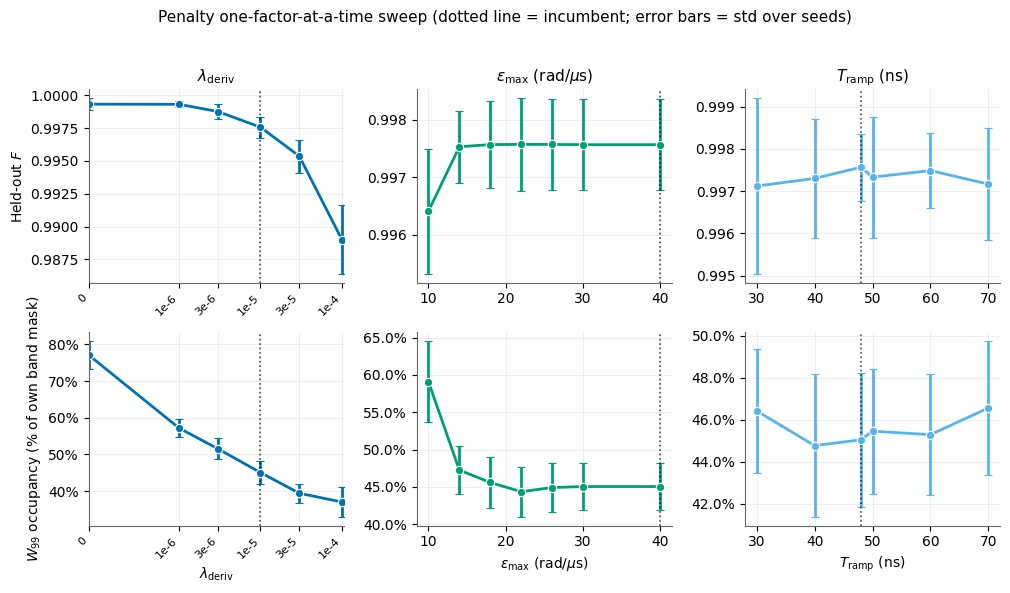

In [6]:
# Three panels: lambda_deriv (symlog -- it spans decades and has a zero rung),
# then epsilon_max and T_ramp (both linear -- physical quantities spanning a
# factor of 3 and 2.3, neither with a zero rung).
#
# New save path: figures/penalty_ofat.{png,pdf} is the PRE-ramp figure that
# Sections 11-15's prose refers to, and overwriting it would silently restate
# this experiment's result as that one's.
fig = pv.plot_ofat(df_rank, save_path="figures/penalty_ofat_ramp")


**Figure 1. Held-out fidelity (top row) and 99% occupied width $W_{99}$, as a share of the
binding drive's own band mask (bottom row), against each of the three axes.** The dotted vertical
line marks the incumbent value. For $\lambda_{\mathrm{deriv}}$ the leftmost point is the
$\lambda = 0$ negative control; the other two ladders have no zero rung (§7.1). Fidelity and width
sit on **separate rows rather than a shared twin axis**: the scales are not commensurate, and
overlaying them would imply a trade-off rate that does not exist.

> **Read the y-scales before the shapes.** Every panel is autoscaled independently, so a panel
> spanning $10^{-4}$ in fidelity looks exactly as dramatic as one spanning $10^{-2}$. Shape here
> tells you whether a response is *ordered*; it tells you nothing about whether it is *large*.
> §6.3 puts all three axes on one scale, and §6.2 supplies the floor below which an ordered-
> looking curve is just the optimizer changing basins. Do not rank two axes from this figure.

### 5.1 The ramp's mechanism, plotted

Figure 1's top row asks whether each axis moves *fidelity*. For $T_{\mathrm{ramp}}$ that is the
wrong first question: the ramp is not a fidelity knob, it is a boundary condition, and it should
be judged first on whether it delivers the boundary condition and second on what that costs.

The figure below is that pair. The ramp buys a lower endpoint amplitude
(`endpoint_rel_to_peak` — the largest first/last sample as a fraction of the waveform's own peak)
and was expected to pay for it in pre-image inflation (`max_abs_preimage` — the largest raw
optimizer variable, against a box at 40). The prediction, written before the sweep ran, was that
the two move in **opposite** directions as the ramp lengthens (§1.4).

**Both halves are now right, and that is a change from the smaller campaigns.** The top panel
falls from 2.11% at 30 ns to 1.07% at 70 ns — a $2.0\times$ reduction, ordered at $\rho = -0.94$
though not strictly monotone (the 48 and 50 ns rungs cross). That is the ramp delivering exactly
what it exists for. The bottom panel *also* climbs now: $\rho = +0.83$ against ramp duration on the
seed means, over the ladder $[24.4,\ 25.1,\ 29.8,\ 30.4,\ 28.4,\ 31.6]$, with the 70 ns rung
sitting **highest** of all.

That reverses what this section said at three and six seeds, and the reversal is worth stating
plainly: the seed-mean correlation went $+0.03\ (n{=}3) \rightarrow +0.54\ (n{=}6) \rightarrow
+0.83\ (n{=}10)$, strengthening monotonically as replicates were added. The natural reading of
`core/ramp.py`'s docstring — lengthen the ramp, lose edge authority, watch L-BFGS-B inflate the
pre-image to buy it back — is no longer contradicted by the seed means.

**It does not survive the per-seed check, and that is what still decides it.** Within individual
seeds the correlation ranges from $-0.37$ to $+0.77$ and the signs disagree, so `min|rho_s| = 0.00`:
the clean seed-mean ladder is being assembled out of per-seed ladders that do not agree on a
direction. $\lambda_{\mathrm{deriv}}$ reaches the same $\lvert\rho\rvert = 0.83$ on seed means but
*keeps its sign in every seed* (§7.5). So the honest summary is no longer "the ramp does not drive
the pre-image" but "the ramp's apparent effect on the pre-image is not yet separable from basin
choice, while $\lambda_{\mathrm{deriv}}$'s is." Gate 0b in §7.4 encodes exactly that distinction
and still fails — but it now fails narrowly, on the correlation alone.

Saved figures/penalty_ramp_mechanism.png / .pdf


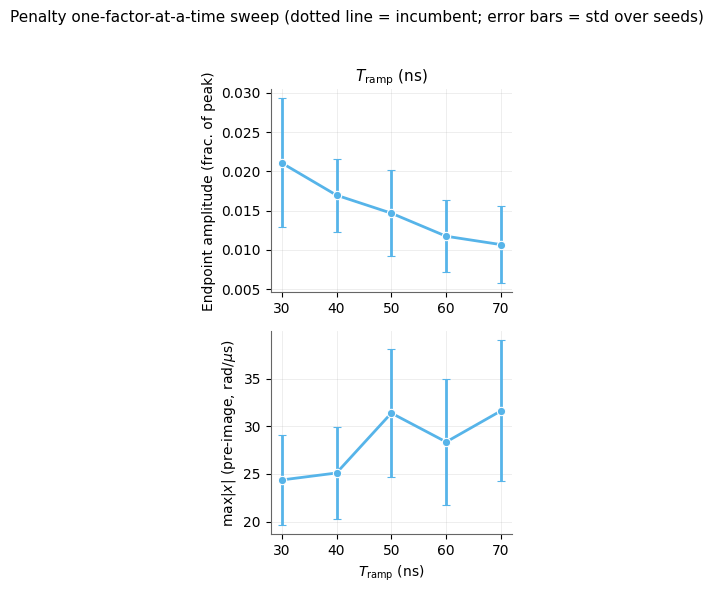

In [7]:
# Restricted to the T_ramp ladder: the other two axes do not reparametrize the
# search space, so neither quantity here means the same thing along them.
#
# Filter on `swept` ALONE. The incumbent rows carry swept == "deriv", so adding
# `| df_ramp.is_baseline` would put a second COLUMN in this figure holding one
# point -- plot_ofat draws one column per distinct `swept` value. It re-attaches
# the incumbent to each ladder itself (see its body), so the 48 ns rung appears
# in the T_ramp panel regardless.
ramp_rows = df_ramp[df_ramp.swept == "ramp_ns"].copy()
fig = pv.plot_ofat(ramp_rows,
                   metrics=("endpoint_rel_to_peak", "max_abs_preimage"),
                   save_path="figures/penalty_ramp_mechanism")

**Figure 2. What the ramp controls, and what it was assumed to cost.** The $T_{\mathrm{ramp}}$
ladder only, with the incumbent's 48 ns rung re-attached. *Top:* `endpoint_rel_to_peak`, the
first sample's amplitude as a share of the pulse's own peak — the quantity the ramp exists to
suppress. *Bottom:* `max_abs_preimage`, the largest raw L-BFGS-B variable, against the
`hard_amp_limit = 40` box drawn as a dashed line.

**The top panel is the ramp doing its job; the bottom is the cost it was assumed to charge —
and at ten seeds it is charging it, though not yet provably.** `core/ramp.py`'s docstring argues
that removing control authority at the edges makes L-BFGS-B buy it back by inflating the
pre-image, which the box then has to stop. Over 30–70 ns that inflation now tracks the ramp at
$\rho = +0.83$ on the seed means and reaches **79%** of the box, so Gate 0b's second condition
(does it actually get near the box?) passes. Gate 0b still fails, but now on the correlation
alone — 0.83 against a pre-registered threshold of 0.90 — and on the fact that the per-seed
correlations disagree in sign. Read the docstring's argument as being about having a ramp at all,
at the fixed 48 ns default; its claim about *duration* is no longer refuted here, merely
unresolved. §6.4 gives the numbers; §7.5 shows that $\lambda_{\mathrm{deriv}}$ reaches the same
seed-mean $\lvert\rho\rvert$ while keeping its sign within every seed, which is the difference
that matters.


# 6. What is inert, what is noise, and what actually moves

This section is ordered so that nothing is measured before the yardstick for measuring it exists.
**§6.1** removes the two weights that are structurally incapable of doing anything, which is what
makes $\epsilon_{\max}$ a *threshold* axis rather than a weight axis. **§6.2** builds the one
noise floor this notebook uses — a single number, derived from this run's own data. **§6.3** ranks
the three axes against it. **§6.4** puts the newest axis, $T_{\mathrm{ramp}}$, on trial under the
same rule that retired $\lambda_{\mathrm{boundary}}$.

### 6.1 Two structurally inert weights, and why the ladder sweeps a threshold instead

Both of the following are properties of the configuration, not of this particular run, and both
are checked **at convergence** against the canonical production pulse `pulses/u_X_main.npy` rather
than in the under-trained regime above.

The output below also makes explicit a distinction that is easy to lose: `amplitude_penalty`
charges $\max(0, |u| - \epsilon_{\max})^2$ **element-wise on the four quadratures**, whereas this
notebook's `peak_amp` column is the *complex-envelope* maximum
$\max(|\epsilon_C|, |\epsilon_T|)$. Those are different numbers, and reading the threshold against
the wrong one is why the previous ladder's $\epsilon_{\max} = 20$ rung looked as though it should
bind and mostly did not.

In [8]:
from core.grape_core import amplitude_penalty, make_hamiltonian, coherent_fidelity_multi_state
from analysis.penalty_sweep import GATE_FACTORIES

u_ref = np.load("pulses/u_X_main.npy")
print(f"canonical converged pulse, peak |u| = {np.abs(u_ref).max():.2f} rad/us "
      f"(element-wise over the (N,4) quadratures -- see below)")
print(f"\nthe amp_max ladder, charged against that pulse at lambda_amp = {BASELINE['amp']}:")
print(f"  {'amp_max':>8}{'g_amp':>12}{'lambda*g_amp':>14}{'|grad|':>10}{'violations':>12}")
for thr in list(AMP_MAX_VALUES) + [FIXED["amp_max"]]:
    g, gr = amplitude_penalty(u_ref, amp_max=thr)
    n = int((np.abs(u_ref) > thr).sum())
    print(f"  {thr:8.0f}{g:12.3f}{BASELINE['amp']*g:14.5f}"
          f"{np.linalg.norm(gr):10.3f}{n:8d}/{u_ref.size}")

Fs = []
for nc in FIXED["trunc_list"]:
    H0, Hc = make_hamiltonian(3, nc)
    pairs = GATE_FACTORIES["X"](n_c=nc, n_t=3)
    F, _ = coherent_fidelity_multi_state(u_ref, H0, Hc, [a for a, b in pairs],
                                         [b for a, b in pairs], 0.002, want_grad=False)
    Fs.append(F)
Fs = np.array(Fs)
disc = sum((Fs[i] - Fs[j])**2 for i in range(len(Fs)) for j in range(len(Fs)) if i != j)
print(f"\nF_coh at n_c={FIXED['trunc_list']}: {np.round(Fs, 9)}")
print(f"disc_cost = sum_(i!=j) (F_i-F_j)^2 = {disc:.3e}")
print(f"   at lambda_disc = {BASELINE['disc']} this contributes {BASELINE['disc']*disc:.3e} "
      f"against an O(1) fidelity term")

# The quantity the THRESHOLD acts on is not the quantity the table reports.
print(f"\nelement-wise max|u| = {np.abs(u_ref).max():.2f}  "
      f"vs complex-envelope peak_amp = "
      f"{max(np.abs(u_ref[:,0]+1j*u_ref[:,1]).max(), np.abs(u_ref[:,2]+1j*u_ref[:,3]).max()):.2f}")

canonical converged pulse, peak |u| = 17.73 rad/us (element-wise over the (N,4) quadratures -- see below)

the amp_max ladder, charged against that pulse at lambda_amp = 8e-05:
   amp_max       g_amp  lambda*g_amp    |grad|  violations
        10    2135.341       0.17083    92.420     162/2200
        14     233.673       0.01869    30.573      51/2200
        18       0.000       0.00000     0.000       0/2200
        22       0.000       0.00000     0.000       0/2200
        26       0.000       0.00000     0.000       0/2200
        30       0.000       0.00000     0.000       0/2200
        40       0.000       0.00000     0.000       0/2200



F_coh at n_c=[22, 24, 26]: [0.99820793 0.99821607 0.99821529]
disc_cost = sum_(i!=j) (F_i-F_j)^2 = 2.421e-10
   at lambda_disc = 0.5 this contributes 1.211e-10 against an O(1) fidelity term

element-wise max|u| = 17.73  vs complex-envelope peak_amp = 19.75


**$\lambda_{\mathrm{amp}}$ is exactly inert, and the ladder sweeps the threshold instead.**
The soft cap is $g_a(u) = \sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$. At the incumbent
$\epsilon_{\max} = 40$ rad/µs it returns exactly `0.0` with an exactly zero gradient on the
**incumbent recipe's** converged pulses, which peak far below it (§1.3) — and multiplying zero by
any weight changes nothing. Sweeping $\lambda_{\mathrm{amp}}$ at the incumbent would be a
measurement of nothing. **The live knob is the threshold**, which is why $\epsilon_{\max}$ is the
axis.

That inertness is a property of the *recipe*, not of the cap, and the qualifier matters here: the
$\lambda_{\mathrm{deriv}} = 0$ rung is a far more amplitude-hungry pulse and can approach
$\epsilon_{\max} = 40$ from below. Where it does, the cap stops being inert and that rung is no
longer a clean single-factor manipulation of $\lambda_{\mathrm{deriv}}$ alone — it is
$\lambda_{\mathrm{deriv}} = 0$ *with* an amplitude cap that has begun to act. The `peak_amp`
column of Table 5 is where to check this, bearing in mind it is the complex-envelope maximum and
the cap charges element-wise, so `peak_amp` slightly *over*-states how close the cap is to biting.

**$\lambda_{\mathrm{disc}}$ is negligible by construction.** The three training truncations
already agree to $\sim\!10^{-4}$, so the discrepancy cost is many orders below the $O(1)$ fidelity
term. It cannot *systematically* improve the pulse — but in a non-convex, non-converged
optimization a finite-though-tiny gradient is easily enough to perturb the trajectory into a
different local optimum. That distinction, between "helps" and "jiggles", is what §6.2 has to pin
down: a perturbation being provably negligible does **not** automatically make its effect on the
reported fidelity zero.

### 6.2 The noise floor

Every comparison in this notebook needs one number: the smallest difference in held-out fidelity
that this study can tell apart from run-to-run luck. Earlier versions of this section reported
four candidate floors and then chose between them. That was a symptom, not a service — three of
the four were pre-ramp measurements carried across a regime boundary, and picking among them put a
judgement call underneath every downstream claim. This run contains its own null, so the floor is
derived here, in three steps, and **one number comes out.**

**Step 1 — where is zero?** $g_a$ is charged **element-wise on the four quadratures**, so whenever
$\epsilon_{\max}$ sits above the pulse's element-wise peak it is exactly $0$ with an exactly zero
gradient, and multiplying zero by any weight changes nothing. Such a rung therefore optimizes the
*identical objective* as the incumbent, under a different configuration hash, in a separate
training run. Whatever those runs disagree by is the noise the **pipeline itself** contributes,
with the configuration held genuinely fixed.

Each (rung, seed) row falls into one of three regimes, and only the last is a null:

| regime | test | where it lands |
|---|---|---|
| **binding** | $g_a > 0$ at convergence — a real peak-power constraint | all 10 seeds at $\epsilon_{\max} = 10$; 9 of 10 at 14; 6 of 10 at 18 |
| **shaped** | $g_a = 0$ at the end, but the cap *drove* the pulse onto itself getting there | 1 seed at 14; 4 at 18; 5 at 22; 1 at 26 |
| **null** | bit-identical to the incumbent's waveform | 5 of 10 seeds at 22; 9 of 10 at 26; all 10 at 30 |

The classification is **per row, not per rung** — rungs 14, 18, 22 and 26 all straddle a regime
boundary depending on the seed, and at ten seeds only $\epsilon_{\max} = 30$ is null everywhere, which is exactly why the test is applied to each pulse rather than
assumed from the threshold. And the null criterion is bit-identity, not `g_amp == 0`: a cap
satisfied with equality is a real constraint wearing a null's clothes, and scoring the shaped rows
as null would fold a genuine constraint's effect into the floor and report it as
$\sim\!2.8\times10^{-4}$ instead of its true value.

**Step 2 — what is left.** If Step 1 returns exactly zero, then the pipeline is deterministic at
fixed objective and seed, and **seed choice is the only remaining source of variation.** The
estimate is then the pooled cross-seed standard deviation of `F_ped_heldout_mean` over the
distinct configurations — the three null rungs are dropped from the pool, since they are copies of
the incumbent rather than independent configurations.

**Step 3 — the number.** Two configurations are compared by their seed-means, so the resolution
limit on a *difference* is

$$\mathrm{FLOOR} \;=\; t_{0.975,\,\nu}\; s\, \sqrt{2/n}$$

and for a ladder's *range* over $k$ rungs the noise-only expectation is $d_k\, s/\sqrt{n}$, with
$d_k$ the expected range of $k$ standard normals ($d_5 = 2.326$, $d_6 = 2.534$, $d_7 = 2.704$). A
range is a max-of-differences statistic and is biased upward by noise; comparing it against
$d_k s/\sqrt{n}$ is the correct way to account for that, rather than the arbitrary factor of two
this section used to apply.

Two checks have to be reported honestly rather than assumed. **Whether pairing by seed helps:**
all 17 configurations were trained at the same ten seeds, so if a seed carried a shared offset the
paired contrast would remove it and the floor would drop. **And whether one pooled $s$ is
legitimate at all** — Levene is the robust homogeneity test and Bartlett the normality-sensitive
one, and §6.2's pre-registered rule is to let Levene decide. At ten seeds Levene changes its
answer. The cell below tests both directly.


In [9]:
# THE noise floor. One number, derived here, used everywhere below.
#
# STEP 1 -- where is zero?  `amplitude_penalty` is exactly zero with an exactly
# zero gradient whenever the threshold sits above the pulse's element-wise peak,
# so a rung above that peak optimizes the *identical* objective as the incumbent:
# a different config_hash, a separate training run, provably the same problem.
# Whatever those runs disagree by is the pipeline's own noise.
from scipy import stats

# Seed-averaged frame, used by the rest of this section and by Sections 7-8.
agg_ramp = pv.aggregate_seeds(df_rank)
assert len(agg_ramp[agg_ramp["is_baseline"]]) == 1, "more than one baseline row"
base_ramp = agg_ramp[agg_ramp["is_baseline"]].iloc[0]      # the incumbent

CACHE_X = "results/penalty_sweep_cache/X"
base_hashes = dict(zip(df_ramp[df_ramp.is_baseline]["seed"],
                       df_ramp[df_ramp.is_baseline]["config_hash"]))

# The row cache can outlive the pulse cache (rows are merged into the CSV;
# pulses are big and get pruned). Skip cleanly rather than taking the whole
# notebook down -- this cell is the only one that needs the waveforms.
missing, rows = [], []
for _, r in df_ramp[df_ramp.swept == "amp_max"].iterrows():
    pa = f"{CACHE_X}/u_{r['config_hash']}.npy"
    pb = f"{CACHE_X}/u_{base_hashes[r['seed']]}.npy"
    if not (os.path.exists(pa) and os.path.exists(pb)):
        missing.append((r["amp_max"], r["seed"]))
        continue
    up, ub = np.load(pa), np.load(pb)
    g, _ = amplitude_penalty(up, amp_max=r["amp_max"])
    b = df_ramp[(df_ramp.is_baseline) & (df_ramp.seed == r["seed"])].iloc[0]
    rows.append({
        "amp_max": r["amp_max"], "seed": r["seed"],
        "g_amp at convergence": g,
        "peak |u| (elementwise)": float(np.abs(up).max()),
        "binds": g > 0,
        "bit-identical to incumbent": bool(np.array_equal(up, ub)),
        "max|du|": float(np.abs(up - ub).max()),
        "|dF_held|": abs(r["F_ped_heldout_mean"] - b["F_ped_heldout_mean"]),
    })
if missing:
    print(f"WARNING: {len(missing)} pulse(s) absent from the cache, excluded from the "
          f"floor: {missing}\n         Re-run the sweep to regenerate them.")
if not rows:
    raise FileNotFoundError(
        f"no cached pulses under {CACHE_X}; this cell needs the waveforms, not just "
        f"the merged CSV. Re-run: python analysis/penalty_sweep.py --gate X --mode ofat "
        f"--tag ramp --seeds 42 43 44")

null_ladder = pd.DataFrame(rows).sort_values(["amp_max", "seed"])
null_ladder["regime"] = np.where(
    null_ladder["binds"], "binding",
    np.where(null_ladder["bit-identical to incumbent"], "null", "shaped"))
display(null_ladder.style.format({"g_amp at convergence": "{:.3g}",
                                  "peak |u| (elementwise)": "{:.2f}",
                                  "max|du|": "{:.2e}", "|dF_held|": "{:.2e}"})
        .hide(axis="index"))

# The null criterion is BIT-IDENTITY, not "g_amp == 0 at convergence" -- see the
# `shaped` regime above, where the cap drove the pulse onto itself and is now
# satisfied with equality. That is a real constraint, not a null.
noise = null_ladder[null_ladder["regime"] == "null"]
pipeline_noise = float(noise["|dF_held|"].max()) if len(noise) else float("nan")
print(f"\nSTEP 1  pipeline noise at fixed objective and seed")
print(f"        {len(noise)} bit-identical replicates "
      f"(amp_max in {sorted(noise['amp_max'].unique())}, all {noise['seed'].nunique()} seeds)")
print(f"        max|du| = {noise['max|du|'].max():.1e}, max|dF_held| = {pipeline_noise:.1e}")
assert pipeline_noise == 0.0, "the pipeline is NOT deterministic; Step 2 no longer follows"
print("        -> exactly zero. The pipeline is deterministic at fixed objective and "
      "seed,\n           so seed choice is the ONLY remaining source of variation.")

# STEP 2 -- pool the cross-seed sd over the DISTINCT configurations. The three
# null rungs are copies of the incumbent, not independent configs, so they would
# triple-count the baseline's variance. Basin-collapse labels (overfit_gap > 0.01)
# are a different basin, not a draw from the noise distribution; drop them the
# same way. They stay in df_ramp for §4.
M = "F_ped_heldout_mean"
dup_labels = set(agg_ramp[(agg_ramp.swept == "amp_max")
                          & (agg_ramp.amp_max.isin(noise["amp_max"].unique()))]["label"])
collapse_labels = set(df_ramp.loc[df_ramp["overfit_gap"] > 0.01, "label"])
if collapse_labels:
    print(f"        dropping {len(collapse_labels)} basin-collapse label(s) from the "
          f"floor pool: {sorted(collapse_labels)}")
dup_labels = set(dup_labels) | collapse_labels
distinct = agg_ramp[~agg_ramp["label"].isin(dup_labels)]
n_seeds = int(df_rank[~df_rank["label"].isin(dup_labels)].groupby("label")["seed"].nunique().min())
s_pooled = float(np.sqrt((distinct[f"{M}_std"].astype(float) ** 2).mean()))
dof = len(distinct) * (n_seeds - 1)

# Is one pooled sd legitimate, or is the spread config-dependent?  Levene is the
# robust test and Bartlett the normality-sensitive one; at n=3 per group Bartlett
# is the fragile one, so report both and let Levene decide.
groups = [g[M].values for _, g in
          df_rank[df_rank.label.isin(distinct.label)].groupby("label")]
lev, bar = stats.levene(*groups), stats.bartlett(*groups)
print(f"\nSTEP 2  pooled cross-seed sd over {len(distinct)} distinct configs, "
      f"n={n_seeds} each")
print(f"        s = {s_pooled:.3e}  ({dof} dof)")
print(f"        homogeneity: Levene p = {lev.pvalue:.2f} (robust), "
      f"Bartlett p = {bar.pvalue:.3f} (normality-sensitive)")
print(f"        -> {'Levene finds no evidence against pooling' if lev.pvalue > 0.05 else 'CAUTION: Levene rejects homogeneity'}.")

# Does pairing by seed help?  Only if seeds carry a shared offset across configs.
by_seed = df_rank.pivot_table(index="label", columns="seed", values=M)
INCUMBENT = base_ramp["label"]
paired_sds = [float((by_seed.loc[l] - by_seed.loc[INCUMBENT]).std(ddof=1))
              for l in distinct["label"] if l != INCUMBENT]
s_paired = float(np.sqrt(np.mean(np.square(paired_sds))))
print(f"        paired-difference sd s_d = {s_paired:.3e} vs unpaired s = {s_pooled:.3e}")
print(f"        -> pairing {'HELPS' if s_paired < s_pooled else 'does NOT help'}: basin "
      f"choice is config-specific, not a shared per-seed\n           offset, so the "
      f"unpaired floor is the right one and one number suffices.")

# STEP 3 -- the number.
FLOOR = float(stats.t.ppf(0.975, dof) * s_pooled * np.sqrt(2 / n_seeds))
# E[range] of k standard normals (Hartley's d2). The amp_max ladder has 7 rungs
# once the incumbent -- which IS its eps_max = 40 rung -- is re-attached, so this
# has to cover more than the 5 and 6 the deriv and ramp ladders need.
D_K = {2: 1.128, 3: 1.693, 4: 2.059, 5: 2.326, 6: 2.534,
       7: 2.704, 8: 2.847, 9: 2.970, 10: 3.078}


def range_floor(k):
    """Range a k-rung ladder is expected to show from seed noise alone."""
    if k not in D_K:
        raise KeyError(f"no Hartley d2 for k={k}; extend D_K rather than interpolating")
    return D_K[k] * s_pooled / np.sqrt(n_seeds)


print(f"\nSTEP 3  FLOOR = t({dof}) * s * sqrt(2/{n_seeds}) = {FLOOR:.3e}")
print(f"        = the smallest difference between two configs' seed-means this study "
      f"can resolve.")
print(f"        Ladder ranges are compared against d_k*s/sqrt(n) instead: "
      f"{range_floor(5):.2e} (k=5), {range_floor(6):.2e} (k=6), "
      f"{range_floor(7):.2e} (k=7).")
# Archived measurements; do NOT recompute either from this table -- each was the
# live floor of its own campaign and is quoted as history, not re-derived.
FLOOR_N3 = 1.48e-3  # tables/penalty_sweep_X_ofat_ramp_n3.csv
FLOOR_N6 = 1.15e-3  # tables/penalty_sweep_X_ofat_ramp_n6.csv
print(f"\n        Historical: FLOOR = {FLOOR_N3:.2e} at n=3, {FLOOR_N6:.2e} at n=6.")
print(f"        This campaign: FLOOR = {FLOOR:.2e} at n={n_seeds}.")


amp_max,seed,g_amp at convergence,peak |u| (elementwise),binds,bit-identical to incumbent,max|du|,|dF_held|,regime
10.000000,42,0.222,10.16,True,False,1.66e+01,4.81e-04,binding
10.000000,43,0.538,10.29,True,False,1.48e+01,8.36e-04,binding
10.000000,44,0.291,10.18,True,False,1.28e+01,4.38e-04,binding
10.000000,45,0.542,10.31,True,False,2.25e+01,1.45e-03,binding
10.000000,46,0.48,10.25,True,False,1.46e+01,1.09e-03,binding
10.000000,47,0.189,10.11,True,False,8.57e+00,6.88e-04,binding
10.000000,48,1.59,10.25,True,False,2.54e+01,3.15e-03,binding
10.000000,49,0.552,10.23,True,False,2.05e+01,1.44e-05,binding
10.000000,50,1.19,10.33,True,False,2.34e+01,3.09e-03,binding
10.000000,51,0.231,10.14,True,False,1.64e+01,3.98e-04,binding



STEP 1  pipeline noise at fixed objective and seed
        24 bit-identical replicates (amp_max in [np.float64(22.0), np.float64(26.0), np.float64(30.0)], all 10 seeds)
        max|du| = 0.0e+00, max|dF_held| = 0.0e+00
        -> exactly zero. The pipeline is deterministic at fixed objective and seed,
           so seed choice is the ONLY remaining source of variation.
        dropping 1 basin-collapse label(s) from the floor pool: ['deriv=1e-05_amp=8e-05_disc=0.5_ramp=50']

STEP 2  pooled cross-seed sd over 13 distinct configs, n=10 each
        s = 1.258e-03  (117 dof)
        homogeneity: Levene p = 0.02 (robust), Bartlett p = 0.000 (normality-sensitive)
        -> CAUTION: Levene rejects homogeneity.
        paired-difference sd s_d = 1.389e-03 vs unpaired s = 1.258e-03
        -> pairing does NOT help: basin choice is config-specific, not a shared per-seed
           offset, so the unpaired floor is the right one and one number suffices.

STEP 3  FLOOR = t(117) * s * sqrt(2/10) =

**Table 4. The $\epsilon_{\max}$ ladder, and the floor built from it.** One row per rung per seed.
`g_amp at convergence` is the amplitude penalty evaluated on that rung's own final pulse;
`peak |u| (elementwise)` is the quantity the threshold actually acts on; `regime` applies §6.2's
three-way test row by row.

**Twenty-four of the thirty $(\epsilon_{\max}\in\{22,26,30\}$, seed) cells come back bit-identical**
to the incumbent, so `max|dF_held|` across those twenty-four is $0$ exactly. $\epsilon_{\max}=30$ is
identical at all ten seeds; $\epsilon_{\max}=26$ at nine of ten; $\epsilon_{\max}=22$ at five of ten,
shaped at the rest. The null block shrank in *proportion* as seeds were added — the per-seed
element-wise peak now spans 15.4–21.8 rad/µs rather than 17.7–21.0, and seeds at the top of that
range push the $\epsilon_{\max}=22$ rung into the shaped regime. The instrument still works,
because 24 replicates is more than the 16 it had at $n=6$; but the ladder's top rungs are a
weaker null than they looked, and $\epsilon_{\max}=30$ is the only rung that is null everywhere.

Where the objective *is* genuinely the same, the pipeline still adds nothing of its own. Every
difference reported anywhere in this notebook is a consequence of the configuration or of the
seed — never of reduction order.

What survives is seed choice, and the printout gives it as a single number,
$\mathrm{FLOOR} = 1.11\times10^{-3}$ from $s = 1.26\times10^{-3}$ over 13 distinct configurations
(117 dof, $n=10$). The $T_{\mathrm{ramp}}=50$ ns label is dropped from this pool because seed 47
is a wall-exploiting basin (§4.1), not a draw from the noise distribution; the null
$\epsilon_{\max}$ rungs are dropped because they copy the incumbent.

**The floor has stopped falling, and that is the main finding of this section at $n=10$.**
The three campaigns give $1.48\times10^{-3}$ ($n=3$, $s = 8.82\times10^{-4}$, 28 dof) →
$1.15\times10^{-3}$ ($n=6$, $s = 9.95\times10^{-4}$, 65 dof) → $1.11\times10^{-3}$ ($n=10$,
$s = 1.26\times10^{-3}$, 117 dof). Going from six seeds to ten should have bought a factor
$\sqrt{6/10} = 0.77$, taking the floor to $8.9\times10^{-4}$. It bought 3%. The reason is visible
in the same line: $s$ rose 26%, from $9.95\times10^{-4}$ to $1.26\times10^{-3}$, almost exactly
cancelling the $\sqrt{n}$ gain. Each campaign has raised $s$, so the seed-to-seed spread is not a
fixed quantity being estimated more precisely — **the additional seeds are finding basins the
earlier ones did not reach.** Buying another factor of two on this floor by adding seeds alone
would take on the order of 40 seeds, and on this evidence it may not converge there either. That
is an argument for attacking basin choice directly — a better warm start, or a restart policy —
rather than for a larger $n$.

Two further details are worth reading off it rather than skipping:

- **Pooling is no longer defensible on this section's own rule, and the rule is being kept.**
  Levene, the robust test, now gives $p = 0.02$ and **rejects** homogeneity ($p = 0.09$ at $n=6$);
  Bartlett gives $p = 0.000$ as before. §6.2's pre-registered rule was to let Levene decide, and
  Levene has decided against a single pooled $s$. The pooled floor is reported anyway, for one
  stated reason: it is the instrument every claim in §7 and §8 was pre-registered against, and
  swapping it for per-configuration variances mid-campaign would re-rank results by changing the
  ruler rather than the data. Its status has changed, though, and every use of `FLOOR` below
  should be read accordingly — it is an *average* resolution limit across configurations whose
  true spreads differ, so it is conservative for tight configurations and permissive for loose
  ones. A per-configuration Welch contrast is the honest successor and is left as the open
  methodological item of this campaign.
- **Pairing still does not help.** The paired-difference sd comes out *larger*
  ($1.39\times10^{-3}$) than the unpaired $s$ ($1.26\times10^{-3}$), so seeds do not carry a shared
  offset a paired contrast could remove: basin selection is specific to each configuration. That
  result has now survived two rounds of extra seeds.


### 6.3 Ranking the axes

How far each axis moves each metric, end to end, measured against §6.2's floor. Two comparisons
are made, and they answer different questions:

- **`vs FLOOR`** divides the fidelity range by the smallest resolvable *difference between two
  configurations*. It answers "if I picked the best and worst rung of this ladder, would I be able
  to tell them apart?"
- **`vs noise range`** divides it by $d_k s/\sqrt{n}$, the range a ladder of this length would
  show from seed noise alone. It answers the harder question: "is the *shape* of this ladder
  anything at all?" A range statistic over five or six points is biased upward by noise, and this
  is the comparison that accounts for it.

An axis that fails both has not been shown to do nothing — it has been shown to be **unmeasurable
at this sample size**, which is a different and weaker claim, and §7 keeps the distinction.

In [10]:
def ladder(ax_name, frame=None):
    """That axis's rungs, with the incumbent re-attached and sorted by the knob.

    The incumbent is the shared centre rung of ALL THREE ladders but is
    enumerated once, into whichever ladder `build_ofat_configs` emitted first.
    Without re-attaching it, two of the three ladders are missing their middle
    point and their ranges are computed over a truncated axis.
    """
    frame = agg_ramp if frame is None else frame
    sub = frame[frame["swept"] == ax_name]
    if not sub["is_baseline"].any():
        sub = pd.concat([sub, base_ramp.to_frame().T], ignore_index=True)
    return sub.sort_values(pv.axis_column(ax_name))


rows = []
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    if sub.empty:
        continue
    col = pv.axis_column(ax_name)
    F = sub["F_ped_heldout_mean"].astype(float).values
    rng = F.max() - F.min()
    rows.append({
        "axis": ax_name,
        "rungs": len(sub),
        "swept from": f"{sub[col].min():.3g}",
        "to": f"{sub[col].max():.3g}",
        "range F_held": rng,
        "vs FLOOR": rng / FLOOR,
        "vs noise range": rng / range_floor(len(sub)),
        "range W99 (frac)": sub[COST_METRIC].max() - sub[COST_METRIC].min(),
        "range W99 (MHz)": sub["occ99_MHz"].max() - sub["occ99_MHz"].min(),
        "range endpoint": (sub["endpoint_rel_to_peak"].max()
                           - sub["endpoint_rel_to_peak"].min()),
        "max |x|": sub["max_abs_preimage"].max(),
        "rho(knob, F)": pd.Series(sub[col].astype(float).values).corr(
            pd.Series(F), method="spearman"),
    })
eff = pd.DataFrame(rows).set_index("axis").sort_values("range F_held", ascending=False)
display(eff.style.format({"range F_held": "{:.2e}", "vs FLOOR": "{:.1f}x",
                          "vs noise range": "{:.1f}x",
                          "range W99 (frac)": "{:.1%}", "range W99 (MHz)": "{:.2f}",
                          "range endpoint": "{:.2%}", "max |x|": "{:.1f}",
                          "rho(knob, F)": "{:+.2f}"}))

LIVE = {ax: bool(r["vs FLOOR"] > 1 and r["vs noise range"] > 1 and abs(r["rho(knob, F)"]) > 0.9)
        for ax, r in eff.iterrows()}
print(f"FLOOR = {FLOOR:.2e}   (difference of two seed-means, Section 6.2)\n")
for ax, r in eff.iterrows():
    print(f"  {ax:>8}: range {r['range F_held']:.2e} = {r['vs FLOOR']:.1f}x FLOOR, "
          f"{r['vs noise range']:.1f}x noise range, rho = {r['rho(knob, F)']:+.2f}"
          f"   -> {'LIVE' if LIVE[ax] else f'not identified at n={n_seeds}'}")
print(f"\n  {sum(LIVE.values())} of {len(LIVE)} axes is a measurable fidelity knob at this "
      f"sample size.")


,rungs,swept from,to,range F_held,vs FLOOR,vs noise range,range W99 (frac),range W99 (MHz),range endpoint,max |x|,"rho(knob, F)"
axis,,,,,,,,,,,
deriv,6,0,0.0001,1.03e-02,9.3x,10.2x,40.1%,18.91,1.51%,33.1,-1.00
amp_max,7,10,40,1.17e-03,1.0x,1.1x,14.7%,9.73,1.83%,30.5,+0.41
ramp_ns,6,30,70,4.45e-04,0.4x,0.4x,1.8%,1.18,1.04%,31.6,+0.26


FLOOR = 1.11e-03   (difference of two seed-means, Section 6.2)

     deriv: range 1.03e-02 = 9.3x FLOOR, 10.2x noise range, rho = -1.00   -> LIVE
   amp_max: range 1.17e-03 = 1.0x FLOOR, 1.1x noise range, rho = +0.41   -> not identified at n=10
   ramp_ns: range 4.45e-04 = 0.4x FLOOR, 0.4x noise range, rho = +0.26   -> not identified at n=10

  1 of 3 axes is a measurable fidelity knob at this sample size.


**Table 5. Effect size per axis.** `range` is $\max - \min$ over that axis's ladder, with the
incumbent re-attached to every ladder (§2.2). `rho(knob, F)` is the Spearman correlation of
held-out fidelity against the swept knob — it carries the *shape* claim, and it is the right
summary for a short noisy ladder, where strict monotonicity fails on a single out-of-order pair
regardless of how strong the trend is.

An axis is called **live** only if it clears all three: range above `FLOOR`, range above the
noise-only range expectation, and $\lvert\rho\rvert > 0.9$. One axis does.
$T_{\mathrm{ramp}}$ is not a near miss at $n=10$: range $0.4\times$ `FLOOR`, $0.4\times$ the
noise-only range, $\rho = +0.26$. $\epsilon_{\max}$ is the interesting failure — its range has
climbed to exactly $1.0\times$ `FLOOR` and $1.1\times$ the noise-only range, so it now clears the
two *size* tests, but at $\rho = +0.41$ the ladder is not ordered and it fails the shape test.
A ladder whose range is real but whose order is not is the signature of one or two outlying rungs
rather than a response, and §8's Pareto front confirms it: $\epsilon_{\max}$ contributes one
member, by noise. Two rounds of extra seeds have promoted neither axis.
$\lambda_{\mathrm{deriv}}$ is live at $9.3\times$ `FLOOR`, $\rho = -1.00$.

The last two columns are specific to the ramp: `range endpoint` is how much the ladder moves
`endpoint_rel_to_peak`, which is what the ramp exists to control, and `max |x|` is the largest raw
pre-image reached against a box at 40. Read them for $T_{\mathrm{ramp}}$ and be careful with them
elsewhere — neither of the other two axes reparametrizes the search space, so neither quantity
means quite the same thing along them. §7 makes that comparison properly.


### 6.4 Is $T_{\mathrm{ramp}}$ a live axis, or is it another $\lambda_{\mathrm{boundary}}$?

This is the subsection that has to be willing to conclude *no*.

$\lambda_{\mathrm{boundary}}$ was retired on a specific, stated test: its marginal range in
held-out fidelity straddled the noise floor and was non-monotonic in every row of a $5\times5$
grid. $T_{\mathrm{ramp}}$ is that weight's structural replacement. Applying a weaker standard to
the replacement than to the thing it replaced would be motivated reasoning, so the same test is
applied here — and now there is only one floor to apply it against, so there is no room to choose
a favourable one.

**The two questions are separable, and conflating them is the trap.** "Does the ramp work?" and
"does its *duration* change fidelity?" are different. The ramp is a **structural** constraint: its
job is to hold the endpoint amplitude down so the waveform is physically playable (§1.3), not to
raise fidelity. It can be doing that job perfectly while its duration is not a fidelity knob at
all. The cell below answers both, in that order, and reports the second as the weaker claim it is.

In [11]:
lim = float(df_ramp["hard_amp_limit"].iloc[0])
ramp_agg = ladder("ramp_ns")

print(ramp_agg[["ramp_ns", "F_ped_heldout_mean", "F_ped_heldout_mean_std",
                "endpoint_rel_to_peak", "max_abs_preimage", "preimage_at_bound_frac",
                COST_METRIC, "out_of_band_tra"]]
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))

# QUESTION 1: is T_ramp a fidelity axis?  Same test as every other axis (6.3),
# against the one floor from 6.2.
F = ramp_agg["F_ped_heldout_mean"].astype(float).values
t = ramp_agg["ramp_ns"].astype(float).values
rng = F.max() - F.min()
rho_F = pd.Series(t).corr(pd.Series(F), method="spearman")
g1 = rng > FLOOR
g2 = rng > range_floor(len(ramp_agg))
g3 = abs(rho_F) > 0.9

print(f"\nFLOOR = {FLOOR:.2e} (difference of seed-means); noise-only range over "
      f"{len(ramp_agg)} rungs = {range_floor(len(ramp_agg)):.2e}")
print(f"  range of seed-means  : {rng:.2e}  vs FLOOR       -> {'PASS' if g1 else 'FAIL'}")
print(f"  range of seed-means  : {rng:.2e}  vs noise range -> {'PASS' if g2 else 'FAIL'}")
print(f"  shape                : Spearman rho = {rho_F:+.2f}      -> {'PASS' if g3 else 'FAIL'}")
print(f"\nVERDICT (fidelity): T_ramp is "
      f"{'a LIVE fidelity axis' if (g1 and g2 and g3) else f'NOT identified as a fidelity axis at n={n_seeds}'}.")

# QUESTION 2: does the ramp do the job it exists for?  Separate question, and the
# answer is not the same. Strict monotonicity is the wrong summary for a 6-point
# ladder with noise, so let the rank correlation carry the claim.
e = ramp_agg["endpoint_rel_to_peak"].astype(float).values
x = ramp_agg["max_abs_preimage"].astype(float).values
rho_e = pd.Series(t).corr(pd.Series(e), method="spearman")
rho_x = pd.Series(t).corr(pd.Series(x), method="spearman")
print(f"\nWhat the ramp is FOR, vs what it was assumed to cost:")
print(f"  endpoint_rel_to_peak : {e[0]:.2%} at {t[0]:.0f} ns -> {e[-1]:.2%} at {t[-1]:.0f} ns"
      f"   ({e.max()/e.min():.1f}x reduction), Spearman rho = {rho_e:+.2f}")
print(f"  max_abs_preimage     : {x[0]:.1f} -> {x[-1]:.1f} of {lim:.0f}"
      f"                      Spearman rho = {rho_x:+.2f}")


ramp_ns F_ped_heldout_mean F_ped_heldout_mean_std endpoint_rel_to_peak max_abs_preimage preimage_at_bound_frac occ99_frac out_of_band_tra
     30           0.997122             0.00208079            0.0210832          24.3683                      0   0.464187     0.000751061
     40           0.997302               0.001406            0.0169762          25.1013                      0   0.447658     0.000502904
     48           0.997567             0.00079127            0.0170874           29.804                      0   0.450413     0.000579784
     50           0.997333             0.00143092            0.0145947          30.4253            5.05051e-05   0.454545     0.000372384
     60           0.997488            0.000895948            0.0117491          28.3534            0.000318182   0.452862     0.000182677
     70           0.997167             0.00132158            0.0106815          31.6171            0.000454545   0.465565     0.000336522

FLOOR = 1.11e-03 (difference of s

**Two answers, and they are not the same answer.**

$T_{\mathrm{ramp}}$ is **not identified as a fidelity axis at $n=10$**: its range of
$4.45\times10^{-4}$ clears neither `FLOOR` ($1.11\times10^{-3}$) nor the noise-only range
expectation for a 6-rung ladder ($1.01\times10^{-3}$), and at $\rho = +0.26$ the ladder is not
ordered. Under exactly the test that retired $\lambda_{\mathrm{boundary}}$, this axis does not
pass. The $n=3$ near-miss ($0.93\times$ `FLOOR`, $\rho = +0.77$) did not survive replication, and
the range has fallen further at each campaign — this is a verdict that has become *more* secure
with seeds, not less.

But the ramp **does** do the job it exists for, and does it nearly for free. A longer ramp buys a
$2.0\times$ quieter endpoint (2.11% at 30 ns $\to$ 1.07% at 70 ns, $\rho = -0.94$) and spends no
measurable fidelity. What has changed at $n=10$ is the *cost* side: pre-image inflation now tracks
duration at $\rho = +0.83$ on the seed means and reaches 79% of the box, so Gate 0b fails on the
correlation alone rather than comfortably (§5.1, §7.4). The per-seed correlations still disagree in
sign, so the ramp's duration is not yet established as the driver — but "the ramp costs nothing in
pre-image headroom" is no longer a claim this ladder supports. Read `core/ramp.py`'s
authority-loss argument as being about having a ramp at all, at the fixed 48 ns default; on
duration, the evidence has moved from *refuting* it to *not yet resolving* it. That is what this
ladder establishes, and the only thing it does.


# 7. Negative controls, and whether any two axes interact

Two questions, in order. **§7.1** asks whether the trade-off the study assumes is real, by taking
each constraint away and checking that the pulse gets worse in the way that constraint was
supposed to prevent; **§7.2** records what the one grid this project has already trained returned.
**§7.3–§7.5** ask the structural question the sweep was designed to answer: is there any evidence
that two of these axes *interact*, such that the best setting of one depends on the setting of the
other? That decides whether a 2-D grid is worth training, and it is answered from the data rather
than from intuition.

### 7.1 The three axes admit three different nulls

Forcing them into one $\lambda = 0$ column would misdescribe two of them:

- $\lambda_{\mathrm{deriv}}$ has a **true zero rung**. Removing the smoothness penalty is a real,
  trainable configuration, and it is the clean demonstration.
- $\epsilon_{\max}$ is a **threshold, not a weight**. It has no zero — $\epsilon_{\max} = 0$ would
  forbid all drive, which is not "no constraint" but an infinitely tight one. Its null is the
  opposite end: set it where it cannot activate (§6.1).
- $T_{\mathrm{ramp}}$ has **no null rung in this ladder at all**, and that is a gap in the design
  rather than a property of the axis. `ramp_ns = 0` disables the ramp entirely — `core.ramp`
  treats `0` and `None` alike — and that *is* the honest negative control. It was not trained
  here. The archived pre-ramp table is not a clean stand-in either, because those pulses also
  carried the `boundary` penalty, so a comparison against them would confound two changes.

This subsection also runs the check that gates everything after it: whether the optimizer was ever
**clipped** by the box on the raw pre-image. A pulse at the bound was truncated, not converged
(§1.3), and its fidelity is not comparable to the rest of its ladder.

In [12]:
# Three axes, three DIFFERENT kinds of null (see the markdown above): deriv has a
# genuine zero rung, eps_max has only a "set it where it cannot activate" null,
# and T_ramp has none in this ladder. Forcing them into one column would
# misdescribe two of them, so the table below carries only the two that exist.

rows = []
z = agg_ramp[(agg_ramp["swept"] == "deriv") & (agg_ramp["lambda_deriv"] == 0.0)]
if not z.empty:
    rows.append(("lambda_deriv = 0 (true zero rung)", z.iloc[0]))

nb_rungs = sorted(noise["amp_max"].unique()) if len(noise) else []
if nb_rungs:
    z = agg_ramp[(agg_ramp["swept"] == "amp_max") & (agg_ramp["amp_max"] == max(nb_rungs))]
    if not z.empty:
        rows.append((f"epsilon_max = {max(nb_rungs):.0f} (highest non-binding)", z.iloc[0]))

ctrl = pd.DataFrame([{
    "control": name,
    "dF_coh_train": z["F_coh_train"] - base_ramp["F_coh_train"],
    "dF_heldout": z["F_ped_heldout_mean"] - base_ramp["F_ped_heldout_mean"],
    "dW99 (frac)": z[COST_METRIC] - base_ramp[COST_METRIC],
    "dW99 (MHz)": z["occ99_MHz"] - base_ramp["occ99_MHz"],
    "dSpread": z["robustness_spread"] - base_ramp["robustness_spread"],
    "dPeak": z["peak_amp"] - base_ramp["peak_amp"],
    "dEndpoint": z["endpoint_rel_to_peak"] - base_ramp["endpoint_rel_to_peak"],
} for name, z in rows]).set_index("control")
display(ctrl.round(5))

# Is the deriv=0 control significant, or is it inside the floor?  Paired by seed,
# which is the strongest form of the comparison even though pairing does not
# reduce the pooled sd (Section 6.2, Step 2).
ZERO = "deriv=0_amp=8e-05_disc=0.5"
dz = (by_seed.loc[ZERO] - by_seed.loc[INCUMBENT]).values
print(f"lambda_deriv = 0 vs incumbent, per seed: "
      f"{np.array2string(dz, formatter={'float': lambda v: f'{v:+.2e}'})}")
print(f"   mean {dz.mean():+.2e} vs FLOOR {FLOOR:.2e}   "
      f"({'all seeds agree in sign' if (dz > 0).all() or (dz < 0).all() else 'SIGN FLIPS'})")
print(f"   -> it buys fidelity, and Section 8 shows what it costs: it is the one "
      f"configuration\n      the budget rejects.\n")

print(f"T_ramp: no negative control in this ladder. The honest one is ramp_ns = 0")
print(f"        (`python main.py --gate X --ramp-ns 0`), which was not trained here.\n")

# The failure-mode check that gates every fidelity number above: a pulse whose raw
# pre-image sat on the box was TRUNCATED, not converged (the U_Y seed-42 basin),
# and its fidelity is not comparable to the rest of its ladder.
lim = float(df_ramp["hard_amp_limit"].iloc[0])
mx = float(df_ramp["max_abs_preimage"].max())
n_at_bound = int((df_ramp["preimage_at_bound_frac"] > 0).sum())
worst = df_ramp.loc[df_ramp["preimage_at_bound_frac"].idxmax()]
print(f"box check over all {len(df_ramp)} rows: max|x| = {mx:.2f} of {lim:.0f} "
      f"({mx/lim:.0%}), rows with any entry at the bound = {n_at_bound}")
if n_at_bound:
    print(f"   worst: {worst['label'][:44]} seed {worst['seed']:.0f}, "
          f"{worst['preimage_at_bound_frac']:.3%} of entries pinned, "
          f"robustness_spread {worst['robustness_spread']:.2e}")
    if float(worst["overfit_gap"]) > 0.01:
        print(f"   -> BASIN COLLAPSE: F_held={worst['F_ped_heldout_mean']:.4f}, "
              f"overfit_gap={worst['overfit_gap']:.3f}. Dropped from df_rank / FLOOR pool; "
              f"kept in df_ramp for this audit.")
    else:
        print(f"   -> flagged, not excluded: at {worst['preimage_at_bound_frac']:.3%} the box "
              f"shaped a handful of samples,\n      not the pulse. Section 7.4 tests separately "
              f"whether the RAMP is what took it there.")

,dF_coh_train,dF_heldout,dW99 (frac),dW99 (MHz),dSpread,dPeak,dEndpoint
control,,,,,,,
lambda_deriv = 0 (true zero rung),0.0017,0.00175,0.32063,13.09091,-0.00055,12.61454,-0.01513
epsilon_max = 30 (highest non-binding),0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


lambda_deriv = 0 vs incumbent, per seed: [+1.12e-03 +1.32e-03 +2.58e-03 +2.53e-03 +9.77e-04 +1.52e-03 +2.71e-04
 +3.06e-03 +2.40e-03 +1.77e-03]
   mean +1.75e-03 vs FLOOR 1.11e-03   (all seeds agree in sign)
   -> it buys fidelity, and Section 8 shows what it costs: it is the one configuration
      the budget rejects.

T_ramp: no negative control in this ladder. The honest one is ramp_ns = 0
        (`python main.py --gate X --ramp-ns 0`), which was not trained here.

box check over all 170 rows: max|x| = 40.00 of 40 (100%), rows with any entry at the bound = 7
   worst: deriv=1e-05_amp=8e-05_disc=0.5_ramp=70 seed 48, 0.455% of entries pinned, robustness_spread 5.64e-03
   -> flagged, not excluded: at 0.455% the box shaped a handful of samples,
      not the pulse. Section 7.4 tests separately whether the RAMP is what took it there.


**Table 6. The negative controls.** Each row is a null configuration minus the incumbent, so a
positive `dW99` means the constraint was doing work and a positive `dF_coh_train` means removing
it bought training fidelity — the trade-off the whole exercise assumes.

The two rows are not the same kind of control and should not be read as a ranking against each
other. $\lambda_{\mathrm{deriv}} = 0$ genuinely removes a cost term. The highest non-binding
$\epsilon_{\max}$ removes nothing — by §6.1 it is the *same* optimization problem as the incumbent
— so its row is not a negative control at all but a **null**, and every entry in it is exactly
zero. That is the floor's zero point appearing in a second place, and it is the reason this
table's other row can be read at face value.

$T_{\mathrm{ramp}}$ has no row, and that is a gap in the design rather than an omission from the
table. Its honest control is `ramp_ns = 0`, which disables the ramp entirely and was not trained
here.

### 7.2 Prior evidence: the one grid this project has trained

Before asking whether to train a *new* grid, it is worth recording what the last one returned.
The pre-ramp $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$ sweep
(`tables/penalty_sweep_X_grid_deriv_boundary.csv`, $5\times5$, seed 42) cost 5.9 h and came back
**one-dimensional**: essentially all variation in held-out fidelity ran along
$\lambda_{\mathrm{deriv}}$, and the marginal range along $\lambda_{\mathrm{boundary}}$ sat inside
the noise. That result is why `boundary` was eventually retired as an axis, and why the section
that reported it no longer exists — the ramp replaced the penalty it weighted, so the grid cannot
be regenerated and its heatmap is not comparable to anything in this notebook. The CSV remains on
disk as the record.

The lesson carries even though the data does not: **a grid that turns out to be 1-D costs the
same as one that does not.** So the bar for training a second one is not "both axes look
interesting" — it is a positive reason to expect the two to interact, stated in advance. §7.3
builds that evidence from the OFAT data, and §7.4 applies it.

### 7.3 Do any two axes interact? What OFAT can and cannot say

An OFAT design holds every axis but one at its incumbent value, so it contains **no off-axis
points** and cannot measure an interaction directly. That is a real limitation and it is not
worked around here.

What it *can* measure is the thing that decides whether an interaction is even possible: whether
two axes act on the **same physical response**. Two knobs that move disjoint quantities have no
channel through which to interact, and their effects on fidelity add. Two knobs that fight over
the same quantity have one. So the useful question the existing data answers is not "how big is
the interaction" but "is there a shared mediator, and which way does each axis push it?"

Three tests, in increasing order of how conclusive they are:

**(a) The shared-mediator map.** Spearman $\rho$ of every recorded response against every swept
knob, computed on seed-means **and again within each seed**. The per-seed column is not decoration:
averaging ten noisy ladders before correlating them can manufacture a clean monotone response
out of nothing, and it does so here more than once — at $n=10$ it does so for *every* pair the
seed means flag as strong. Read the *columns* for what each axis controls, and the *rows* for where
two axes overlap. The sign matters as much as the magnitude: two axes pushing a shared mediator
the **same** way are redundant with each other, which is an argument against a grid; pushing it
**opposite** ways is the signature of a real trade, which is an argument for one — provided the
correlation survives at the per-seed level.

**(b) The $(W_{99}, F)$ plane — Figure 3.** If every axis just slides the pulse along one common
trade-off curve, then the whole response is one-dimensional and a grid can only land on points the
ladders already reached. If the ladders point in genuinely different directions, it is not.

**(c) A proven zero.** For one pair, no statistics are needed at all — see the printout.

In [13]:
# (a) THE SHARED-MEDIATOR MAP.
#
# OFAT holds every axis but one fixed, so it has no off-axis points and cannot
# measure an interaction. It CAN measure whether two axes act on the same
# response -- the precondition for one. Sign matters as much as magnitude:
# same-sign overlap is redundancy, opposite-sign overlap is a trade.
#
# The seed-mean correlation is NOT enough on its own. Averaging the seeds
# before correlating can manufacture a clean monotone ladder out of noisy
# ones, so every candidate mediator is also checked PER SEED: the same rank
# correlation computed within each seed, which must agree in sign and stay
# strong. `rho` below is the seed-mean value; `min|rho_s|` is the weakest of the
# per-seed values, and it is what Gate 2 in Section 7.4 actually uses.
RESPONSES = ["F_ped_heldout_mean", "occ99_frac", "occ99_frac_cav", "occ99_frac_tra",
             "peak_amp", "max_abs_preimage", "endpoint_rel_to_peak", "roughness",
             "robustness_spread", "n_bar_drive", "overfit_gap"]
RHO_MIN = 0.9      # on the seed-mean ladder
RHO_SEED_MIN = 0.7  # on the weakest individual seed


def per_seed_rho(ax_name, response):
    """Rank correlation within each seed, with the incumbent re-attached."""
    col = pv.axis_column(ax_name)
    sub = df_ramp[df_ramp.swept == ax_name]
    if not sub["is_baseline"].any():
        sub = pd.concat([sub, df_ramp[df_ramp.is_baseline]], ignore_index=True)
    return np.array([g.sort_values(col)[col].corr(g.sort_values(col)[response],
                                                  method="spearman")
                     for _, g in sub.groupby("seed")])


med, med_s, snr = {}, {}, {}
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    knob = pd.Series(sub[pv.axis_column(ax_name)].astype(float).values)
    for r in RESPONSES:
        v = pd.Series(sub[r].astype(float).values)
        med[(r, ax_name)] = knob.corr(v, method="spearman")
        rs = per_seed_rho(ax_name, r)
        consistent = bool((rs > 0).all() or (rs < 0).all())
        med_s[(r, ax_name)] = np.abs(rs).min() if consistent else 0.0
        # SNR: the ladder's range against the smallest resolvable difference in
        # THAT response, built the same way FLOOR was (Section 6.2, Step 3).
        s_r = float(np.sqrt((agg_ramp[f"{r}_std"].astype(float) ** 2).mean()))
        snr[(r, ax_name)] = (v.max() - v.min()) / (
            stats.t.ppf(0.975, dof) * s_r * np.sqrt(2 / n_seeds))

mediators = pd.DataFrame({a: {r: med[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})
med_seed = pd.DataFrame({a: {r: med_s[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})
snr_tab = pd.DataFrame({a: {r: snr[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})

print("(a) SHARED-MEDIATOR MAP")
print("    rho        = Spearman of the response against the knob, on SEED MEANS")
print(f"    min|rho_s| = weakest of the {n_seeds} per-seed correlations, or 0.00 if they")
print("                 disagree in sign. This is the robustness check.")
print("    SNR        = ladder range / smallest resolvable difference; < 1 = not measured.\n")
display(pd.concat({"rho": mediators, "min|rho_s|": med_seed, "SNR": snr_tab}, axis=1)
        .style.format("{:+.2f}", subset="rho")
        .format("{:.2f}", subset="min|rho_s|").format("{:.1f}", subset="SNR")
        .map(lambda v: "font-weight: bold" if abs(v) > RHO_MIN else "", subset="rho")
        .map(lambda v: "color: #b22" if v < RHO_SEED_MIN else "", subset="min|rho_s|"))


def strong(response, ax_name):
    """A knob genuinely controls a response only if BOTH checks hold."""
    return (abs(mediators.loc[response, ax_name]) > RHO_MIN
            and med_seed.loc[response, ax_name] >= RHO_SEED_MIN)


print("responses moved strongly by more than one axis (seed-mean test only):")
for r in RESPONSES:
    hits = {a: mediators.loc[r, a] for a in AXIS_NAMES
            if abs(mediators.loc[r, a]) > RHO_MIN}
    if len(hits) < 2:
        continue
    survives = [a for a in hits if strong(r, a)]
    signs = {np.sign(v) for v in hits.values()}
    note = ("SAME sign -> redundancy, not a trade" if len(signs) == 1
            else "OPPOSITE signs -> would be a channel for interaction")
    print(f"  {r:<22} {', '.join(f'{a}={v:+.2f}' for a, v in hits.items())}")
    print(f"  {'':<22} {note}")
    print(f"  {'':<22} survives the per-seed check on: "
          f"{', '.join(survives) if survives else 'NEITHER axis'}"
          f"{'' if len(survives) == len(hits) else '  <- the seed-mean rho was averaging noise'}")
print()

# (c) THE PROVEN ZERO. No statistics needed: the top rungs of the amp_max ladder are
# BIT-IDENTICAL to the incumbent at lambda_deriv = 1e-5 (Section 6.2), which means
# the objective is literally the same function there. A mixed partial of F with
# respect to (lambda_deriv, eps_max) is therefore EXACTLY zero over that region --
# not small, not unmeasured, zero by construction.
inert = [f"{v:g}" for v in sorted(noise["amp_max"].unique())]
n_rungs = len(ladder("amp_max"))
n_dead = len(inert) + 1          # + the incumbent's own eps_max = 40 rung
print(f"(c) PROVEN ZERO INTERACTION: lambda_deriv x eps_max")
print(f"    eps_max in {{{', '.join(inert)}}} is bit-identical to the incumbent at "
      f"lambda_deriv = {BASELINE['deriv']:g},")
print(f"    so the objective there is the SAME function of lambda_deriv, and the mixed")
print(f"    partial d2F/d(lambda_deriv)d(eps_max) is exactly 0 -- not small, zero.")
print(f"    That is {n_dead} of the {n_rungs} rungs of this ladder ({n_dead/n_rungs:.0%}): "
      f"{n_dead/n_rungs:.0%} of any such grid\n    would be a verbatim copy of the "
      f"lambda_deriv ladder, trained again at full cost.")

(a) SHARED-MEDIATOR MAP
    rho        = Spearman of the response against the knob, on SEED MEANS
    min|rho_s| = weakest of the 10 per-seed correlations, or 0.00 if they
                 disagree in sign. This is the robustness check.
    SNR        = ladder range / smallest resolvable difference; < 1 = not measured.



responses moved strongly by more than one axis (seed-mean test only):
  occ99_frac_cav         deriv=-1.00, amp_max=-0.91
                         SAME sign -> redundancy, not a trade
                         survives the per-seed check on: NEITHER axis  <- the seed-mean rho was averaging noise
  endpoint_rel_to_peak   amp_max=-0.95, ramp_ns=-0.94
                         SAME sign -> redundancy, not a trade
                         survives the per-seed check on: NEITHER axis  <- the seed-mean rho was averaging noise

(c) PROVEN ZERO INTERACTION: lambda_deriv x eps_max
    eps_max in {22, 26, 30} is bit-identical to the incumbent at lambda_deriv = 1e-05,
    so the objective there is the SAME function of lambda_deriv, and the mixed
    partial d2F/d(lambda_deriv)d(eps_max) is exactly 0 -- not small, zero.
    That is 4 of the 7 rungs of this ladder (57%): 57% of any such grid
    would be a verbatim copy of the lambda_deriv ladder, trained again at full cost.


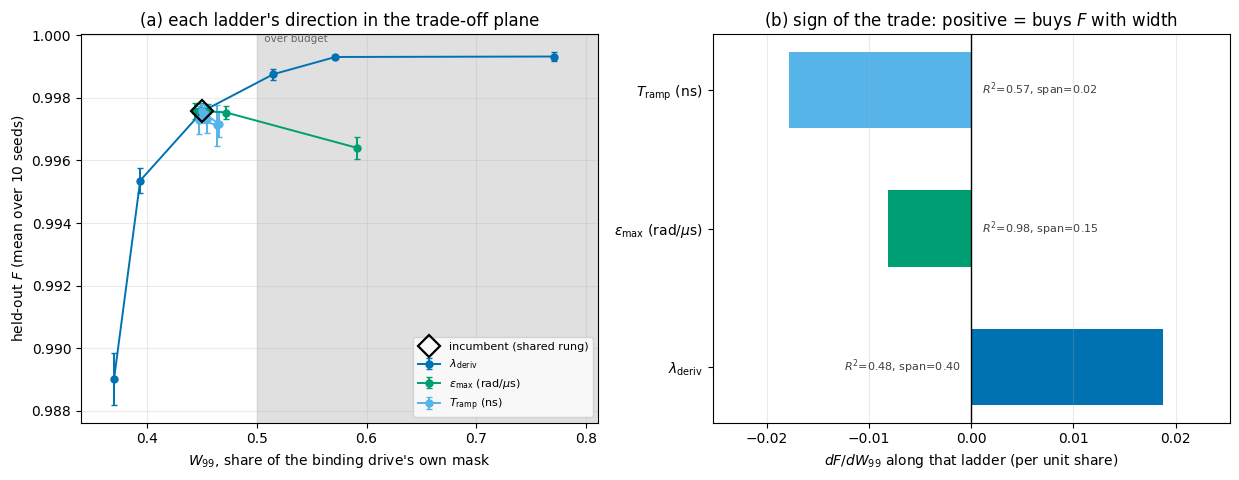

(b) IS THE RESPONSE ONE-DIMENSIONAL?

     deriv: dF/dW99 = +1.877e-02   R^2 = 0.481   W99 span = 0.401
   amp_max: dF/dW99 = -8.207e-03   R^2 = 0.980   W99 span = 0.147
   ramp_ns: dF/dW99 = -1.790e-02   R^2 = 0.573   W99 span = 0.018

  Not collinear -- the ladders do not trace one common curve, so the response
  is NOT 1-D. But only one axis climbs the trade-off: eps_max runs the DOMINATED
  direction (a tighter cap costs width AND fidelity), and T_ramp barely moves in
  W99 at all. That is why eps_max contributes no members to the Pareto front in
  Section 8, and it is a reason not to grid against it rather than a reason to.


In [14]:
# (b) THE (W99, F) PLANE. Built inline rather than through penalty_viz: this is a
# one-off structural diagnostic, not a reusable plot, and pv.plot_pareto already
# owns the (cost, fidelity) scatter that Figure 4 needs.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
ax = axes[0]
fit = {}
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    x = sub[COST_METRIC].astype(float).values
    y = sub["F_ped_heldout_mean"].astype(float).values
    ye = sub[f"F_ped_heldout_mean_std"].astype(float).values / np.sqrt(n_seeds)
    c = pv.SWEPT_COLORS.get(ax_name, "#333333")
    ax.errorbar(x, y, yerr=ye, fmt="o-", color=c, ms=5, lw=1.4, capsize=2.5,
                label=f"{pv.PENALTY_LABEL.get(ax_name, ax_name)}", zorder=3)
    sl, ic, r_, p_, _ = stats.linregress(x, y)
    fit[ax_name] = (sl, r_ ** 2, p_, x.max() - x.min())
b = base_ramp
ax.plot([b[COST_METRIC]], [b["F_ped_heldout_mean"]], "D", mfc="none", mec="k",
        ms=11, mew=1.6, label="incumbent (shared rung)", zorder=4)
xhi = float(agg_ramp[COST_METRIC].max()) + 0.04
ax.set_xlim(float(agg_ramp[COST_METRIC].min()) - 0.03, xhi)
ax.axvspan(COST_BUDGET, xhi, color="0.88", zorder=0)
ax.text(COST_BUDGET + 0.004, ax.get_ylim()[1], " over budget", fontsize=7.5,
        va="top", color="0.4")
ax.set_xlabel(r"$W_{99}$, share of the binding drive's own mask")
ax.set_ylabel(rf"held-out $F$ (mean over {n_seeds} seeds)")
ax.set_title("(a) each ladder's direction in the trade-off plane")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)

# Right panel: the same information as a slope, which is what actually decides
# whether the response is 1-D.
ax = axes[1]
names = list(fit)
sl = [fit[k][0] for k in names]
cols = [pv.SWEPT_COLORS.get(k, "#333") for k in names]
ax.barh(range(len(names)), sl, color=cols, height=0.55)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([pv.PENALTY_LABEL.get(k, k) for k in names])
# Annotate just inside the bar tip, so a negative bar's label never runs off the
# left edge into the tick labels.
# Bar-axis half-range. Named `xhalf`, not `lim`: the cells above and below
# bind `lim` to hard_amp_limit, and this is not that.
xhalf = 1.35 * max(abs(v) for v in sl)
ax.set_xlim(-xhalf, xhalf)
for i, k in enumerate(names):
    v, r2, p, span = fit[k]
    # Annotate on the OPPOSITE side of zero from the bar: the bar itself can be
    # long enough that neither end of it has room for the label.
    pad = 0.04 * xhalf
    ax.text(pad if v < 0 else -pad, i, f"$R^2$={r2:.2f}, span={span:.2f}",
            va="center", ha="left" if v < 0 else "right", fontsize=8, color="0.25")
ax.set_xlabel(r"$dF/dW_{99}$ along that ladder (per unit share)")
ax.set_title("(b) sign of the trade: positive = buys $F$ with width")
ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(f"figures/penalty_2d_structure.{ext}", dpi=160, bbox_inches="tight")
plt.show()

print("(b) IS THE RESPONSE ONE-DIMENSIONAL?\n")
for k in names:
    s, r2, p, span = fit[k]
    print(f"  {k:>8}: dF/dW99 = {s:+.3e}   R^2 = {r2:.3f}   W99 span = {span:.3f}")
print("\n  Not collinear -- the ladders do not trace one common curve, so the response")
print("  is NOT 1-D. But only one axis climbs the trade-off: eps_max runs the DOMINATED")
print("  direction (a tighter cap costs width AND fidelity), and T_ramp barely moves in")
print("  W99 at all. That is why eps_max contributes no members to the Pareto front in")
print("  Section 8, and it is a reason not to grid against it rather than a reason to.")

**Figure 3. Is the response two-dimensional?** *(a)* Each OFAT ladder drawn in the
$(W_{99}, F)$ plane, seed-averaged, with standard errors over the ten seeds; the open diamond is
the incumbent, which is the shared centre rung of all three ladders, and the shaded band is
outside the 50% budget. *(b)* The same ladders as a single number each — the slope of held-out
fidelity against occupied width — annotated with the fit's $R^2$ and the ladder's span in
$W_{99}$.

**The three ladders point in different directions, so the response is not one-dimensional — but
only one of those directions is useful.** $\lambda_{\mathrm{deriv}}$ climbs the trade-off, buying
fidelity with width across a span of 0.40 in allowance. $\epsilon_{\max}$ has a *negative* slope:
tightening the cap costs width **and** fidelity at once, which is a strictly dominated direction,
and it is the reason no $\epsilon_{\max}$ rung appears on the Pareto front in §8.
$T_{\mathrm{ramp}}$ spans 0.018 in $W_{99}$ — it barely moves along this plane at all, which is
consistent with its being a structural constraint rather than a regularizer.

Read together with the mediator map: all three axes appear to move $W_{99}$ in the **same**
direction, but only $\lambda_{\mathrm{deriv}}$ survives the per-seed check, and only it converts
that movement into fidelity. Where two axes do overlap it is as redundancy, not as a trade — and
redundancy is the case where a grid returns least.

### 7.4 Verdict: is a 2-D grid worth training?

This study trains no grid. Whether one is *worth* training is a result, and the rule for deciding
it was stated before the numbers were read, so that it could not be tuned to them.

A grid costs 9–25 configurations per seed and answers exactly one question: **do two axes
interact**, i.e. does the best setting of one depend on the setting of the other? Two axes that
are each live but act additively do not need a grid — the ladders already give the answer. §7.2 is
the cautionary precedent: the last grid this project trained cost 5.9 h and returned
one-dimensionality.

**Train a grid only if all four gates pass.**

| gate | test |
|---|---|
| **0 — possible** | The interaction's *mechanism* must be reachable in this parameter window. For $T_{\mathrm{ramp}} \times$ `hard_amp_limit` specifically: if no run ever comes near the box, the two cannot interact at these settings and the grid is pre-registered **not** to run. |
| **1 — both marginals live** | Each axis must clear §6.3's test on its own ladder: range above `FLOOR`, above the noise-only range, and $\lvert\rho\rvert > 0.9$. |
| **2 — a shared mediator** | The two axes must move the same measured response (§7.3a), **in opposite directions**, and the correlation must survive **within each seed** ($\lvert\rho\rvert > 0.9$ on the seed means *and* $\min\lvert\rho_s\rvert \geq 0.7$ across seeds). Same-sign overlap is redundancy and predicts an additive, not an interacting, response. |
| **3 — named mechanism** | A falsifiable prediction written down before the grid runs — not merely "both matter". |
| **4 — resolvable** | The smallest interaction contrast worth detecting must exceed `FLOOR` at $n$ per cell. Below that, a grid cannot resolve what it is being asked to resolve. |

**The candidate pairs, named before the sweep ran:**

- **$T_{\mathrm{ramp}} \times$ `hard_amp_limit`** — the physically coupled pair, on the argument in
  `core/ramp.py`: the ramp removes control authority at the edges, L-BFGS-B buys it back by
  inflating the *pre-image*, and `hard_amp_limit` is the only thing that bounds that inflation.
  Prediction: the ramp's effect on fidelity depends on the box, with a boundary in the plane
  beyond which runs fall into the high-leakage basin. Gated entirely on Gate 0.
- **$\lambda_{\mathrm{deriv}} \times T_{\mathrm{ramp}}$** — both act on time-domain smoothness, one
  in the interior and one at the edges. The envelope's slope is $\sim\!2.3\times$ steeper at 30 ns
  than at 70 ns, so $T_{\mathrm{ramp}}$ changes *what $\lambda_{\mathrm{deriv}}$ is charging for*.
  Prediction: the optimal $\lambda_{\mathrm{deriv}}$ shifts **down** as the ramp shortens.
- **$\lambda_{\mathrm{deriv}} \times \epsilon_{\max}$** — the current `--grid-x/--grid-y` default,
  and the weakest of the three even before the data: $\epsilon_{\max}$ is inert over most of its
  ladder by construction (§6.1).
**Settlement at $n=10$.** Seeds 48–51 were the second replication this section asked for, and
they change one gate's *margin* without changing any gate's verdict. `FLOOR` moved
$1.48\times10^{-3} \to 1.15\times10^{-3} \to 1.11\times10^{-3}$ — it has essentially stopped
falling (§6.2). No pair clears the four gates: still only one live fidelity axis, still no
opposite-sign shared mediator that survives per seed, still 57% of a
$\lambda_{\mathrm{deriv}}\times\epsilon_{\max}$ grid is a verbatim copy of the deriv ladder.

The one thing that moved is **Gate 0b for $T_{\mathrm{ramp}} \times$ `hard_amp_limit`**. Its
second condition now passes — the ramp ladder reaches 79% of the box — and its correlation
condition fails at $\rho = +0.83$ against the pre-registered 0.90, having climbed $+0.03 \to
+0.54 \to +0.83$ across the three campaigns. That pair is no longer refuted; it is a near miss
whose per-seed correlations still disagree in sign. If any pair is revisited, it is this one, and
the right instrument is a `hard_amp_limit` ladder (§7.5), not a $T_{\mathrm{ramp}}$ grid at the
fixed box of 40.

A 2-D grid is still not worth training. What the extra seeds *did* settle is the recommendation
versus the incumbent, which is now resolved at $1.56\times$ `FLOOR` with all ten seeds agreeing
in sign (§8.4).


In [15]:
# Apply the rule above. Nothing here is tuned to the outcome -- the thresholds are
# the ones stated in the markdown and FLOOR is Section 6.2's single measurement.
lim = float(df_ramp["hard_amp_limit"].iloc[0])
mx = float(df_ramp["max_abs_preimage"].max())
n_at_bound = int((df_ramp["preimage_at_bound_frac"] > 0).sum())

# --- GATE 0, for the ramp x hard_amp_limit pair only ---
#
# Two conditions, and BOTH are needed. It is not enough that some configuration
# somewhere approaches the box: the proposed interaction is that *lengthening the
# ramp* drives the pre-image into it, so the ramp ladder itself has to be what
# moves max|x|. A deriv=0 run pressing against the box shows the box is reachable
# in this window (0a) but says nothing about the ramp (0b).
ramp_x = ladder("ramp_ns")["max_abs_preimage"].astype(float).values
gate0a = (n_at_bound > 0) or (mx > 0.75 * lim)
rho_rx = mediators.loc["max_abs_preimage", "ramp_ns"]
gate0b = bool(rho_rx > 0.9 and ramp_x.max() / lim > 0.75)
gate0 = gate0a and gate0b

print("GATE 0  (is ramp x hard_amp_limit a REACHABLE interaction?)")
print(f"  0a  box reachable at all : max|x| = {mx:.2f} of {lim:.0f} ({mx/lim:.0%}), "
      f"rows at the bound = {n_at_bound}   -> {'PASS' if gate0a else 'FAIL'}")
print(f"  0b  the RAMP drives it   : max|x| along the ladder "
      f"{np.array2string(ramp_x, precision=1)}, Spearman rho = {rho_rx:+.2f}, "
      f"reaches {ramp_x.max()/lim:.0%} of the box   -> {'PASS' if gate0b else 'FAIL'}")
print(f"  -> GATE 0 {'PASS' if gate0 else 'FAIL'}: "
      + ("the ramp does push the pre-image toward a box that can bind"
         if gate0 else
         "the box is reachable, but not by the ramp, so the two cannot interact\n     "
         "at these settings. The honest follow-up is NOT a grid at hard_amp_limit = 40 "
         "but a\n     1-D sweep that lowers the box into the observed max|x| range."))

# --- GATE 1, per axis: reuse Section 6.3's verdict verbatim, no second standard ---
print(f"\nGATE 1  (per-axis liveness), FLOOR = {FLOOR:.2e}")
for ax_name in AXIS_NAMES:
    r = eff.loc[ax_name]
    print(f"  {ax_name:>8}: range {r['range F_held']:.2e} = {r['vs FLOOR']:.1f}x FLOOR, "
          f"{r['vs noise range']:.1f}x noise range, rho = {r['rho(knob, F)']:+.2f}   "
          f"-> {'LIVE' if LIVE[ax_name] else 'not identified'}")

# --- GATE 2: a shared mediator, opposite signs, surviving the per-seed check ---
#
# `strong()` (7.3a) requires BOTH the seed-mean |rho| > 0.9 AND per-seed
# correlations that agree in sign with min|rho_s| >= 0.7. A seed-mean rho alone
# is not enough: averaging noisy ladders can produce a clean monotone one.
print("\nGATE 2  (shared mediator, opposite signs, robust per seed)")

PAIRS = [("ramp_ns", "hard_amp_limit"), ("deriv", "ramp_ns"), ("deriv", "amp_max")]
shared = {}
for a, b in PAIRS:
    if b not in AXIS_NAMES:
        shared[(a, b)] = None
        print(f"  {a} x {b:<16}: `{b}` is not an axis in this sweep -- untestable here")
        continue
    hits = [(r, mediators.loc[r, a], mediators.loc[r, b])
            for r in RESPONSES
            if abs(mediators.loc[r, a]) > RHO_MIN and abs(mediators.loc[r, b]) > RHO_MIN]
    passing = [(r, ra, rb) for r, ra, rb in hits
               if np.sign(ra) != np.sign(rb) and strong(r, a) and strong(r, b)]
    shared[(a, b)] = bool(passing)
    if not hits:
        print(f"  {a} x {b:<16}: no response is moved strongly by both -> FAIL")
    for r, ra, rb in hits:
        why = ("same sign = redundant" if np.sign(ra) == np.sign(rb)
               else ("OPPOSITE and robust" if (strong(r, a) and strong(r, b))
                     else "opposite, but the seed-mean rho does not survive per seed "
                          f"(min|rho_s| {med_seed.loc[r, a]:.2f} / {med_seed.loc[r, b]:.2f})"))
        verdict_r = "PASS" if (r, ra, rb) in passing else "FAIL"
        print(f"  {a} x {b:<16}: {r} ({ra:+.2f}, {rb:+.2f}) -> {why} -> {verdict_r}")

# --- GATE 3: a named, falsifiable mechanism. Not a computable test -- it is a
# claim that has to be WRITTEN DOWN before a grid runs, so it is reported as
# whether one exists for each pair rather than evaluated from the table.
print("\nGATE 3  (named mechanism, pre-registered)")
print("  ramp_ns x hard_amp_limit : yes -- core/ramp.py's authority-loss argument")
print("                             (Section 7.4). Gate 0 refutes its premise.")
print("  deriv x ramp_ns          : yes -- both act on time-domain smoothness, one")
print("                             in the interior and one at the edges.")
print("  deriv x amp_max          : no  -- named as the code default, not from a")
print("                             mechanism. 7.3c proves part of it is a copy.")
print("  (7.5 records a mechanism the data DOES support, for a pair that was not")
print("   pre-registered: deriv x hard_amp_limit.)")

# --- GATE 4: resolvability ---
print(f"\nGATE 4  (resolvable)")
print(f"        FLOOR at n={n_seeds} is {FLOOR:.2e}; an interaction contrast smaller than "
      f"that\n        cannot be read off a grid at this replication.")

# --- VERDICT ---
verdict = [
    ("ramp_ns x hard_amp_limit", gate0 and LIVE.get("ramp_ns", False)),
    ("deriv x ramp_ns", LIVE.get("deriv", False) and LIVE.get("ramp_ns", False)
     and bool(shared[("deriv", "ramp_ns")])),
    ("deriv x amp_max", LIVE.get("deriv", False) and LIVE.get("amp_max", False)),
]
print("\nVERDICT")
for name, ok in verdict:
    print(f"  {name:<26} {'TRAIN' if ok else 'do not train'}")

if not any(ok for _, ok in verdict):
    n_dead = len(noise["amp_max"].unique()) + 1
    n_rungs = len(ladder("amp_max"))
    print("\n  No pair clears the rule, and none fails for a merely marginal reason:")
    print(f"    - Gate 1: only {sum(LIVE.values())} of 3 axes is live on fidelity, so no "
          f"pair can have two\n              live marginals.")
    print(f"    - Gate 2: no pair has an opposite-sign shared mediator that survives the")
    print(f"              per-seed check. The two candidates -- deriv x ramp_ns through")
    print(f"              endpoint_rel_to_peak, deriv x amp_max through peak_amp -- both rest")
    print(f"              on seed-mean correlations that weaken sharply within seeds.")
    print(f"    - And {n_dead} of the {n_rungs} rungs of a deriv x eps_max grid "
          f"({n_dead/n_rungs:.0%}) is provably a\n              verbatim copy of the deriv "
          f"ladder (7.3c).")
    print(f"\n  Settlement of the n={n_seeds} replication this section asked for:")
    print(f"    FLOOR  {FLOOR_N3:.2e} (n=3)  ->  {FLOOR_N6:.2e} (n=6)  ->  "
          f"{FLOOR:.2e} (n={n_seeds})")
    promoted = [(l, float(by_seed.loc[l].mean() - by_seed.loc[INCUMBENT].mean()))
                for l in distinct["label"] if l != INCUMBENT]
    now_resolved = [(l, d) for l, d in promoted if abs(d) > FLOOR]
    still_unresolved = [(l, d) for l, d in promoted if abs(d) <= FLOOR]
    print(f"    configs now resolved vs incumbent : {len(now_resolved)}")
    for l, d in sorted(now_resolved, key=lambda t: -abs(t[1])):
        print(f"      {l[:42]:<42} delta = {d:+.2e}  ({abs(d)/FLOOR:.2f} x FLOOR)")
    print(f"    still unresolved vs incumbent     : {len(still_unresolved)}")


GATE 0  (is ramp x hard_amp_limit a REACHABLE interaction?)
  0a  box reachable at all : max|x| = 40.00 of 40 (100%), rows at the bound = 7   -> PASS
  0b  the RAMP drives it   : max|x| along the ladder [24.4 25.1 29.8 30.4 28.4 31.6], Spearman rho = +0.83, reaches 79% of the box   -> FAIL
  -> GATE 0 FAIL: the box is reachable, but not by the ramp, so the two cannot interact
     at these settings. The honest follow-up is NOT a grid at hard_amp_limit = 40 but a
     1-D sweep that lowers the box into the observed max|x| range.

GATE 1  (per-axis liveness), FLOOR = 1.11e-03
     deriv: range 1.03e-02 = 9.3x FLOOR, 10.2x noise range, rho = -1.00   -> LIVE
   amp_max: range 1.17e-03 = 1.0x FLOOR, 1.1x noise range, rho = +0.41   -> not identified
   ramp_ns: range 4.45e-04 = 0.4x FLOOR, 0.4x noise range, rho = +0.26   -> not identified

GATE 2  (shared mediator, opposite signs, robust per seed)
  ramp_ns x hard_amp_limit  : `hard_amp_limit` is not an axis in this sweep -- untestable here


### 7.5 A pair the data suggests, which was *not* pre-registered

Label this honestly: the three pairs in §7.4 were named before the sweep ran; this one was not. It
comes out of the results and is therefore a **hypothesis to test**, not a finding.

**$\lambda_{\mathrm{deriv}} \times$ `hard_amp_limit`.** The sweep set out to show that ramp
duration drives pre-image inflation toward the box. At $n=10$ that is no longer refuted on seed
means — $\rho = +0.83$, having climbed from $+0.03$ at $n=3$ and $+0.54$ at $n=6$ — but it still
falls short of the Gate 0b threshold, the ladder is still not monotone (60 ns drops below 50 ns),
and, decisively, the per-seed correlations range from $-0.37$ to $+0.77$ and **disagree in sign**.
$\lambda_{\mathrm{deriv}}$ reaches the *same* seed-mean magnitude, $\rho = -0.83$, falling from
33.2 at $\lambda_{\mathrm{deriv}} = 0$ to 19.4 at $10^{-4}$ — but unlike the ramp, all ten of its
per-seed correlations agree in sign. That sign consistency, not the seed-mean magnitude, is what
now separates the two candidates. The mechanism Gate 3 asks for therefore exists, and it
attaches to a *different pair* than the one it was written for: the derivative penalty is what
charges for the large step-to-step excursions an inflated pre-image produces, and
`hard_amp_limit` is what truncates them when the penalty is too weak to.

Falsifiable prediction: **the $\lambda_{\mathrm{deriv}} = 0$ rung's fidelity should depend on
`hard_amp_limit`, and the $\lambda_{\mathrm{deriv}} = 10^{-4}$ rung's should not** — the
low-$\lambda$ end is already running at 83% of the box against the high end's 49%, on seed means,
and §4.1's near-bound census shows individual low-$\lambda$ seeds reaching 99.6%.

This pair still has to clear Gates 1, 2 and 4 like any other, and `hard_amp_limit` would have to be
promoted to an axis first (one line in `FIXED_AXES`, plus a ladder). It is recorded here so the
next study starts from the mechanism the data actually supports rather than the one this study
assumed.

**Two earlier readings have to be qualified, and the per-seed column in §7.3a is what qualifies
them.** Both were stated from seed-mean rank correlations, which is exactly the statistic that
averaging can flatter.

- *"$\lambda_{\mathrm{deriv}}$ and $T_{\mathrm{ramp}}$ fight over the endpoint."* The seed-mean
  correlations still look like that, $+0.77$ and $-0.94$ with opposite signs. Within seeds,
  neither holds: $\lambda_{\mathrm{deriv}}$ spans $+0.37$ to $+0.77$ (same sign, but weak enough
  at one seed that the ladder is not ordered there), and the ramp — which *did* hold at $n=6$ with
  $\min\lvert\rho_s\rvert = 0.71$ — now spans $-0.94$ to $+0.37$ and **changes sign across seeds**,
  so $\min\lvert\rho_s\rvert = 0.00$. Four extra seeds moved this claim from "half-established"
  to "not established on either axis", which is the outcome the per-seed column exists to catch.
  Gate 2 fails on it, and now fails more clearly than before.
- *"$\lambda_{\mathrm{deriv}}$ drives pre-image inflation."* On seed means this is $\rho = -0.83$
  at $n=10$ (it read $-0.94$ at $n=6$). Per seed it spans $-1.00$ to $-0.14$: consistently signed
  across all ten, but one seed carries almost none of it, so $\min\lvert\rho_s\rvert = 0.14$. The
  direction is safe to quote; the strength is not, and the prediction above should be tested by
  *sweeping* `hard_amp_limit`, not by leaning on this correlation.


# 8. Pareto front and the budgeted recommendation

This section turns the sweep into one recommended configuration and shows the reasoning behind
it. §8.1 fixes the selection rule before looking at any results; §8.2 applies it; §8.3
stress-tests the one design choice inside it that could be cosmetic; §8.4 names the winner and
prices its trade against the current default; §8.5 asks how much of that depends on the number
50%. Everything here reads `agg_ramp`: 17 configurations, ten seeds each.

### 8.1 Selection rule

Two things are easy to conflate. The **front** is every configuration Figure 4 draws as
non-dominated; the **recommendation** is the single point `pv.recommend` picks off it. The front is
a property of the data, the recommendation is a choice made on top of it.

**The front.** A configuration is *non-dominated* when no other configuration is simultaneously
narrower in occupied width and higher in held-out fidelity. Figure 4 plots every non-dominated
configuration, whether it is within budget or not. The front by itself says nothing about the
budget.

**The recommendation.** Picking one point off the front follows a three-step rule — two filters
and a sort — fixed before the sweep was scored so nothing here retrofits a boundary to the data:

1. **Filter 1: spectral budget.** Express each configuration's 99% occupied width as a share of
   *that drive's own* band mask, separately for cavity and transmon (`occ99_frac_cav`,
   `occ99_frac_tra`). Keep the configuration only if **both** shares are at most `COST_BUDGET`
   (50%). Because each drive is already normalised against its own allowance, comparing the single
   worse (binding) share against one threshold enforces both per-drive constraints at once (§1.6).
2. **Filter 2: fidelity floor.** Keep the configuration only if its mean held-out fidelity is at
   least `MIN_FIDELITY` (0.995). A pulse that is cheap to synthesize but does not reach a usable
   gate fidelity is not a candidate at any bandwidth, so the trade-off is bounded on both axes
   rather than one.
3. **Rank: highest held-out fidelity wins.** Among the survivors, sort by mean `F_held` and take
   the maximum. Ties break toward the lower $W_{99}$, the narrower pulse.

This is exactly what `pv.recommend` computes: filter on `occ99_frac <= COST_BUDGET` **and**
`F_ped_heldout_mean >= MIN_FIDELITY`, then sort. It is mechanism 3 of §1.6, applied to a table of
pulses trained with no knowledge of either threshold.

Note that the floor is stated on the *same column the rank step uses*, which is why Figure 4 can
draw it as a horizontal line on its own y-axis: the line the reader sees and the rows the code
keeps are the same number by construction (`visualization/penalty_viz.py`, `MIN_FIDELITY`).

**One thing the rule does not know about is the noise floor.** (Distinct from the fidelity floor
of step 2: `FLOOR` is a *resolution limit*, `MIN_FIDELITY` an *acceptance threshold*.)
Non-domination is a strict inequality: a configuration joins the front if it beats its neighbours
by $10^{-6}$, which §6.2 says is indistinguishable from noise. The front is therefore an upper
bound on how many configurations genuinely matter, and §8.2 separates the members that survive a
significance test from the ones that do not. §8.4 shows this mattering: under the tightened
budget the rule's winner and the incumbent are separated by less than $10^{-5}$.

Saved figures/penalty_pareto.png / .pdf


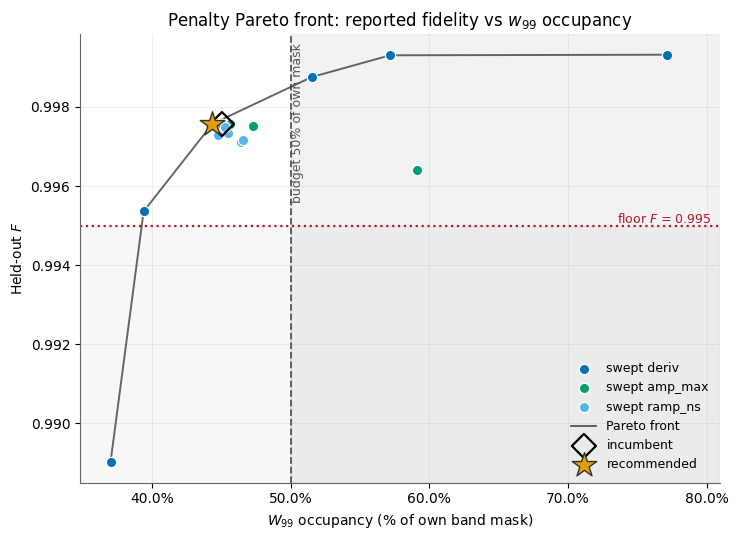

In [16]:
fig, rec = pv.plot_pareto(agg_ramp, save_path="figures/penalty_pareto",
                          max_cost=COST_BUDGET, min_fidelity=MIN_FIDELITY)

**Figure 4. Reported held-out fidelity against the 99% occupied width, as a share of each drive's
own band mask, one marker per configuration.** The x-axis is the worse of the two drives, so a
point at 60% means "the more demanding drive uses 60% of what that drive is allowed". The star is
the recommendation, the open diamond the incumbent, and the connected markers trace the
non-dominated front.

**Both filters of §8.1 are drawn, and deliberately drawn differently.** The vertical **dashed grey**
line at 50% is the spectral budget; everything to its right is over budget. The horizontal
**dotted dark-red** line at $F = 0.995$ is the fidelity floor; everything below it is rejected on
fidelity. A configuration is feasible only in the unshaded upper-left quadrant. Neither line takes
a legend entry — both are labelled in the axes, because they are constraints, not data series, and
the categorical colours are reserved for the swept axes.

The star sits almost exactly on the open diamond: at a 50% budget the rule re-selects a rung that
is statistically indistinguishable from the incumbent, which is §8.4's whole subject. The
$\lambda_{\mathrm{deriv}} = 10^{-6}$ point that the pre-ramp study recommended is now *inside*
the shaded over-budget region, at 57.2%.

All 17 points are **post-ramp**, single-phase, ten seeds — the same data as Figures 1–3. The
pre-ramp version this replaces mixed an OFAT ladder with a $5\times5$ grid at one seed and is not
comparable to it.

### 8.2 The front, and what the two filters reject

The next cell prints four things: the non-dominated front, a significance test on each of its
members against the incumbent, the configurations that exceed the 50% budget on their binding
drive, and — separately — the ones inside the budget that fail the fidelity floor. The two
rejection lists are kept apart on purpose: with two filters, a single "infeasible" count would
hide *which* constraint bit, and the two say different things about a recipe.

In [17]:
front = agg_ramp.iloc[pv.pareto_front(agg_ramp)].copy()
front["within_budget"] = front[COST_METRIC] <= COST_BUDGET
front["above_floor"] = front["F_ped_heldout_mean"] >= MIN_FIDELITY

# A Pareto front does not know about the noise floor -- non-domination is a strict
# inequality, so a config joins on a 1e-6 lead. Test every member against the
# incumbent, paired by seed, and say which ones are actually distinguishable.
def vs_incumbent(label):
    if label == INCUMBENT:
        return 0.0, np.nan, "incumbent"
    d = (by_seed.loc[label] - by_seed.loc[INCUMBENT]).values
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    p = float(2 * stats.t.sf(abs(t), len(d) - 1))
    same = (d > 0).all() or (d < 0).all()
    return d.mean(), p, ("resolved" if (p < 0.05 and same) else "within noise")


front[["dF vs incumbent", "p (paired)", "verdict"]] = [
    vs_incumbent(l) for l in front["label"]]
# to_string's `formatters` silently skip object-dtype columns, so cast first.
front[["dF vs incumbent", "p (paired)"]] = front[["dF vs incumbent",
                                                  "p (paired)"]].astype(float)
print(f"Pareto front: {len(front)} of {len(agg_ramp)} configurations\n")
print(front[["label", "F_ped_heldout_mean", "occ99_frac_cav", "occ99_frac_tra",
             "binding_drive", "within_budget", "above_floor",
             "dF vs incumbent", "p (paired)", "verdict"]]
      .sort_values("F_ped_heldout_mean")
      .to_string(index=False,
                 formatters={"occ99_frac_cav": "{:.1%}".format,
                             "occ99_frac_tra": "{:.1%}".format,
                             "dF vs incumbent": "{:+.2e}".format,
                             "p (paired)": "{:.3f}".format}))
n_real = int((front["verdict"] == "resolved").sum())
n_noise = int((front["verdict"] == "within noise").sum())
print(f"\n  {n_real} of {len(front)} front members are distinguishable from the incumbent; "
      f"{n_noise} are on the\n  front by noise. Non-domination is a strict inequality, so the "
      f"front's LENGTH is an upper\n  bound on how many configurations matter, not a count "
      f"of them.")

# Two filters now, so "infeasible" is ambiguous unless the two are separated.
# Attribute each rejection to the constraint that actually bit.
over_budget = agg_ramp[COST_METRIC] > COST_BUDGET
under_floor = agg_ramp["F_ped_heldout_mean"] < MIN_FIDELITY
print(f"\nrejected by the BUDGET ({COST_METRIC} > {COST_BUDGET:.0%} of own mask): "
      f"{int(over_budget.sum())} of {len(agg_ramp)}")
for _, r in agg_ramp[over_budget].sort_values(COST_METRIC).iterrows():
    print(f"   {r['label']:40s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  binding={r['binding_drive']}  "
          f"F={r['F_ped_heldout_mean']:.6f}")
print(f"\nrejected by the FLOOR (F_held < {MIN_FIDELITY:.3f}) but inside the budget: "
      f"{int((under_floor & ~over_budget).sum())} of {len(agg_ramp)}")
for _, r in agg_ramp[under_floor & ~over_budget].sort_values("F_ped_heldout_mean").iterrows():
    print(f"   {r['label']:40s} F={r['F_ped_heldout_mean']:.6f} at only "
          f"{r[COST_METRIC]:5.1%} of allowance  (cheap, and not good enough)")
print(f"\nfeasible under BOTH: "
      f"{int((~over_budget & ~under_floor).sum())} of {len(agg_ramp)}")
span_F = front["F_ped_heldout_mean"].max() - front["F_ped_heldout_mean"].min()
span_W = front[COST_METRIC].max() - front[COST_METRIC].min()
print(f"\nfront extent: {span_F:.2e} in held-out F for {span_W:.1%} of allowance "
      f"({span_F/FLOOR:.1f} floors of fidelity)")

Pareto front: 6 of 17 configurations

                                   label  F_ped_heldout_mean occ99_frac_cav occ99_frac_tra binding_drive  within_budget  above_floor dF vs incumbent p (paired)      verdict
         deriv=0.0001_amp=8e-05_disc=0.5            0.989011          29.8%          36.0%           tra           True        False       -8.56e-03      0.000     resolved
          deriv=3e-05_amp=8e-05_disc=0.5            0.995359          31.3%          39.4%           tra           True         True       -2.21e-03      0.000     resolved
deriv=1e-05_amp=8e-05_disc=0.5_ampmax=22            0.997572          34.8%          44.4%           tra           True         True       +5.35e-06      0.695 within noise
          deriv=3e-06_amp=8e-05_disc=0.5            0.998756          41.1%          51.5%           tra          False         True       +1.19e-03      0.000 within noise
          deriv=1e-06_amp=8e-05_disc=0.5            0.999307          46.0%          57.2%       

**Table 7. The non-dominated front, its significance, and every configuration the two filters
reject.** `within_budget` applies the 50%-of-own-mask line to each front member and `above_floor`
the $F \geq 0.995$ line; the two per-drive shares are shown separately, and `binding_drive` names
the one the max is taken from. `dF vs incumbent` and `p (paired)` compare each member to the
incumbent seed by seed; `verdict` is `resolved` only when the paired test clears $p < 0.05$ **and**
all ten seeds agree in sign.

**The front itself is unchanged by the tightened rule** — non-domination is a property of the data,
not of the thresholds — so the six members and their four `resolved` verdicts are the same as at
any other budget. What changes is how many of them survive the filters: **two of six**.

**The front shrank from nine members to six as seeds were added, and two of the six are still
not distinguishable from the incumbent.** One is the $\epsilon_{\max} = 22$ rung, which sits
$5\times10^{-6}$ above the incumbent at $p = 0.695$ — it is on the front only because
non-domination is a strict inequality, and $\epsilon_{\max} = 22$ is bit-identical to the incumbent
at half its seeds anyway (§6.2). Under the 50% budget this rung is also the **recommendation**,
which is the uncomfortable result §8.4 has to state plainly. The other is
$\lambda_{\mathrm{deriv}} = 3\times10^{-6}$, which clears the paired test on $p$ but not the sign
requirement: at $+1.19\times10^{-3}$ it is only $1.07\times$ the floor, and its seeds do not all
agree in direction.

That the front *contracted* under replication is the expected behaviour and is worth stating: at
six seeds, three $T_{\mathrm{ramp}}$ rungs and one more $\epsilon_{\max}$ rung held front
positions on leads of a few $10^{-4}$, and four more seeds removed them. The front's *length* was
never a count of configurations that matter, and it has now shrunk toward one. The four that do
resolve are all $\lambda_{\mathrm{deriv}}$ rungs — including the $\lambda = 0$ negative control —
the same conclusion §6.3 reached from a completely different direction.

**The two filters cut the front from opposite ends, and between them leave two members.** The
budget removes the wide, high-fidelity end — $\lambda_{\mathrm{deriv}} = 0$ (77.1%),
$10^{-6}$ (57.2%) and $3\times10^{-6}$ (51.5%) — and the floor removes the cheap, low-fidelity end,
$\lambda_{\mathrm{deriv}} = 10^{-4}$ ($F = 0.9890$ at only 37.0% of allowance). What is left is
$3\times10^{-5}$ and $\epsilon_{\max} = 22$, and the rank step takes the second.

**Across all 17 configurations: the budget rejects 4, the floor rejects 1 more, and 12 survive.**
The budget's four are the $\lambda_{\mathrm{deriv}} = 0$ negative control at 77.1% of the cavity's
own allowance, the two low-$\lambda_{\mathrm{deriv}}$ rungs above it, and $\epsilon_{\max} = 10$ —
the one amplitude rung tight enough that the optimizer buys authority back in bandwidth (59.1%,
and the only $\epsilon_{\max}$ rung the budget touches). The floor's one is
$\lambda_{\mathrm{deriv}} = 10^{-4}$, and it is worth noticing that this is a rejection the old
cost-only rule could not make: at 37.0% it was the *cheapest* configuration in the study and
comfortably inside any budget, yet it does not reach a usable gate. That is precisely the failure
mode the second filter exists to catch.

Note that the negative control is therefore still excluded twice over, once by the budget and once
by the paired test, on independent grounds. §8.3 takes up *which drive* that rejection is about,
because at 50% the answer has changed.


### 8.3 Which drive binds, and why per-drive normalisation earns its keep

The question this subsection answers: does budgeting each drive against its own allowance, instead
of comparing raw bandwidth in MHz, actually change which configurations survive? The two drives
are budgeted separately, and whether that is a distinction without a difference is an empirical
question, not a stylistic one.

**At the 50% budget the honest answer is "not on this data".** The subsection is kept, and the
counterfactual still run, because the null result is the finding — and because the answer was
*yes* at 70%, on the same 17 configurations. A design choice that stops being observable when a
threshold moves has not been vindicated by the data; it has merely stopped being tested by it.


In [18]:
# Occupied width per axis and per drive, in MHz and as a share of that drive's own
# mask, plus which drive the budget binds on.
for ax_name in AXIS_NAMES:
    sub = df_ramp[df_ramp.swept == ax_name]
    print(f"{ax_name}  (n={len(sub)} runs)")
    for drive in ("cav", "tra"):
        mhz, frac = sub[f"occ99_{drive}_MHz"], sub[f"occ99_frac_{drive}"]
        print(f"   {drive}: {mhz.min():5.2f}-{mhz.max():5.2f} MHz "
              f"= {frac.min():5.1%}-{frac.max():5.1%} of {BAND_LIMITS_MHz[drive]:.0f} MHz")
    print(f"   binding drive: {sub['binding_drive'].value_counts().to_dict()}")

cav_bound = agg_ramp[agg_ramp["binding_drive"] == "cav"]
print(f"\ncavity-binding configurations: {len(cav_bound)} of {len(agg_ramp)}")
for _, r in cav_bound.iterrows():
    verdict = "within budget" if r[COST_METRIC] <= COST_BUDGET else "REJECTED"
    print(f"   {r['label']:40s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  ->  {verdict}")

# The counterfactual: what would a transmon-only rule have done? Both sides
# carry the same fidelity floor, so the only difference under test is how the
# spectral constraint is normalised.
print(f"\ncounterfactual -- a rule that budgeted only the transmon at {COST_BUDGET:.0%}:")
floor_ok = agg_ramp["F_ped_heldout_mean"] >= MIN_FIDELITY
tra_only = agg_ramp[(agg_ramp["occ99_frac_tra"] <= COST_BUDGET) & floor_ok]
per_drive = agg_ramp[(agg_ramp[COST_METRIC] <= COST_BUDGET) & floor_ok]
best_tra = tra_only.sort_values("F_ped_heldout_mean").iloc[-1]
print(f"   feasible set {len(tra_only)} of {len(agg_ramp)} (vs "
      f"{len(per_drive)} under the per-drive rule)")
print(f"   it would recommend  {best_tra['label']}")
print(f"                       cav {best_tra['occ99_frac_cav']:.1%}, "
      f"tra {best_tra['occ99_frac_tra']:.1%}, F = {best_tra['F_ped_heldout_mean']:.6f}")
print(f"   the per-drive rule recommends  {rec['label']}")
admitted_only_by_tra = sorted(set(tra_only["label"]) - set(per_drive["label"]))
if best_tra["label"] != rec["label"]:
    print(f"\n   -> the two rules DISAGREE, and the transmon-only rule picks the one "
          f"configuration\n      that removes a constraint outright. Per-drive "
          f"normalisation is load-bearing here,\n      not cosmetic.")
elif not admitted_only_by_tra:
    print(f"\n   -> the two rules AGREE, on the same feasible set. At this budget the "
          f"cavity-binding\n      configuration is over the line on its TRANSMON share "
          f"too, so a transmon-only rule\n      rejects it without help. The per-drive "
          f"argument is unchanged -- it is about what the\n      constraint MEANS, not "
          f"about this table -- but at {COST_BUDGET:.0%} this data no longer "
          f"demonstrates it.")
else:
    print(f"\n   -> the two rules pick the same winner, but the transmon-only rule "
          f"additionally admits\n      {admitted_only_by_tra}.")

deriv  (n=60 runs)
   cav: 10.91-43.64 MHz = 20.2%-80.8% of 54 MHz
   tra: 20.91-43.64 MHz = 31.7%-66.1% of 66 MHz
   binding drive: {'tra': 48, 'cav': 12}
amp_max  (n=60 runs)
   cav: 12.73-24.55 MHz = 23.6%-45.5% of 54 MHz
   tra: 26.36-44.55 MHz = 39.9%-67.5% of 66 MHz
   binding drive: {'tra': 60}
ramp_ns  (n=50 runs)
   cav: 16.36-34.55 MHz = 30.3%-64.0% of 54 MHz
   tra: 26.36-36.36 MHz = 39.9%-55.1% of 66 MHz
   binding drive: {'tra': 48, 'cav': 2}

cavity-binding configurations: 1 of 17
   deriv=0_amp=8e-05_disc=0.5               cav 77.1%  tra 63.6%  ->  REJECTED

counterfactual -- a rule that budgeted only the transmon at 50%:
   feasible set 12 of 17 (vs 12 under the per-drive rule)
   it would recommend  deriv=1e-05_amp=8e-05_disc=0.5_ampmax=22
                       cav 34.8%, tra 44.4%, F = 0.997572
   the per-drive rule recommends  deriv=1e-05_amp=8e-05_disc=0.5_ampmax=22

   -> the two rules AGREE, on the same feasible set. At this budget the cavity-binding
      config

**Table 8. Occupied width by axis and by drive, and the binding drive.** The cavity drive is
consistently the narrower one in MHz — it has to be, its mask is 12 MHz tighter — but in *share of
its own allowance* it is not always the slacker one.

**Exactly one configuration binds on the cavity, and it is the one the rule exists to catch.**
$\lambda_{\mathrm{deriv}} = 0$ puts its cavity drive at **77.1%** of the cavity mask while its
transmon drive sits at **63.6%** of the transmon mask. That asymmetry is real and is the whole
reason the two drives are normalised separately.

**But at a 50% budget the counterfactual no longer separates the two rules.** 63.6% is over 50%
as well, so a transmon-only rule rejects this configuration without any help from the cavity
share: the two rules admit the *identical* feasible set, and the printout says so. Compare the
70% budget, where the same configuration sat at 63.6% on the transmon — under the line — and a
transmon-only rule would have **admitted** the one negative control in the study and handed it the
recommendation outright.

Read that as a statement about the threshold, not about the normalisation. The per-drive argument
is a claim about what the constraint *means* — the cavity mask is 54 MHz and the transmon's 66,
they are separate hardware chains, and nothing physically experiences the max of two shares of
different allowances (§1.6) — and a tighter budget does not make that claim less true. It makes it
unobservable here, because tightening the spectral constraint on *both* drives eventually catches
the cavity-binding case through the transmon anyway. **The demonstration is now archival: it lives
at 70%, in this same table, and cannot be reproduced at 50%.** Any future change to the budget
should re-check this cell rather than assume the argument still has data behind it.

The per-run counts printed above show more cavity-binding *runs* than one: the
$\lambda_{\mathrm{deriv}}$ ladder contributes 12 cavity-binding runs of 60, concentrated on the
low-$\lambda$ rungs, plus 2 of the 50 $T_{\mathrm{ramp}}$ runs where the two drives are
effectively tied. The $\epsilon_{\max}$ ladder binds on the transmon in all 60. Only one
*configuration* binds on the cavity once the seeds are averaged.

Pre-ramp, this argument had to be made across two cavity-binding grid configurations with a
confound between them. Post-ramp it lands on one configuration with nothing else in the way,
which is a cleaner demonstration of the same point on independent data — at the budget where it
is still a demonstration.


### 8.4 Recommendation vs. the incumbent

The winning configuration, then the full metric-by-metric comparison against the status quo, with
the margin priced against §6.2's floor rather than quoted bare. Under the tightened rule this is
the subsection that changed most, and not in the direction a recommendation usually moves.


In [19]:
print(f"Recommended under {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's "
      f"own mask AND F_held >= {MIN_FIDELITY:.3f}:\n  {rec['label']}\n")
print(f"  mean F_held : {rec['F']:.6f}")
print(f"  min F_held  : {rec['F_ped_heldout_min']:.6f}")
print(f"  99% occupied width  : cavity  {rec['occ99_frac_cav']:.1%} of "
      f"{BAND_LIMITS_MHz['cav']:.0f} MHz ({rec['occ99_cav_MHz']:.2f} MHz)")
print(f"                        transmon {rec['occ99_frac_tra']:.1%} of "
      f"{BAND_LIMITS_MHz['tra']:.0f} MHz ({rec['occ99_tra_MHz']:.2f} MHz)"
      f"   <- binding: {rec['binding_drive']}")
print(f"  robustness spread   : {rec['robustness_spread']:.3e}")
print(f"  peak amplitude      : {rec['peak_amp']:.1f} rad/us")
print(f"  endpoint / peak     : {rec['endpoint_rel_to_peak']:.2%}")
print("  penalties           :", {p: float(rec[f"lambda_{p}"]) for p in PENALTY_NAMES},
      f"amp_max={rec['amp_max']:.0f}, ramp_ns={rec['ramp_ns']:.0f}")

# Price the margin against the floor, and cross-check it with the paired test --
# two routes to the same question, because a margin of a few floors deserves both.
d = (by_seed.loc[rec["label"]] - by_seed.loc[INCUMBENT]).values
t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
p = float(2 * stats.t.sf(abs(t), len(d) - 1))
print(f"\nis the margin real?")
print(f"  dF vs incumbent      : {d.mean():+.3e}  = {d.mean()/FLOOR:.2f} x FLOOR "
      f"({FLOOR:.2e})")
print(f"  per-seed differences : "
      f"{np.array2string(d, formatter={'float': lambda v: f'{v:+.2e}'})}"
      f"  ({'all same sign' if (d > 0).all() or (d < 0).all() else 'SIGN FLIPS'})")
print(f"  paired t({len(d)-1})           : {t:+.2f},  p = {p:.3f}")
print(
    "  -> "
    + ("resolved" if (p < 0.05 and abs(d.mean()) > FLOOR)
       else "resolved by p, not by FLOOR" if p < 0.05
       else "NOT resolved")
    + f". n={len(d)} paired differences; this is the settlement Section 7.4 asked for."
)


Recommended under occ99_frac <= 50% of each drive's own mask AND F_held >= 0.995:
  deriv=1e-05_amp=8e-05_disc=0.5_ampmax=22

  mean F_held : 0.997572
  min F_held  : 0.993329
  99% occupied width  : cavity  34.8% of 54 MHz (18.82 MHz)
                        transmon 44.4% of 66 MHz (29.27 MHz)   <- binding: tra
  robustness spread   : 4.836e-03
  peak amplitude      : 20.4 rad/us
  endpoint / peak     : 1.73%
  penalties           : {'deriv': 1e-05, 'amp': 8e-05, 'disc': 0.5} amp_max=22, ramp_ns=48

is the margin real?
  dF vs incumbent      : +5.348e-06  = 0.00 x FLOOR (1.11e-03)
  per-seed differences : [+0.00e+00 +0.00e+00 +0.00e+00 -5.67e-05 +9.12e-05 +0.00e+00 +4.78e-05
 +1.48e-05 +0.00e+00 -4.36e-05]  (SIGN FLIPS)
  paired t(9)           : +0.41,  p = 0.695
  -> NOT resolved. n=10 paired differences; this is the settlement Section 7.4 asked for.


In [20]:
comp = pd.DataFrame({"incumbent": base_ramp, "recommended": rec}).T
keep = [f"lambda_{p}" for p in PENALTY_NAMES] + [
    "amp_max", "ramp_ns", "F_ped_heldout_mean", "F_ped_heldout_min", "robustness_spread",
    COST_METRIC, "occ99_frac_cav", "occ99_frac_tra", "occ99_MHz", "n_bar_drive",
    "peak_amp", "endpoint_rel_to_peak", "max_abs_preimage", "F_coh_train", "overfit_gap",
]
comp = comp[[c for c in keep if c in comp.columns]].astype(float)
comp.loc["delta"] = comp.loc["recommended"] - comp.loc["incumbent"]
comp.round(6)

,lambda_deriv,lambda_amp,lambda_disc,amp_max,ramp_ns,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,occ99_MHz,n_bar_drive,peak_amp,endpoint_rel_to_peak,max_abs_preimage,F_coh_train,overfit_gap
incumbent,0.00001,0.00008,0.5,40.0,48.0,0.997567,0.993251,0.004914,0.450413,0.348485,0.450413,29.727273,2.470138,20.524765,0.017087,29.804046,0.998159,0.000585
recommended,0.00001,0.00008,0.5,22.0,48.0,0.997572,0.993329,0.004836,0.443526,0.348485,0.443526,29.272727,2.441388,20.408979,0.017276,29.530952,0.998156,0.000575
delta,0.00000,0.00000,0.0,-18.0,0.0,0.000005,0.000077,-0.000077,-0.006887,0.000000,-0.006887,-0.454545,-0.028750,-0.115785,0.000189,-0.273094,-0.000003,-0.000010


**Table 9. Incumbent, recommendation, and their difference** across the weights and every scored
metric.

**The recommendation is $\epsilon_{\max} = 22$ — the incumbent's recipe with a tighter amplitude
cap, and nothing else changed.** $\lambda_{\mathrm{deriv}}$ stays at $10^{-5}$, `ramp_ns` stays at
its 48 ns default. This is a different answer from the one the pre-ramp study and the 70%-budget
version of this section both gave ($\lambda_{\mathrm{deriv}} = 10^{-6}$), and the reason is
mechanical rather than physical: $10^{-6}$ buys its fidelity with bandwidth, at 57.2% of the
transmon's allowance, and a 50% budget will not pay for it. §8.5 shows the crossover sitting
between 50% and 60%.

**The margin is not real, and this is the section's main result.** $+5.3\times10^{-6}$ of held-out
fidelity is $0.005\times$ the $n=10$ floor — roughly two hundred times *below* the resolution of
this pipeline — the paired test gives $t(9) = +0.41$, $p = 0.695$, and the per-seed differences
change sign. The strongest statement the data supports is that **the tightened rule re-selects the
incumbent**, under a label that differs only in a knob that mostly does not bind.

"Mostly does not bind" is literal. Of the ten seeds, **five produce a bit-identical pulse** to the
incumbent: $\epsilon_{\max} = 22$ sits above the element-wise peak of the converged waveform at
those seeds, `amplitude_penalty` is exactly zero with an exactly zero gradient, and the optimizer
is solving the identical problem under a different `config_hash` (§6.2, step 1). Of the remaining
five, three move up and two move down, all by less than $10^{-4}$. The filter is ranking on
differences it cannot measure, and something has to come first.

The cost side is correspondingly small: **0.7 points** of the binding drive's allowance (44.4% vs
45.0%, or 29.27 vs 29.73 MHz), with the **cavity share exactly identical** (18.82 MHz both) — the
tighter cap does not touch the cavity drive at all. Peak amplitude falls 20.52 → 20.41 rad/µs and
roughness is unchanged. Contrast the 70%-budget answer, which bought $+1.74\times10^{-3}$ of
fidelity — $1.56\times$ the floor, ten seeds unanimous, $t(9) = +6.23$ — for **+12.1 points** of
allowance. Under the 70% rule there was a real trade to price; under the 50% rule there is not.

The two metrics the mean does not show agree, and agree at the same negligible scale: the worst
held-out truncation is better by $7.7\times10^{-5}$ ($0.99333$ against $0.99325$) and the
robustness spread is lower by the same order. Nothing here is trading tail risk for average
performance — but nothing here is buying anything either.

**How to read this.** A recommendation that lands on the incumbent is a legitimate outcome of a
pre-registered rule, not a failure of it: the rule was fixed before the thresholds were tightened,
and it says that at a 50% spectral budget the current default is already at the top of the
feasible set. The actionable content is the *negative* one — **there is no evidence in this sweep
for changing the production recipe at a 50% budget**, and the $10^{-6}$ recipe that the 70% rule
endorsed is specifically out of reach. Reporting $\epsilon_{\max} = 22$ as an improvement would be
reading an argmax below the floor as a result, which §8.5 and §6.2 both exist to prevent.

Whether a 50% budget is the right constraint is a hardware question, not an optimization one
(§1.3), which is exactly why it enters as a constraint rather than as another term in
$\mathcal{C}(u)$.

### 8.5 Budget sensitivity

This closes the section by checking how much the recommendation depends on the one number, 50%,
that §8.1's first filter step was set at. If the answer changed sharply for a small move in that
number, the recommendation would be fragile rather than robust. The fidelity floor is held fixed
at 0.995 down the ladder so that only one constraint is moving.


In [21]:
# Budget sensitivity: how does the recommendation move with the constraint?
# The budget is a percentage of each drive's OWN mask, so the ladder is readable
# without knowing any metric's scale by heart. Re-selection is free -- no pulse is
# retrained, the filter simply moves.
#
# The fidelity floor is held FIXED at MIN_FIDELITY down the whole ladder: this
# table sweeps one constraint, so the other has to stay put or the rows are not
# comparable. `n feasible` counts rows clearing both.
rows = []
for frac in (0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 1.00):
    row = {"budget (% own mask)": frac,
           "cav cap (MHz)": frac * BAND_LIMITS_MHz["cav"],
           "tra cap (MHz)": frac * BAND_LIMITS_MHz["tra"],
           "n feasible": int(((agg_ramp[COST_METRIC] <= frac)
                              & (agg_ramp["F_ped_heldout_mean"] >= MIN_FIDELITY)).sum())}
    try:
        r = pv.recommend(agg_ramp, max_cost=frac, min_fidelity=MIN_FIDELITY)
        # Is this pick actually distinguishable from the incumbent, or is the
        # filter just handing the title to whichever noisy config survived?
        dF, p, verdict = vs_incumbent(r["label"])
        row.update({"recommended": r["label"], "F_held": r["F"], "W99 (frac)": r["cost"],
                    "dF vs incumbent": dF, "vs incumbent": verdict})
    except ValueError:
        row.update({"recommended": "(none feasible)", "F_held": np.nan,
                    "W99 (frac)": np.nan, "dF vs incumbent": np.nan,
                    "vs incumbent": "--"})
    rows.append(row)
sens = pd.DataFrame(rows)
sens["recommended"] = sens["recommended"].str.replace("_amp=8e-05_disc=0.5", "",
                                                      regex=False)
sens.style.format({"budget (% own mask)": "{:.0%}", "cav cap (MHz)": "{:.1f}",
                   "tra cap (MHz)": "{:.1f}", "F_held": "{:.6f}",
                   "W99 (frac)": "{:.1%}", "dF vs incumbent": "{:+.2e}"}).hide(axis="index")

budget (% own mask),cav cap (MHz),tra cap (MHz),n feasible,recommended,F_held,W99 (frac),dF vs incumbent,vs incumbent
30%,16.2,19.8,0,(none feasible),nan,nan%,+nan,--
35%,18.9,23.1,0,(none feasible),nan,nan%,+nan,--
40%,21.6,26.4,1,deriv=3e-05,0.995359,39.4%,-2.21e-03,resolved
45%,24.3,29.7,4,deriv=1e-05_ampmax=22,0.997572,44.4%,+5.35e-06,within noise
50%,27.0,33.0,12,deriv=1e-05_ampmax=22,0.997572,44.4%,+5.35e-06,within noise
60%,32.4,39.6,15,deriv=1e-06,0.999307,57.2%,+1.74e-03,resolved
70%,37.8,46.2,15,deriv=1e-06,0.999307,57.2%,+1.74e-03,resolved
80%,43.2,52.8,16,deriv=0,0.999321,77.1%,+1.75e-03,resolved
100%,54.0,66.0,16,deriv=0,0.999321,77.1%,+1.75e-03,resolved


**Table 10. The recommendation as a function of the budget**, swept as a share of *each drive's
own* band mask, with the two implied MHz caps alongside. The fidelity floor stays at
$F \geq 0.995$ on every rung — this table sweeps one constraint, so the other has to hold still —
and `n feasible` counts the configurations clearing both. `vs incumbent` carries §8.2's paired test
through to every rung, so the table shows not just what the filter picks but whether the pick is
distinguishable from the pulse it would replace.

The recommendation is not knife-edge, but the chosen operating point sits just below an abrupt
transition. As the budget tightens the pick walks down the ladder in four steps:
$\lambda_{\mathrm{deriv}} = 0$ at 100% and 80%, $10^{-6}$ at 70% and 60%, $\epsilon_{\max} = 22$
at 50% and 45%, and $3\times10^{-5}$ at 40% — losing about $4.0\times10^{-3}$ of held-out fidelity
over that range. At 35% and below nothing is feasible at all. Loosening past 70% admits the
$\lambda_{\mathrm{deriv}} = 0$ family and the selection collapses onto a negative control, which is
the sense in which the budget is doing the work the penalty study exists to do. **Note that the
fidelity floor does not stop that collapse** — the control reaches $F = 0.9993$ and clears 0.995
comfortably. The two filters cut different ends of the front, and only the budget cuts this one.

**The 50%–60% step is the one that matters, and 50% is on its lower side.** Crossing from 60% down
to 50% swaps a *resolvable* pick ($\lambda_{\mathrm{deriv}} = 10^{-6}$, $+1.74\times10^{-3}$ over
the incumbent, ten seeds unanimous) for an *unresolvable* one ($\epsilon_{\max} = 22$,
$+5\times10^{-6}$, signs flipping), because $10^{-6}$ costs 57.2% of allowance and a 50% budget
will not pay for it. The feasible count nearly triples over that same step, 4 → 12 → 15, so the
change is not the filter running out of candidates; it is the filter losing the only candidates
that were distinguishable.

**The 45%–50% plateau is an artifact rung, and that is the whole of §8.4.** At both budgets the
filter picks the $\epsilon_{\max} = 22$ rung that §8.2 classified as *within noise* of the
incumbent — it wins because the survivors there are separated by less than the floor, and something
has to be ranked first. It is the same rung that is bit-identical to the incumbent at five of ten
seeds, so across that plateau the filter is, for half the seeds, recommending the incumbent under a
different name. **The chosen 50% budget sits at the top of that plateau**, one step below the
resolvable regime. This is the general hazard of ranking on a noisy metric, and the reason
`vs incumbent` belongs in this table: **a recommendation should be reported with the floor beside
it, not as a bare argmax.**

At 40% the filter picks $\lambda_{\mathrm{deriv}} = 3\times10^{-5}$, which *is* resolvable against
the incumbent — but resolvably **worse**, by $-2.2\times10^{-3}$, and its $F = 0.99536$ clears the
0.995 floor by less than a floor's width. Tightening below 50% therefore does not buy a better
recipe; it buys a measurably worse one, and then nothing. **There is no budget in this ladder at
which a resolvable improvement on the incumbent is also feasible**: every configuration that beats
it resolvably costs more than 50% of allowance.

**The remaining caveat is convergence, not the metric.** Width had not converged by 1500
iterations (§4.3), so a configuration sitting near the line could cross it with more training. That
matters more at 50% than it did at 70%: four configurations now sit within a few points of the
budget line rather than one, so the feasible set is more exposed to the drift §4.3 measured.
Neither continued configuration was one the budget rejects, so this does not bound the marginal
loser's drift.


# 9. Summary table

Written to `tables/penalty_sweep_summary_ramp.csv` and `.tex`. The unsuffixed
`tables/penalty_sweep_summary.csv` is the pre-ramp artifact `penalty_optimization_report.tex`
`\input`s; this cell must not overwrite it.


In [22]:
summary = pv.summary_table(df_rank, out_csv="tables/penalty_sweep_summary_ramp.csv",
                           max_cost=COST_BUDGET, min_fidelity=MIN_FIDELITY)
summary.head(12).round(6)

budget: occ99_frac <= 50% of own mask  (13/17 pass)
floor : F_ped_heldout_mean >= 0.9950  (16/17 pass)
both  : 12/17 feasible
Saved tables/penalty_sweep_summary_ramp.csv
Saved tables/penalty_sweep_summary_ramp.tex


,label,swept,lambda_deriv,lambda_amp,lambda_disc,amp_max,ramp_ns,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,binding_drive,occ99_cav_MHz,occ99_tra_MHz,sigma_f_MHz,centroid_tra_MHz,n_bar_drive,bandwidth_MHz,peak_amp,roughness,endpoint_rel_to_peak,max_abs_preimage,preimage_at_bound_frac,F_coh_train,overfit_gap,within_budget,above_floor,n_seeds
6,deriv=1e-05_amp=8e-05_disc=0.5_ampmax=22,amp_max,0.00001,0.00008,0.5,22.0,48.0,0.997572,0.993329,0.004836,0.443526,0.348485,0.443526,tra,18.818182,29.272727,6.698500,-5.356405,2.441388,8.611859,20.408979,1.097856,0.017276,29.530952,0.000000,0.998156,0.000575,True,True,10
7,deriv=1e-05_amp=8e-05_disc=0.5_ampmax=26,amp_max,0.00001,0.00008,0.5,26.0,48.0,0.997571,0.993224,0.004949,0.449036,0.348485,0.449036,tra,18.818182,29.636364,6.701213,-5.400534,2.461501,8.642139,20.675584,1.096092,0.017335,29.889469,0.000000,0.998167,0.000588,True,True,10
5,deriv=1e-05_amp=8e-05_disc=0.5_ampmax=18,amp_max,0.00001,0.00008,0.5,18.0,48.0,0.997568,0.993519,0.004617,0.455923,0.350168,0.455923,tra,18.909091,30.090909,6.711612,-5.329992,2.429349,8.617663,19.265953,1.094564,0.018153,30.515270,0.000000,0.998130,0.000552,True,True,10
2,deriv=1e-05_amp=8e-05_disc=0.5,deriv,0.00001,0.00008,0.5,40.0,48.0,0.997567,0.993251,0.004914,0.450413,0.348485,0.450413,tra,18.818182,29.727273,6.708707,-5.419483,2.470138,8.658058,20.524765,1.097779,0.017087,29.804046,0.000000,0.998159,0.000585,True,True,10
8,deriv=1e-05_amp=8e-05_disc=0.5_ampmax=30,amp_max,0.00001,0.00008,0.5,30.0,48.0,0.997567,0.993251,0.004914,0.450413,0.348485,0.450413,tra,18.818182,29.727273,6.708707,-5.419483,2.470138,8.658058,20.524765,1.097779,0.017087,29.804046,0.000000,0.998159,0.000585,True,True,10
4,deriv=1e-05_amp=8e-05_disc=0.5_ampmax=14,amp_max,0.00001,0.00008,0.5,14.0,48.0,0.997530,0.994039,0.003968,0.472452,0.356902,0.472452,tra,19.272727,31.181818,6.895104,-5.499763,2.506729,8.842743,17.300314,1.109288,0.023902,28.987694,0.000409,0.998003,0.000471,True,True,10
12,deriv=1e-05_amp=8e-05_disc=0.5_ramp=60,ramp_ns,0.00001,0.00008,0.5,40.0,60.0,0.997488,0.993651,0.004408,0.452862,0.367003,0.451791,tra,19.818182,29.818182,6.793461,-5.391599,2.457429,8.740257,21.319280,1.217363,0.011749,28.353407,0.000318,0.998057,0.000559,True,True,10
11,deriv=1e-05_amp=8e-05_disc=0.5_ramp=50,ramp_ns,0.00001,0.00008,0.5,40.0,50.0,0.997333,0.995006,0.002681,0.454545,0.362888,0.454545,tra,19.595960,30.000000,6.926441,-5.598910,2.551919,8.947548,23.300495,1.251143,0.014595,30.425265,0.000051,0.997685,0.000349,True,True,9
10,deriv=1e-05_amp=8e-05_disc=0.5_ramp=40,ramp_ns,0.00001,0.00008,0.5,40.0,40.0,0.997302,0.995292,0.002296,0.447658,0.382155,0.447658,tra,20.636364,29.545455,7.021537,-5.437145,2.478188,8.909012,21.859809,1.229867,0.016976,25.101275,0.000000,0.997582,0.000279,True,True,10
13,deriv=1e-05_amp=8e-05_disc=0.5_ramp=70,ramp_ns,0.00001,0.00008,0.5,40.0,70.0,0.997167,0.991859,0.006071,0.465565,0.373737,0.465565,tra,20.181818,30.727273,7.060204,-5.695387,2.595892,9.108535,20.918239,1.207155,0.010682,31.617148,0.000455,0.997926,0.000749,True,True,10


**Table 11. Top 12 configurations by mean F_held**, with their weights and pulse
cost. The full table, all 17 post-ramp configurations, is in `tables/penalty_sweep_summary_ramp.csv`.


# 10. Mid-training snapshots: does a cheap screen preserve the ranking?

`core.optimizer.optimize_multi_state_pulse`'s `snapshot_iters` callback copies the in-progress
pulse array at 500 and 1000 iterations for negligible optimizer-side cost;
`analysis.penalty_sweep.snapshot_scores` re-scores those snapshots exactly as a finished run
would be scored, at $\sim\!1.7\%$ of full training cost. Every OFAT configuration therefore
carries a maxiter-sensitivity reading for free (columns `F_ped_heldout_mean@500`,
`occ99_frac@500`, ... in `df_ramp`). This is the post-ramp 10-seed table (17 recipes × 10 seeds); every row carries
`@500` / `@1000` columns from training. The pre-ramp seed-42 force-retrain archaeology does
not apply here.

The question the mechanism exists to answer: if the fidelity *ranking* across configurations is
already settled at 500 iterations (a third of the `maxiter=1500` budget), a sweep can shortlist
on the cheap partial run and only fully train the survivors.


### 10.1 In plain terms

Fully training all 17 candidate configurations per gate is expensive (about 20 min each at this recipe). The question this section asks: can that cost be cut by stopping early, throwing out
the configurations that already look weak, and only paying full price on the ones that look
promising?

**"Screen"** here means what it means anywhere else: a quick, rough pass used to shortlist
candidates before spending real resources on the good ones, the same idea as a resume screen
before a full interview. **"Preserve the ranking"** means the *order* the configurations come
out in, best to worst, is the same whether you look early or late. It is not asking whether
the fidelity numbers match at 500 iterations and at 1500; they won't, the pulse isn't finished.
It is asking whether the same configurations are still on top.

So, in one sentence: **if all 17 pulses are only partially trained, do we already know which
ones will come out on top, without finishing any of them?**


### 10.2 Checking it at 500 iterations

In [23]:
from scipy.stats import spearmanr

snap = df_ramp[df_ramp["F_ped_heldout_mean@500"].notna()].copy()
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho, _ = spearmanr(g["F_ped_heldout_mean@500"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "spearman_rho@500": rho,
                 "top3 agree": top3_final == top3_500,
                 "winner in 500-iter top3": winner in top3_500})
screen = pd.DataFrame(rows)
screen


,seed,n,spearman_rho@500,top3 agree,winner in 500-iter top3
0,42,17,0.709677,True,True
1,43,17,0.982630,True,True
2,44,17,0.694146,True,True
3,45,17,0.679803,True,True
4,46,17,0.827586,True,True
5,47,17,0.806452,True,True
6,48,17,0.403681,False,True
7,49,17,0.921182,True,True
8,50,17,0.781538,True,True
9,51,17,0.837438,True,True


**Table 12. Rank agreement between the 500-iteration screen and the final ranking**, per seed.
`spearman_rho@500` is the Spearman correlation between the `F_ped_heldout_mean@500` ordering and
the final `F_ped_heldout_mean` ordering over the 17 OFAT configurations; `top3 agree` compares the
two top-3 sets exactly; `winner in 500-iter top3` checks whether the configuration that eventually
wins was already in the early top-3.

**The screen is still a sound shortlisting tool, but the "exact at 500 iterations" claim does
not survive ten seeds.** The eventual winner is in the 500-iteration top-3 for **all ten** seeds,
which is the property shortlisting actually needs. Exact top-3 *set* agreement, however, now fails
for one seed of ten — seed 48, which is also the weakest correlation in the campaign at
$\rho = 0.40$. At six seeds this had held perfectly, and it was the kind of unanimous result that
four more draws were always liable to break.

The correlation is where the seeds diverge most: $\rho$ ranges from $0.40$ (seed 48) to $0.98$
(seed 43), a far wider spread than the $0.68$–$0.98$ seen at six seeds. A meaningful chunk of the
mid-pack ordering is still reshuffled at 500 iterations for the weaker seeds, even though the top
and bottom of the ranking are already settled. That is a real seed-to-seed difference, not noise
around a single number, and a caution against reading `rho@500` as a fixed property of the
mechanism. The practical form of the rule is therefore **shortlist on a top-$k$ with $k$ larger
than 3, or screen at 1000 rather than 500** (§10.3) — not "the top-3 is exact at 500".

What that buys is worth stating plainly rather than overselling. With seventeen configurations
per gate, screening then retraining the survivors saves on the order of a third of the cost of
extending this sweep to all six logical gates: useful, not transformative. The larger lever is
the one all three of the $n=3$, $n=6$ and $n=10$ campaigns reach: $\epsilon_{\max}$ and
$T_{\mathrm{ramp}}$ are unidentified, so a per-gate sweep only needs the six-rung
$\lambda_{\mathrm{deriv}}$ ladder, a $2.5\times$ reduction *before* any screening is applied.


### 10.3 Does it hold up closer to the end? The 1000-iteration checkpoint

`analysis.penalty_sweep.snapshot_scores` actually captures **two** checkpoints,
`SNAPSHOT_ITERS = (500, 1000)`, not just 500: `df_ramp` carries `F_ped_heldout_mean@1000` for all
ten seeds, written during the same `maxiter=1500` training run. There is no force-retrain and no
separate cost to the second checkpoint.


In [24]:
# Same check as §10.2, now also at 1000 iterations -- no new training,
# just re-scoring columns snapshot_scores already computed and cached.
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho500, _  = spearmanr(g["F_ped_heldout_mean@500"],  g["F_ped_heldout_mean"])
    rho1000, _ = spearmanr(g["F_ped_heldout_mean@1000"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    top3_1000  = set(g.nlargest(3, "F_ped_heldout_mean@1000")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "rho@500": rho500, "rho@1000": rho1000,
                 "top3_agree@500": top3_final == top3_500,
                 "top3_agree@1000": top3_final == top3_1000,
                 "winner_in_top3@500": winner in top3_500,
                 "winner_in_top3@1000": winner in top3_1000})
screen_1000 = pd.DataFrame(rows)
screen_1000

,seed,n,rho@500,rho@1000,top3_agree@500,top3_agree@1000,winner_in_top3@500,winner_in_top3@1000
0,42,17,0.709677,0.866005,True,True,True,True
1,43,17,0.982630,0.883375,True,True,True,True
2,44,17,0.694146,0.947891,True,True,True,True
3,45,17,0.679803,0.874384,True,True,True,True
4,46,17,0.827586,0.884236,True,True,True,True
5,47,17,0.806452,0.868486,True,True,True,True
6,48,17,0.403681,0.982822,False,True,True,True
7,49,17,0.921182,0.953202,True,True,True,True
8,50,17,0.781538,0.960298,True,True,True,True
9,51,17,0.837438,0.938424,True,True,True,True


**Table 13. Rank agreement at the 1000-iteration checkpoint, compared to 500.**

| seed | ρ@500 | ρ@1000 | top-3 agree (500) | top-3 agree (1000) | winner in top-3 (500) | winner in top-3 (1000) |
|---|---|---|---|---|---|---|
| 42 | 0.710 | 0.866 | True | True | True | True |
| 43 | 0.983 | 0.883 | True | True | True | True |
| 44 | 0.694 | 0.948 | True | True | True | True |
| 45 | 0.680 | 0.874 | True | True | True | True |
| 46 | 0.828 | 0.884 | True | True | True | True |
| 47 | 0.806 | 0.868 | True | True | True | True |
| 48 | **0.404** | 0.983 | **False** | True | True | True |
| 49 | 0.921 | 0.953 | True | True | True | True |
| 50 | 0.782 | 0.960 | True | True | True | True |
| 51 | 0.837 | 0.938 | True | True | True | True |

**The 1000-iteration checkpoint is what makes the screen reliable; 500 is not quite enough.**
At 500 iterations, nine of ten seeds reproduce the final top-3 exactly and seed 48 does not — and
seed 48 is also the campaign's weakest correlation at $\rho = 0.40$, a long way below the
$0.68$ floor the six-seed table showed. By 1000 iterations seed 48 is the *best* seed in the table
at $\rho = 0.98$, and top-3 agreement is exact for all ten. The eventual winner sits in the top-3
at both checkpoints for every seed without exception, which is the one property that held
unchanged across all three campaigns.

Agreement still does not improve monotonically for every seed: seed 43 dips from 0.98 to 0.88 and
seed 42 is the weakest at 1000. But the direction of travel is clear — the 500-iteration spread is
$0.40$–$0.98$ and the 1000-iteration spread is $0.87$–$0.98$, so the second checkpoint both raises
the floor and narrows the range. Screening at 1000 costs roughly twice what screening at 500 does
and is still a small fraction of full training; on this evidence it is the better default, and
that is a revision of what the six-seed table concluded.


---

> ## ⚠️ Sections 11–15 are archived, and read **pre-ramp** data.
>
> Everything below this line was trained *before* the Gaussian rise/fall ramp
> (`core/ramp.py`) replaced the `boundary` penalty. Because `_config_hash` covers the whole of
> `FIXED`, and the ramp added `ramp_ns` to it, those pulses live in a **different hash space**
> from Sections 1–10's. They are not "slightly different" — they are *different experiments*,
> and no number below may be compared to a number above.
>
> They are retained because the two-phase protocol comparison (§11, §13) has not been
> repeated post-ramp, and this is its only record. Mid-training screening (§10) now runs on
> the post-ramp 10-seed table. `--mode disc-null` is still cache-only and `boundary` is still
> not a legal grid axis; those CSVs *are* the artifact.
>
> **Every "noise floor" below is the pre-ramp one**, $\approx\!10^{-3}$, measured from the
> retired $\lambda_{\mathrm{disc}}$ null ladder. §6.2's floor of $1.11\times10^{-3}$ is a
> separate measurement on the post-ramp pipeline and does **not** apply to any number below this
> line, in either direction.
>
> The pre-ramp $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$ grid section that
> used to sit here has been **removed**. Its heatmap is not comparable to anything in Sections
> 1–10, its axis no longer exists, and its one durable finding — that the response was
> one-dimensional — is carried in §7.2, where it is actually used. The CSV remains on disk.
>
---


# Appendix A. The protocols behind the archived data

These two subsections were §2.6 and §2.7. They sit here, below the banner, because everything
they describe is **pre-ramp**: the two-phase protocol produced no pulse in §1–§10, and the
scheduling extension produced no pulse anywhere in this notebook. §2.6 keeps the one-paragraph
definition and the provenance table that a reader of the live half needs.

### A.1 The two-phase protocol: cost and outcome

`analysis.penalty_sweep.TWO_PHASE` — **phase 1**: cold start, `trunc_list=[22,26]`,
`maxiter=1000`; **phase 2**: warm-started from phase 1's output pulse, `trunc_list=[26]` only,
`maxiter=1500`. Used for a retrain of the OFAT ladder (seeds 42–46) and the $3\times3$ grid
corner (seeds 42–44).

**Cost.** Measured from `train_time_s` on every freshly-trained (non-cache-hit) row; §11.2
recomputes this live.

| | n fresh trains | mean wall time |
|---|---|---|
| single-phase OFAT | 45 | 1164.7 s (19.4 min) |
| single-phase grid | 25 | 956.4 s (15.9 min) |
| two-phase OFAT | 75 | 2120.0 s (35.3 min) |
| two-phase grid | 27 | 1682.8 s (28.0 min) |

**Two-phase costs about 1.8× more per config than single-phase**, not less — despite doing *less*
nominal work by a naive iterations × truncations count (single-phase $1500 \times 3 = 4500$
trunc-iterations; two-phase $1000\times2 + 1500\times1 = 3500$, about 78% as much). Whatever
"lightweight" the protocol's name suggests, the wall clock says otherwise.

**Why.** `optimize_multi_state_pulse` evaluates every truncation in `trunc_list` as a joblib
`Parallel(n_jobs=3)` job, one worker per truncation, on *every* L-BFGS-B iteration
(`core/optimizer.py`). Wall-clock per iteration is set by the slowest worker, not the sum, and
per-truncation cost grows with $n_c$ (larger Hilbert space → larger eigendecomposition), so
$n_c=26$ is always the bottleneck. Single-phase's other two truncations ride along nearly free —
their workers finish early and idle — so 1500 iterations cost
$\approx 1500\times\mathrm{cost}(26)$. Two-phase pays for $n_c=26$ in **both** phases: phase 1's
1000 iterations (still bottlenecked by 26) plus phase 2's 1500, where $n_c=26$ is now the *only*
truncation and there is no free ride left, giving
$\approx 2500\times\mathrm{cost}(26)$. That predicts $2500/1500\approx1.67\times$ against the
$1.8\times$ measured (the remainder plausibly pool overhead amortized over fewer truncations, or
noise from the sharded job). The naive trunc-iteration count is the wrong cost model under this
parallelization: it treats truncations as additive when they are concurrent against a shared
bottleneck.

**Outcome.** §11.1 (Table 14, Figure 5) compares the two protocols on the 9 grid-corner cells:
mean delta $+7.87\times10^{-4}$ (two-phase minus single-phase), range
$[+1.09,+18.8]\times10^{-4}$, against a within-two-phase seed spread up to $9.88\times10^{-4}$.
§11.2 runs the same comparison on the 15 OFAT configs: 14 of 15 score higher under two-phase, mean
delta $+3.39\times10^{-4}$, range $[-4.05, +10.7]\times10^{-4}$ — only the single largest case
clears the pre-ramp campaign's $\sim\!10^{-3}$ basin-noise floor, which is the floor that applies
to these pre-ramp numbers. (§6.2's post-ramp floor, $1.15\times10^{-3}$, is a different
measurement on a different regime and must not be substituted for it.) Neither protocol reaches
genuine scipy convergence for the overwhelming majority of runs.

Read together: two-phase is **consistent with a mild fidelity improvement, not established as
one** at this seed count, and it costs meaningfully more to get it.

### A.2 Proposed future extension: phase-parallel scheduling

A.1 chains phase 1 and phase 2 inside one process per `(config, seed)`, sharded by item
(`--shard I/K`). A separate scheduling refactor — implemented and validated, but **not used to
produce any pulse in this notebook** — splits that chain into two independently-schedulable
stages: Stage A trains phase 1 for the whole sweep (`--phase 1`, `n_jobs=2`, truncation-parallel
over `[22,26]`), then Stage B trains phase 2 for the whole sweep (`--phase 2`, `n_jobs=1`, since
a single-truncation `trunc_list=[26]` has nothing to parallelize against). The motivation:
chaining both phases under one flat shard count sizes it for phase 1's heavier per-item core
demand, leaving the machine under-used for every item's phase-2 portion. The commands are in
`CLAUDE.md`.

**Correctness is not in question.** The split was verified bit-identical to the chained path at
small scale (monkeypatched tiny `maxiter`, isolated cache directories): identical
`optimize_multi_state_pulse` calls, identical warm start, only the invoking process differs.

**Measured speedup, with an honest caveat about the number.** On 6 new OFAT configs (seeds 47 and
48, a 10-core machine), the chained 4-way-shard baseline took 9419 s; Stage A(5-way) +
Stage B(6-way) took 4179 s (A = 1478 s, B = 2701 s) — a 2.25× speedup. Both groups' absolute
times ran far above the ~22 min a single two-phase config costs trained alone (the chained run
even hit a joblib "worker stopped… memory leak" warning), so real machine contention is adding
overhead beyond what a busy-core-count model predicts, on top of whatever the split saves. Read
the *direction* — Stage B is no longer capped by phase 1's core demand — as sound; re-measure
before quoting 2.25× as a constant.

**Why this is a future extension, not an adopted change.** Every pulse behind every figure in this
notebook was trained under the chained recipes. Switching the production sweep over is a separate
decision from validating the mechanism — and, per §15, one that should wait on a robustness answer
rather than a speed one: the same live-validation run that measured the 2.25× figure also
surfaced a real generalization failure mode in the two-phase protocol itself, unrelated to
scheduling.


In [25]:
# Archive rebind. Sections 11-15 read the PRE-RAMP frames and the aggregates built
# from them. Those aggregates used to be defined by the Pareto section, which is
# now post-ramp and lives above the banner under the names `agg_ramp` / `base_ramp`
# / `front` / `rec`. Rebuilding them here, on the archived side of the line, keeps
# the two halves' namespaces disjoint -- which is the whole point of the split.
#
# NOTE the deliberate name collision with nothing: `agg`, `base`, `agg_all` are
# PRE-RAMP below this cell and have no post-ramp counterpart in scope. Do not
# "tidy" this by reusing the Section 8 names.
agg_all = pv.aggregate_seeds(combined)
agg = agg_all                       # Sections 11-15 refer to `agg`
base = agg_all[agg_all["is_baseline"]].iloc[0]
front_pre = agg_all.iloc[pv.pareto_front(agg_all)].copy()
rec_pre = pv.recommend(agg_all, max_cost=COST_BUDGET, min_fidelity=MIN_FIDELITY)

# Sections 13 and 14 read these two under their short names.
front = front_pre
rec = rec_pre

assert "lambda_boundary" in agg_all.columns, "the archive rebind got a POST-ramp frame"
print(f"archived (pre-ramp) rebind: {len(agg_all)} configurations, "
      f"{len(front_pre)} on the front")
print(f"  incumbent   {base['label']}")
print(f"  recommended {rec_pre['label']}  F={rec_pre['F']:.6f}  cost={rec_pre['cost']:.1%}")
print("  these are PRE-RAMP numbers and are not comparable to Section 8's.")


archived (pre-ramp) rebind: 33 configurations, 12 on the front
  incumbent   deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5
  recommended deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5  F=0.997753  cost=47.8%
  these are PRE-RAMP numbers and are not comparable to Section 8's.


# 11. The two-phase protocol, plotted: the trimmed grid and the full OFAT ladder

Two comparisons between the single-phase and two-phase training schedules are already
load-bearing above (§2.6, Appendix A.1) but have never been drawn. §11.1 renders the trimmed $3\times3$ grid
corner two-phase retrained on all three seeds; §11.2 renders the same comparison over the full
15-config OFAT ladder. Both figures below use exactly the plotting functions already in
`visualization/penalty_viz.py`; neither is a new measurement.

### 11.1 The grid the current code actually produces

`analysis/penalty_sweep.py`'s `GRID_VALUES` no longer builds the $5\times5$ grid retired with the old Section 8: it was
trimmed post hoc to the low-$\lambda_{\mathrm{deriv}}$ $3\times3$ corner once §8.2 showed the
response was one-dimensional. `penalty_sweep_X_grid_deriv_boundary_3x3.csv` is what `--mode grid`
would emit today under the single-phase protocol; that section's figure never rendered it as its own
heatmap. The figure below goes one step further: it retrains that same 3x3 corner under the
new **two-phase** protocol (`analysis.penalty_sweep.TWO_PHASE`), on all 3 seeds rather than
just seed 42, so unlike the single-phase 3x3 table it is genuinely new, independently
measured data -- not a cache hit off the 5x5 grid.

Saved figures/penalty_grid_heatmap_3x3.png / .pdf


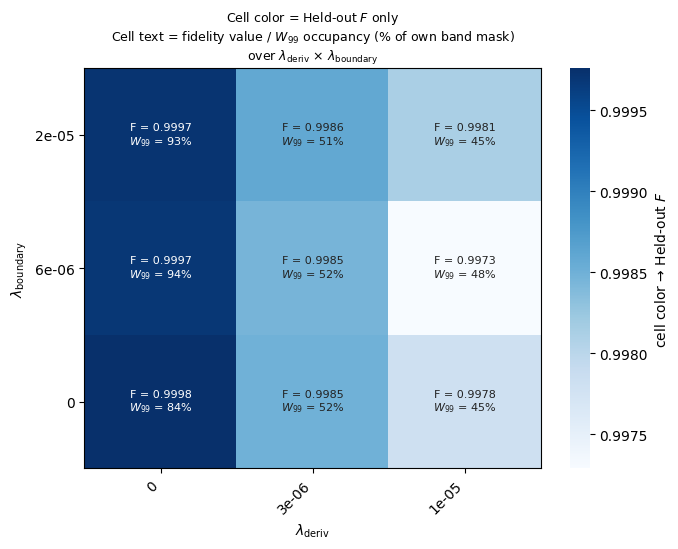

In [26]:
# grid3x3_2 (two-phase, 3-seed) was already loaded in the "Loading the sweep" cell above.
# pv.plot_grid_heatmap aggregates over seeds internally when a `seed` column is present,
# so this is a genuine 3-seed average with no extra code.
fig = pv.plot_grid_heatmap(grid3x3_2, "deriv", "boundary",
                           save_path="figures/penalty_grid_heatmap_3x3")

In [27]:
# grid3x3_2 is genuinely new data (two-phase, 3 seeds) -- unlike the RETIRED single-phase
# 3x3 corner, which was just the 5x5 grid's corner re-rendered (a cache hit, confirmed by
# byte-identical config_hash matches in an earlier version of this cell). Reconstruct that
# single-phase, single-seed baseline from `grid` (via the `corner` set already built above)
# and compare the two protocols on the same 9 (lambda_deriv, lambda_boundary) cells.
grid_3x3_1phase = grid[
    grid.apply(lambda r: (r.lambda_deriv, r.lambda_boundary) in corner, axis=1)
]

agg_2phase = pv.aggregate_seeds(grid3x3_2)
merged = agg_2phase.merge(
    grid_3x3_1phase[["lambda_deriv", "lambda_boundary", "F_ped_heldout_mean"]],
    on=["lambda_deriv", "lambda_boundary"], suffixes=("_2phase", "_1phase_1seed"),
)
merged["dF"] = merged["F_ped_heldout_mean_2phase"] - merged["F_ped_heldout_mean_1phase_1seed"]

print(f"{len(merged)}/9 cells matched by (lambda_deriv, lambda_boundary)")
print(f"protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: "
      f"mean {merged['dF'].mean():+.2e}, "
      f"range [{merged['dF'].min():+.2e}, {merged['dF'].max():+.2e}]")
print(f"within-2-phase seed spread (max std across the 9 cells): "
      f"{agg_2phase['F_ped_heldout_mean_std'].max():.2e}")

9/9 cells matched by (lambda_deriv, lambda_boundary)
protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: mean +7.87e-04, range [+1.09e-04, +1.88e-03]
within-2-phase seed spread (max std across the 9 cells): 9.88e-04


**Table 14. The two protocols on the same nine grid-corner cells.** Matched by
$(\lambda_{\mathrm{deriv}}, \lambda_{\mathrm{boundary}})$: the two-phase 3-seed mean minus the
single-phase 1-seed value, cell by cell. All nine matched.

The protocol delta averages $+7.87\times10^{-4}$ over a range of $[+1.09, +18.8]\times10^{-4}$,
against a within-two-phase seed spread reaching $9.88\times10^{-4}$ on a single cell. **The
protocol difference and the seed noise are the same size**, so this is consistent with a mild
two-phase improvement without establishing one — and the comparison is additionally lopsided,
three seeds against one. §11.2 asks the same question of the OFAT ladder, where both sides have
multiple seeds.

*(This caption is new; the table itself is the frozen pre-ramp output of the cell above, and was
referenced by number elsewhere in the notebook without ever having been captioned.)*

**Figure 5. The 3x3 corner, retrained under the two-phase protocol, 3-seed average.**
Same low-\(\lambda_{\mathrm{deriv}}\) block as the bottom-left of Figure 3, but every cell here
is a fresh two-phase pulse (cold-start \(\mathrm{trunc\_list}=[22,26]\) for 1000 iters, then
warm-started \(\mathrm{trunc\_list}=[26]\) for 1500 more), averaged over seeds 42, 43, 44 --
unlike the retired single-phase 3x3 corner (a cache hit off the 5x5 grid, confirmed byte-identical
in an earlier version of this section), this is genuinely new, independently measured data.
**Table 14** (the cell above) compares the two protocols on the same 9 cells: the 2-phase
3-seed mean differs from the historical 1-phase, 1-seed value by \(+7.87\times10^{-4}\) on
average (range \([+1.09, +18.8]\times10^{-4}\), always positive -- the two-phase protocol
never scored lower here), against a within-2-phase seed spread of up to \(9.88\times10^{-4}\).
The two figures are comparable in size: the protocol difference sits at, not clearly above,
the seed-to-seed noise floor -- the same "is this signal or floor" framing this document applies to its post-ramp half. It is consistent with a mild improvement, not established as one
at this seed count.

### 11.2 The OFAT ladder: single-phase vs two-phase

Same question as §11.1's Table 14, asked of the OFAT ladder instead of the grid corner:
`df` (single-phase, seeds 42-44) against `df2` (two-phase, seeds 42-46), matched by `label`.

In [28]:
# Cost: wall-clock per FRESH training run (train_time_s is NaN for cache-hit reused pulses).
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

for name, d in [("single-phase OFAT", df), ("single-phase grid", grid),
                ("two-phase OFAT", df2), ("two-phase grid", grid3x3_2)]:
    t = d["train_time_s"].dropna()
    print(f"{name:20s}: n_fresh={len(t):3d}  mean={t.mean():7.1f} s ({t.mean()/60:5.1f} min)  "
          f"min={t.min():7.1f}  max={t.max():7.1f}")

ratio_ofat = df2["train_time_s"].dropna().mean() / df["train_time_s"].dropna().mean()
ratio_grid = grid3x3_2["train_time_s"].dropna().mean() / grid["train_time_s"].dropna().mean()
print(f"\ntwo-phase / single-phase mean cost ratio: OFAT {ratio_ofat:.2f}x, grid {ratio_grid:.2f}x")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
single-phase OFAT   : n_fresh= 45  mean= 1253.0 s ( 20.9 min)  min=  826.3  max= 1448.7
single-phase grid   : n_fresh= 25  mean=  956.4 s ( 15.9 min)  min=  806.0  max= 2738.3
two-phase OFAT      : n_fresh= 75  mean= 2120.0 s ( 35.3 min)  min= 1253.4  max= 7871.2
two-phase grid      : n_fresh= 27  mean= 1682.8 s ( 28.0 min)  min= 1334.2  max= 1931.8

two-phase / single-phase mean cost ratio: OFAT 1.69x, grid 1.76x


In [29]:
# Fidelity delta, matched by label (same method as Table 14 in §11.1), plus convergence.
g1 = df.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
g2 = df2.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
ofat_compare = g1.join(g2, lsuffix="_1phase", rsuffix="_2phase", how="inner")
ofat_compare["dF"] = ofat_compare["mean_2phase"] - ofat_compare["mean_1phase"]
ofat_compare = ofat_compare.sort_values("dF")

print(ofat_compare[["mean_1phase", "count_1phase", "mean_2phase", "count_2phase", "dF"]]
      .to_string(float_format=lambda x: f"{x:.6f}"))
print(f"\ndelta stats: mean={ofat_compare['dF'].mean():+.2e}  "
      f"range [{ofat_compare['dF'].min():+.2e}, {ofat_compare['dF'].max():+.2e}]")
print(f"configs scoring higher under two-phase: {(ofat_compare['dF']>0).sum()} of {len(ofat_compare)}")

n_conv_1phase = int((df["converged"] == True).sum())
n_conv_2phase = int((df2["converged"] == True).sum())
print(f"\nconvergence (scipy success flag; two-phase reflects phase 2 only):")
print(f"  single-phase: {n_conv_1phase}/{len(df)} converged, "
      f"all others hit the {int(df['iterations'].max())}-iteration cap")
print(f"  two-phase   : {n_conv_2phase}/{len(df2)} converged, "
      f"iterations range [{df2['iterations'].min():.0f}, {df2['iterations'].max():.0f}]")

                                                         mean_1phase  count_1phase  mean_2phase  count_2phase        dF
label                                                                                                                  
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_ampmax=12     0.997508             3     0.997103             5 -0.000405
deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.998760             3     0.998850             5  0.000090
deriv=1e-05_boundary=0_amp=8e-05_disc=0.5                   0.997750             3     0.997859             5  0.000108
deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.999236             3     0.999357             5  0.000121
deriv=0_boundary=2e-05_amp=8e-05_disc=0.5                   0.999580             3     0.999757             5  0.000177
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5               0.997753             3     0.998057             5  0.000304
deriv=1e-05_boundary=2e-05_amp=8e-05_dis

14 of the 15 OFAT configs score higher (mean held-out $F$) under two-phase; only
`deriv=1e-05_boundary=2e-05_..._ampmax=12` scores lower. Only the single largest positive
delta clears the $\sim\!10^{-3}$ pre-ramp noise floor (see the banner) -- the rest, positive and
negative alike, sit inside it. Combined with the cost finding above (two-phase costs
\(\sim\)1.8x more per config): **switching to two-phase training is not currently justified
by this data** -- the fidelity gain it might be producing is not distinguishable from basin
noise at this seed count, and it is not cheap even if it were real. What it does provide is
the extra raw trials pooled into §14/Figure 8.

Saved figures/penalty_ofat_two_phase.png / .pdf


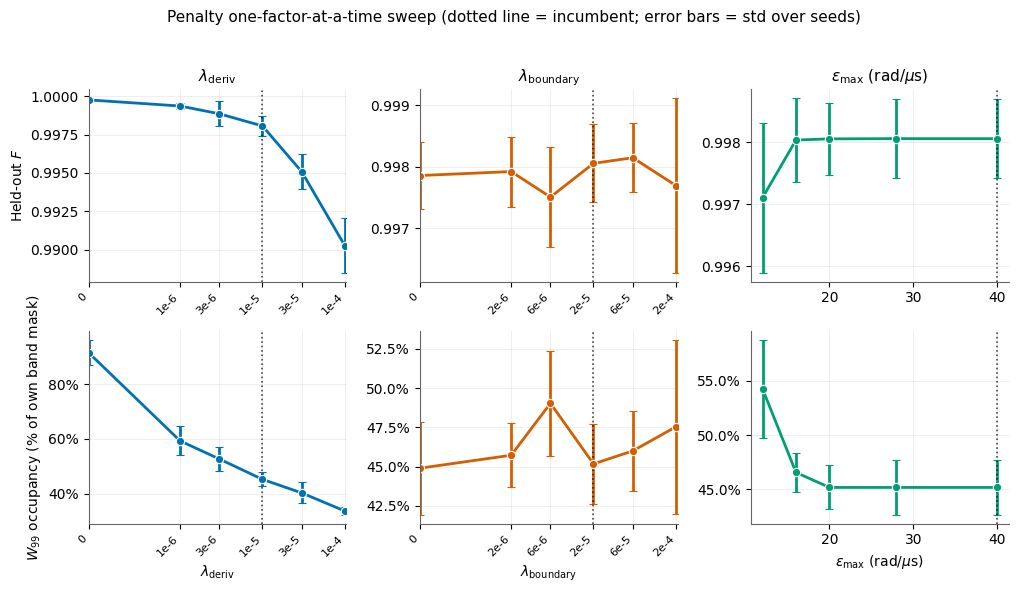

In [30]:
fig = pv.plot_ofat(df2, save_path="figures/penalty_ofat_two_phase")


In [31]:
# Per-axis shape of the two-phase ladder: range of the seed-mean fidelity and the
# largest per-point seed std (the error bar itself drawn above), so the caption below
# can state whether the ladder's movement clears its own noise -- same framing as # the pre-ramp floor and §11.2's delta table above.
agg2 = pv.aggregate_seeds(df2)
ofat2 = agg2[agg2["swept"].isin(pv.AXIS_NAMES)]
rows = []
for pname in pv.AXIS_NAMES:
    sub = ofat2[ofat2["swept"] == pname]
    if sub.empty:
        continue
    rows.append({
        "axis": pname,
        "n_points": len(sub),
        "F_range": sub["F_ped_heldout_mean"].max() - sub["F_ped_heldout_mean"].min(),
        "F_max_std": sub["F_ped_heldout_mean_std"].max(),
        "F_min": sub["F_ped_heldout_mean"].min(),
        "F_max": sub["F_ped_heldout_mean"].max(),
    })
ladder2_summary = pd.DataFrame(rows).sort_values("F_range", ascending=False)
ladder2_summary

,axis,n_points,F_range,F_max_std,F_min,F_max
0,deriv,6,0.009496,0.001786,0.990260,0.999757
2,amp_max,4,0.000954,0.001212,0.997103,0.998057
1,boundary,5,0.000640,0.001422,0.997508,0.998148


**Figure 6. The OFAT ladder, two-phase protocol (seeds 42-46).** Same `pv.plot_ofat`, same panel layout, incumbent dotted line, and error-bar convention (std across seeds) as Figure 1 -- here drawn from `df2` instead of `df`. $\lambda_{\mathrm{deriv}}$ (left) is the only axis that visibly trends: held-out $F$ falls monotonically from $0.999757$ at $\lambda_{\mathrm{deriv}}=0$ to $0.990260$ at $10^{-4}$, a range of $9.50\times10^{-3}$ -- about $5\times$ its own largest per-point error bar ($1.79\times10^{-3}$) and essentially the same magnitude as Figure 1's single-phase range over the identical six values ($1.04\times10^{-2}$). The same axis drives essentially all of the occupied-width trade: $W_{99}$ falls from $91.5\%$ to $33.6\%$ of the transmon's own mask across the same sweep -- the same fidelity-for-bandwidth trade Figure 1 shows. $\lambda_{\mathrm{boundary}}$ (center) and $\varepsilon_{\mathrm{max}}$ (right) both wander non-monotonically inside their own error bars -- ranges of $6.40\times10^{-4}$ and $9.54\times10^{-4}$ against per-point noise up to $1.42\times10^{-3}$ and $1.21\times10^{-3}$ -- neither clears its own point-to-point noise, let alone the $\sim\!10^{-3}$ pre-ramp campaign-wide floor; their $W_{99}$ panels are similarly flat ($44.9\%$-$49.0\%$ and $45.2\%$-$54.3\%$, each within one point's own error bar of the next).

Read together with §11.2's table above, this is the same shape Figure 1 shows: one axis ($\lambda_{\mathrm{deriv}}$) dominates by roughly a decade, the other two are statistically inert at this seed count. That agreement is itself the useful reading of this figure -- it means §11.2's per-config deltas (mean $+3.39\times10^{-4}$, only the single largest case clearing the noise floor) are training-schedule noise scattered around the same underlying response, not evidence of a different one. This figure adds no new axis-effect finding; it confirms, under a second and considerably more expensive training schedule, the one Figure 1 already established.

# 12. Caveats and outstanding work

Sections 12.1-12.2 cover the single-phase campaign (§1-§8), the primary result. §12.3
covers the two-phase replication (§11, §13, §15) separately -- its limitations overlap but
are not identical, and it carries one risk single-phase does not.

### 12.1 Blocks the budget verdict (single-phase)

> **Threshold note.** The bullets below were written against the **70% budget with no fidelity
> floor**, and their point counts ("6.6 points inside", "9.1–27.8 points outside") are distances to
> that line. The selection rule has since tightened to $W_{99} \leq 50\%$ **and**
> $F_{\mathrm{held}} \geq 0.995$, which the cells in §13–§15 now apply. The drift concern is
> unchanged in kind and worse in degree: a tighter line has more configurations near it, so less
> margin absorbs the same unconverged drift. §8.5's closing paragraph states the post-ramp version.

- **No run converged (45/45 capped), and spectral width had not stopped moving.** The fidelity
  ordering survived a 750-iteration continuation; the width did not settle. Over 750 further
  iterations the incumbent shed 8.3 points of its allowance and the recommendation gained 2.8.
  The recommendation stays 6.6 points inside the budget and the rejected family sits 9.1–27.8
  points outside it, so the margin now absorbs a drift of that size, but **neither continued
  configuration was one the budget rejects**, so the marginal loser's drift is unmeasured.
  **Re-running at higher `maxiter`, and continuing `deriv=0_boundary=6e-06` in particular, is the
  first outstanding item.** That configuration is the cavity-binding one of §8.3, so its drift
  would have to be measured on the cavity drive.
- **`occ99_frac` is still a soft, post-hoc budget, not a hardware spec.** It is an
  occupied-bandwidth figure at a stated power criterion, charged against the right allowance, but
  the genuinely hard spectral constraint remains the band-limit projection ($\pm27$ / $\pm33$ MHz),
  enforced by construction and never violated regardless of the weights.

### 12.2 Limits on precision (single-phase)

- **Three seeds (42, 43, 44) for the real axes; the retired `disc_null` ladder three seeds too.**
  That ladder -- pre-ramp, no longer loaded by this notebook, and no longer regenerable -- gave a
  `floor_basin` of $\approx 4.7\times10^{-4}$ (mean of three independent per-seed ranges, itself a
  noisy statistic) and a cross-seed std of $1.15\times10^{-3}$, the same statistic as the real
  axes' own cross-seed std rather than a range compared against a std. Those are the numbers that
  apply to the pre-ramp results in this half. **They are not §6.2's floor**, which is a separate
  post-ramp measurement ($1.48\times10^{-3}$) built from the $\epsilon_{\max}$ null rungs. At $n=3$,
  $\lambda_{\mathrm{deriv}}$'s effect ($1.04\times10^{-2}$ range) clears the cross-seed-std
  floor by roughly $9\times$; the
  recommendation's margin over incumbent does not ($t(2) = 2.9$ vs. the $4.30$ critical value).
  Separating $10^{-6}$ from $10^{-5}$ specifically would take on the order of a decade more
  seeds.
- **Two of the four weights do nothing here.** $\lambda_{\mathrm{amp}}$ multiplies an
  identically-zero term; $\lambda_{\mathrm{disc}}$ contributes $\sim\!10^{-7}$ against an $O(1)$
  objective. Both are correctly implemented: they simply never activate as configured (§6.1).
- **$W_{99}$ is quantised to one FFT bin (0.909 MHz, i.e. 1.7 points of the cavity allowance or
  1.4 of the transmon), and its replicate-pair noise floor is two bins** (pre-ramp). Differences at
  that level between configurations are the metric's resolution and the optimizer's chaos, not a
  ranking, which is what the $\lambda_{\mathrm{boundary}} = 0$ row of this campaign's
  negative-control table showed. (Section 7's Table 6 is the post-ramp controls and has no
  `boundary` row.)
- **The held-out set includes under-resolved truncations.** $n_c = 16, 18$ do not fully contain the
  $\alpha = \sqrt{3}$ cat ($\bar n = 3$), so they depress the held-out mean and dominate
  `robustness_spread` for *every* recipe. They are kept deliberately (a pulse that exploits the
  truncation wall fails there first), but the absolute value of `F_ped_heldout_mean` should not be
  quoted as "the gate fidelity". The per-truncation breakdown in the manifest JSON is the honest
  view.
- **The OFAT and grid ladders do not share cache entries where they should.**
  `BASELINE[x] * 3` and the grid's literal `3e-5` differ in the sixteenth digit, so two
  configurations were trained twice instead of reused. Rounding the OFAT rungs to a fixed precision
  would fix it, at the cost of invalidating those cache entries. Left as-is so the committed code
  reproduces the committed CSVs exactly. The pre-ramp floor was built out of that accident;
  the post-ramp one (§6.2) is built by design instead, from the $\epsilon_{\max}$ null rungs.

In [32]:
# Two-phase convergence, combined OFAT + grid-corner pool (both loaded above, §11).
# converged reflects phase 2's scipy flag only -- phase 1's is never surfaced (§2.6, Appendix A.1).
two_pool_conv = pd.concat([df2, grid3x3_2], ignore_index=True)
n_conv = int((two_pool_conv["converged"] == True).sum())
print(f"two-phase (phase-2 flag only): {n_conv}/{len(two_pool_conv)} converged, "
      f"iterations range [{two_pool_conv['iterations'].min():.0f}, "
      f"{two_pool_conv['iterations'].max():.0f}]")

two-phase (phase-2 flag only): 4/102 converged, iterations range [769, 1500]


### 12.3 The two-phase replication: same limitations, plus one of its own

- **Convergence is less settled, not more.** Single-phase's 45/45-capped rate (§12.1) at
  least applies to every configuration under one identical stopping rule. Two-phase's
  `converged` flag reflects phase 2 only -- phase 1's is never surfaced (§2.6, Appendix A.1) -- and only
  4/102 runs across the full two-phase pool hit it (iterations [769, 1500], computed above). No
  continuation test like §4.3's has ever been run on a two-phase pulse, so whether spectral
  width has settled under this schedule is entirely unmeasured, not just unresolved.
- **Seeds and coverage are thinner where it matters most.** The OFAT ladder has 5 seeds
  (42-46) against single-phase's 3, but the grid exists only as the low-$\lambda_{\mathrm{deriv}}$
  3x3 corner -- never the full 5x5 (§13). §13's two-phase recommendation is therefore drawn
  from 19 aggregated configs, not 33, and says nothing outside that overlap. There is also no
  two-phase counterpart to the pre-ramp three-seed `disc_null` measurement: §11.2 and §13 compare
  two-phase deltas against the *single-phase, pre-ramp* noise floor, because no basin-noise floor
  has been independently measured under the two-phase schedule itself.
- **A risk single-phase does not have: the wall-exploiting basin (§15).** Phase 2's
  single-truncation warm start structurally reproduces the failure mode the cold-start
  protocol exists to avoid. Seed 48 reached an overfit gap of 0.88 at one config where seed 47,
  same weights, stayed near zero (§15.2) -- a basin effect that widening phase 1's truncation
  set only partially rescues (83%, not 100%, §15.3), and no detector currently screens for it
  (§15.5). Every two-phase aggregate quoted in this notebook (§11, §13, §14) could in
  principle be diluted by an unflagged seed like this without it showing.
- **Net: a check on the recommendation, not a replacement for the training that produced it.**
  Two-phase costs ~1.8x more per config (§A.1/§11.2) for a fidelity effect mostly inside the
  ~1e-3 noise floor (§11.2), and it independently selects the same recipe as single-phase
  (§13, delta $+1.2\times10^{-4}$, inside noise) -- reassuring, but drawn from the thinner,
  less-validated dataset described above.

### 12.4 Scope

- **Per-gate.** This is gate X. A recipe selected on X is a starting point for the other gates, not
  a validated setting for them.

# 13. Single-phase vs. two-phase, averaged

§11 already compared the two training protocols cell-by-cell, matched by label (Table 14,
§11.1/§11.2): one recipe's single-phase mean fidelity next to its two-phase mean fidelity, one
row at a time. This section asks the same question the way Figure 4 asks it -- as a Pareto front
and a recommendation filtered by both the spectral budget and the fidelity floor, not a table --
so the two protocols are compared exactly the way the recommendation itself gets chosen. It is the aggregated (seed-mean) counterpart to the
unaggregated, per-trial Figure 8 (§14, next): one marker per (config, protocol) here, one marker
per (config, seed) trial there.

Two pools, aggregated separately by protocol:

- **single-phase** = `df` (OFAT, seeds 42-44) + `grid` (the full 5x5, seed 42) -- identical to
  `combined` above (Figure 4's data), aggregated separately here only so it can be plotted
  alongside its two-phase counterpart.
- **two-phase** = `df2` (OFAT, seeds 42-46) + `grid3x3_2` (the low-\(\lambda_{\mathrm{deriv}}\)
  3x3 corner, seeds 42-44).

**Coverage is not symmetric.** Two-phase exists only for the OFAT ladder and the 3x3 corner --
19 distinct configurations after aggregation, all of which are also present single-phase -- not
for the full 5x5 grid. Every comparison below is restricted to that overlap; it says nothing
about whether two-phase would agree or disagree anywhere outside it.

In [33]:
# Same protocol pools Figure 8's `all_trials` draws on (df, grid, df2,
# grid3x3_2), aggregated separately BY PROTOCOL instead of pooled per-trial.
single_pool = pd.concat([df, grid], ignore_index=True)
two_pool = pd.concat([df2, grid3x3_2], ignore_index=True)

agg_single = pv.aggregate_seeds(single_pool)
agg_two = pv.aggregate_seeds(two_pool)

front_single = agg_single.iloc[pv.pareto_front(agg_single)]
front_two = agg_two.iloc[pv.pareto_front(agg_two)]

rec_single = pv.recommend(agg_single, max_cost=COST_BUDGET,
                          min_fidelity=MIN_FIDELITY)
rec_two = pv.recommend(agg_two, max_cost=COST_BUDGET, min_fidelity=MIN_FIDELITY)

# Sanity check: `single_pool` IS `combined` (Figure 4's data), so `rec_single`
# must reproduce Figure 4's `rec` exactly -- this is a guarantee, not a coincidence.
assert rec_single["label"] == rec["label"]
assert np.isclose(rec_single["F"], rec["F"])
print(f"rec_single reproduces Figure 4's rec: label matches, "
      f"F={rec_single['F']:.6f} (Figure 4: {rec['F']:.6f})\n")

def _n_feasible(a):
    return int(((a[COST_METRIC] <= COST_BUDGET)
                & (a["F_ped_heldout_mean"] >= MIN_FIDELITY)).sum())


print(f"single-phase: {len(agg_single):2d} configs, {len(front_single):2d} on the front, "
      f"{_n_feasible(agg_single):2d} feasible (budget + floor)")
print(f"two-phase   : {len(agg_two):2d} configs, {len(front_two):2d} on the front, "
      f"{_n_feasible(agg_two):2d} feasible (budget + floor)")

print(f"\nrec_single: {rec_single['label']:46s} F={rec_single['F']:.6f}  "
      f"cav={rec_single['occ99_frac_cav']:.1%}  tra={rec_single['occ99_frac_tra']:.1%}")
print(f"rec_two   : {rec_two['label']:46s} F={rec_two['F']:.6f}  "
      f"cav={rec_two['occ99_frac_cav']:.1%}  tra={rec_two['occ99_frac_tra']:.1%}")
print(f"\nsame recipe: {rec_single['label'] == rec_two['label']}   "
      f"F delta (two-phase - single-phase): {rec_two['F'] - rec_single['F']:+.2e}")

rec_single reproduces Figure 4's rec: label matches, F=0.997753 (Figure 4: 0.997753)

single-phase: 33 configs, 12 on the front,  8 feasible (budget + floor)
two-phase   : 19 configs, 11 on the front, 10 feasible (budget + floor)

rec_single: deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5  F=0.997753  cav=41.5%  tra=47.8%
rec_two   : deriv=1e-05_boundary=6e-05_amp=8e-05_disc=0.5  F=0.998148  cav=36.0%  tra=46.0%

same recipe: False   F delta (two-phase - single-phase): +3.95e-04


Saved figures/penalty_pareto_by_protocol.png / .pdf


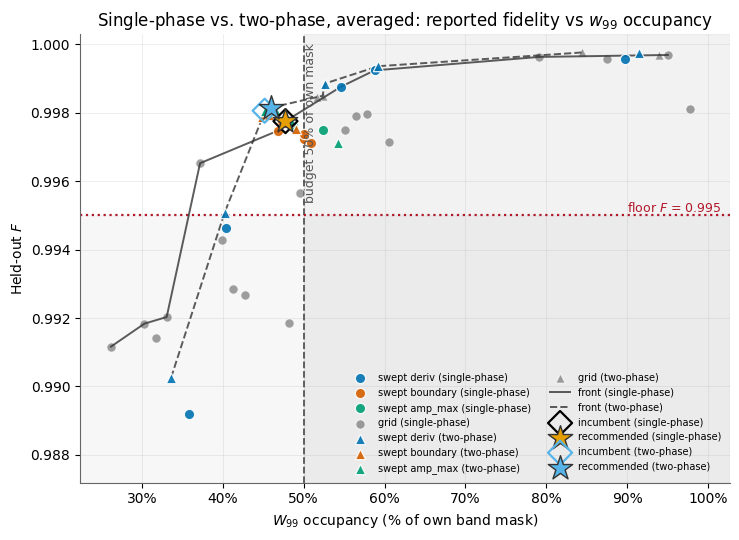

In [34]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Circle = single-phase, triangle = two-phase -- the same convention Figure 8
# (the unaggregated, per-trial comparison) uses below.
pools = [("single-phase", agg_single, "o"), ("two-phase", agg_two, "^")]
for proto_name, agg, marker in pools:
    for pname in pv.AXIS_NAMES:
        sub = agg[agg["swept"] == pname]
        if sub.empty:
            continue
        ax.scatter(sub[COST_METRIC], sub["F_ped_heldout_mean"], s=55, marker=marker,
                   color=pv.SWEPT_COLORS.get(pname, "#777777"), edgecolor="white",
                   linewidth=0.9, alpha=0.9, label=f"swept {pname} ({proto_name})", zorder=3)
    other = agg[~agg["swept"].isin(pv.AXIS_NAMES)]
    if not other.empty:
        ax.scatter(other[COST_METRIC], other["F_ped_heldout_mean"], s=45, marker=marker,
                   color="#777777", alpha=0.7, edgecolor="white", linewidth=0.8,
                   label=f"grid ({proto_name})", zorder=2)

# One front line per protocol -- solid single-phase, dashed two-phase (its
# front is drawn from a much smaller, non-overlapping-in-scope pool, see above).
ax.plot(front_single[COST_METRIC], front_single["F_ped_heldout_mean"], color="#333333",
        linewidth=1.4, alpha=0.8, zorder=2, label="front (single-phase)")
ax.plot(front_two[COST_METRIC], front_two["F_ped_heldout_mean"], color="#333333",
        linewidth=1.4, linestyle="--", alpha=0.8, zorder=2, label="front (two-phase)")

# Each protocol's own incumbent (diamond) and own recommendation (star),
# colored to pair with each other: gold/black = single-phase (identical to
# Figure 4's), blue = two-phase.
protocol_style = [("single-phase", agg_single, rec_single, pv.BASELINE_COLOR, "#E69F00"),
                   ("two-phase", agg_two, rec_two, "#56B4E9", "#56B4E9")]
for proto_name, agg, r, diamond_color, star_color in protocol_style:
    base_row = agg[agg["is_baseline"]]
    if not base_row.empty:
        ax.scatter(base_row[COST_METRIC], base_row["F_ped_heldout_mean"], s=150, marker="D",
                   facecolor="none", edgecolor=diamond_color, linewidth=1.6, zorder=4,
                   label=f"incumbent ({proto_name})")
    ax.scatter([r["cost"]], [r["F"]], s=340, marker="*", color=star_color,
               edgecolor="#333333", linewidth=1.0, zorder=5,
               label=f"recommended ({proto_name})")

x_hi = max(float(agg_single[COST_METRIC].max()), float(agg_two[COST_METRIC].max()),
           COST_BUDGET) * 1.05
ax.axvspan(COST_BUDGET, x_hi, color="#999999", alpha=0.12, zorder=0)
ax.axvline(COST_BUDGET, color="#555555", linestyle="--", linewidth=1.3, zorder=1)
ax.text(COST_BUDGET, 0.98, f"  budget {COST_BUDGET:.0%} of own mask",
        transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="left",
        fontsize=9, color=pv.BUDGET_COLOR)
ax.set_xlim(right=x_hi)

# The fidelity floor, drawn the same way Figures 4 and 8 draw it (horizontal,
# dotted, FLOOR_COLOR) so the three panels state the same rule.
y_lo = min(float(agg_single["F_ped_heldout_mean"].min()),
           float(agg_two["F_ped_heldout_mean"].min()), MIN_FIDELITY)
y_bottom = min(ax.get_ylim()[0], y_lo - 0.002)
ax.set_ylim(bottom=y_bottom)
ax.axhspan(y_bottom, MIN_FIDELITY, color="#999999", alpha=0.08, zorder=0)
ax.axhline(MIN_FIDELITY, color=pv.FLOOR_COLOR, linestyle=":", linewidth=1.6, zorder=1)
ax.text(0.995, MIN_FIDELITY, f"floor $F$ = {MIN_FIDELITY:.3f}  ",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom",
        fontsize=9, color=pv.FLOOR_COLOR)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_xlabel(pv.METRIC_LABEL.get(COST_METRIC, COST_METRIC))
ax.set_ylabel(pv.METRIC_LABEL.get("F_ped_heldout_mean", "F_ped_heldout_mean"))
ax.set_title("Single-phase vs. two-phase, averaged: reported fidelity vs "
             f"{pv.METRIC_LABEL.get(COST_METRIC, COST_METRIC).split(' (')[0].lower()}")
pv._style_axis(ax)
ax.legend(frameon=False, fontsize=7, loc="lower right", ncol=2)
fig.tight_layout()
pv._save(fig, "figures/penalty_pareto_by_protocol")

**Figure 7. Single-phase vs. two-phase, seed-averaged: held-out fidelity against occupied
width, one marker per (config, protocol).** Circles are single-phase configurations, triangles
two-phase -- the same convention Figure 8 uses at the per-trial level. Solid line traces the
single-phase front, dashed the two-phase front (drawn only from its own, narrower
19-configuration coverage). Gold star and black diamond are single-phase's recommendation and
incumbent (identical to Figure 4's, by construction, confirmed by the assertion above); blue star
and blue diamond are two-phase's own. The dashed grey vertical is the 50% budget and the dotted
dark-red horizontal the $F \geq 0.995$ floor, the same pair Figures 4 and 8 draw.

**The sanity check holds.** `rec_single` reproduces Figure 4's recommendation exactly -- same
label, bit-identical $F$ -- since `single_pool` is the same data as `combined`. That is the
anchor the rest of this section reads against, and it is the one claim in this section that is
independent of where the thresholds sit.

> **This subsection's verdict reversed when the selection rule tightened, and the reversal is
> instructive rather than alarming.** At the historical 70% budget with no fidelity floor, both
> protocols landed on $\lambda_{\mathrm{deriv}} = 10^{-6}$ and the section's headline was *"the two
> protocols pick the same recipe"*. At $W_{99} \leq 50\%$ **and** $F_{\mathrm{held}} \geq 0.995$
> they do not. Nothing was retrained; the pulses, their fidelities and their widths are the same
> frozen pre-ramp numbers as before. Only the line moved.

**The two protocols now pick different recipes, and neither pick is resolvable.** Single-phase
lands on the incumbent itself ($\lambda_{\mathrm{deriv}} = 10^{-5}$, $\lambda_{\mathrm{boundary}}
= 2\times10^{-5}$, $F = 0.997753$ at 47.8% of the transmon's allowance); two-phase lands on the
same $\lambda_{\mathrm{deriv}}$ with $\lambda_{\mathrm{boundary}} = 6\times10^{-5}$
($F = 0.998148$ at 46.0%). The gap between them is $+3.95\times10^{-4}$ in favour of two-phase --
well under the $\sim\!10^{-3}$ pre-ramp noise floor (see the banner and §11.2), so this is two
protocols disagreeing *within noise* about which of two near-identical recipes to name, not a
protocol effect.

**Why the winner moved.** The $10^{-6}$ recipe both protocols used to pick costs 57.2% of the
transmon's allowance in the post-ramp campaign and a comparable share here; a 50% budget will not
pay for it, under either protocol. Once it is out of the feasible set, what remains on each
protocol's front is a cluster of configurations separated by less than the floor, and the argmax
falls wherever that protocol's basin noise happens to put it. **The two protocols disagreeing here
is a restatement of §8.4's finding on different data**: tighten the budget past the recipes that
resolvably beat the incumbent, and the rule is left ranking on differences it cannot measure.
What *would* be alarming -- a protocol effect large enough to clear the floor -- is still absent.

**Where the protocols do differ is the trade each one reports against its own incumbent, not the
winner.** Two-phase's incumbent pulse -- same weights, different training schedule -- is itself
narrower-band than single-phase's (cavity 35.4% vs 41.5% of allowance, transmon 45.2% vs 47.8%),
a $+3.0\times10^{-4}$ fidelity difference at the identical recipe, also inside the noise floor.
But because two-phase's incumbent starts narrower, the same $\lambda_{\mathrm{deriv}}$ cut costs
proportionally more bandwidth under two-phase -- cavity +10.8 points and transmon +14.0 points,
against the pre-ramp single-phase campaign's +5.1/+11.0 -- and peak amplitude rises by +3.5 rad/µs
against single-phase's +1.8. That comparison is stated at the $10^{-6}$ recipe and is unaffected
by the thresholds, since it is a difference between two trained pulses rather than a selection.

**Coverage, again.** 12 of single-phase's 33 configurations sit on its front against 11 of
two-phase's 19; 8 of 33 are single-phase feasible under the current rule against 10 of 19
two-phase. Both counts come from pools of different size and composition (two-phase has no full
5x5 grid), so front-size or feasible-count comparisons between the two lines are not
apples-to-apples -- only the matched, same-recipe comparisons above are. The tightened rule makes
this caveat sharper, not weaker: the feasible counts moved by very different amounts (28→8 and
16→10) precisely because the two pools are differently composed.


# 14. Every trial, unaggregated: searching for the single best run

Sections 7 and 9 above answer "which config is best on average" -- every number there is a
seed mean, and the pre-ramp floor's whole point is that seed-to-seed noise (\(\sim\!10^{-3}\)) has to be
respected before one config is called better than its neighbours. This section asks a
different question: forget averaging, what is the single best INDIVIDUAL run this campaign
has produced? A deployed pulse is one specific trained waveform, not a mean, so it is worth
knowing what the best individual draw looked like, and by how much (if at all) it beats
§8.4's mean-based recommendation.

This is deliberately NOT a competing recommendation. Picking the best of many trials is
optimistic by construction -- the more trials pooled, the luckier the winner can get purely by
chance, independent of whether its config is actually better. Read its margin over §8.4's
pick against the pre-ramp noise floor before drawing any conclusion from it.

`all_trials` pools every trial ever run in this campaign, across every protocol: the
single-phase OFAT ladder (`df`, seeds 42-44), the single-phase 5x5 grid (`grid`, seed 42),
the two-phase 3x3 corner (`grid3x3_2`, seeds 42-44), and the two-phase OFAT ladder (`df2`,
seeds 42-46) loaded below. The retired `disc_null`
ladder is not in the pool and is no longer loaded at all: it was a calibrated null, never a
ranking candidate.

In [35]:
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

all_trials = pd.concat(
    [df, grid, grid3x3_2, df2], ignore_index=True
).drop_duplicates(subset=["config_hash", "seed"])

print(f"all_trials: {len(all_trials)} individual trials, "
      f"{all_trials.config_hash.nunique()} distinct trained pulses, "
      f"{all_trials.label.nunique()} distinct recipes, "
      f"protocols={sorted(all_trials.get('protocol', pd.Series(dtype=str)).fillna('single_phase').unique())}")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
all_trials: 150 individual trials, 150 distinct trained pulses, 31 distinct recipes, protocols=['single_phase', 'two_phase']


Saved figures/penalty_all_trials.png / .pdf


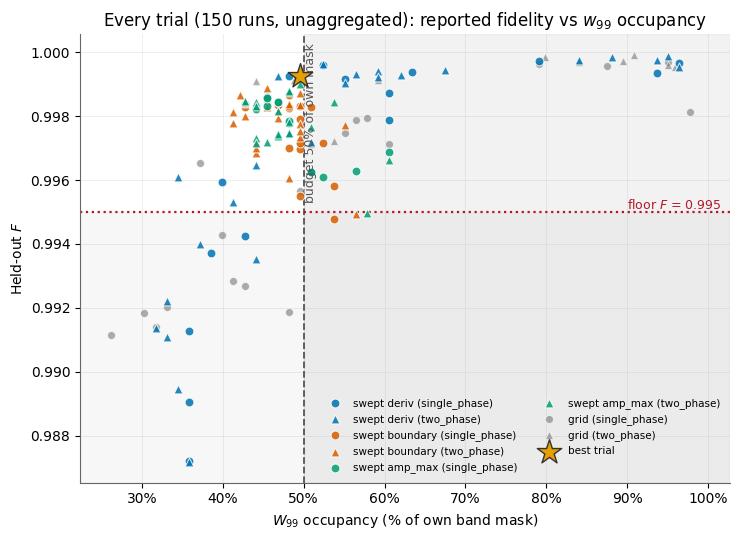

In [36]:
fig, best = pv.plot_all_trials(all_trials, save_path="figures/penalty_all_trials",
                               max_cost=COST_BUDGET, min_fidelity=MIN_FIDELITY)

**Figure 8. Every individual trial, no seed-averaging.** One marker per (config, seed) run;
circles are single-phase trials, triangles two-phase. Color follows the same swept-axis
convention as Figure 4; grid trials (both protocols) get the neutral grey. The shaded region
and dashed line are the same 50% budget as Figure 4, and the dotted dark-red horizontal line is
the same $F \geq 0.995$ floor (both come from the shared `pv._draw_constraints` helper, so the two
figures cannot drift apart). The gold star is the single best feasible trial by held-out fidelity (`find_best_trial`, printed below) -- NOT the
seed-mean recommendation of Figure 4/§8.4, see this section's opening caveat about reading
too much into it.

In [37]:
best = pv.find_best_trial(all_trials, max_cost=COST_BUDGET,
                          min_fidelity=MIN_FIDELITY)
print(f"best individual trial (budget + floor feasible, highest held-out F):")
print(f"  label     : {best['label']}")
print(f"  seed      : {best['seed']}")
print(f"  protocol  : {best.get('protocol', 'single_phase')}")
print(f"  F_held    : {best['F']:.6f}")
print(f"  {COST_METRIC}     : {best['cost']:.1%} of the binding drive's own mask")
print(f"  config_hash: {best['config_hash']}")

print(f"\nvs. Figure 4's seed-mean recommendation:")
print(f"  label     : {rec['label']}")
print(f"  F_held    : {rec['F']:.6f}  (mean over {int(rec.get('n_seeds', 1))} seed(s))")
print(f"  margin    : best trial exceeds the recommendation's mean by "
      f"{best['F'] - rec['F']:+.2e} -- compare against the pre-ramp noise floor "
      f"(\N{APPROXIMATELY EQUAL TO}1e-3) before reading this as a real gap.")

best individual trial (budget + floor feasible, highest held-out F):
  label     : deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5
  seed      : 46
  protocol  : two_phase
  F_held    : 0.999252
  occ99_frac     : 49.6% of the binding drive's own mask
  config_hash: b1aa90fd95c0a228

vs. Figure 4's seed-mean recommendation:
  label     : deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5
  F_held    : 0.997753  (mean over 3 seed(s))
  margin    : best trial exceeds the recommendation's mean by +1.50e-03 -- compare against the pre-ramp noise floor (≅1e-3) before reading this as a real gap.


**On reading the best-trial result.** A single lucky seed is not evidence that its config is
the true optimum -- it is evidence that, among the trials actually run, this is the best one
observed. If the margin over §8.4's recommendation is smaller than the pre-ramp \(\sim\!10^{-3}\)
noise floor, it is noise, exactly like every other sub-floor comparison flagged elsewhere in this half. If it is larger, that is a config/seed combination worth
a dedicated replication run before it is trusted, not a reason to deploy it directly -- the whole point of that floor was that single-seed conclusions are exactly the failure mode this
campaign was extended to guard against.

# 15. Caveat: seed 48 and the wall-exploiting basin

### 15.1 What happened

While live-validating §A.2's scheduling split, the same 6 OFAT configs were trained under two
different seeds: seed 47 (chained baseline) and seed 48 (split path). Seed 48's held-out
Pedersen fidelities came back badly degraded on several configs -- as low as 0.097 on one --
while seed 47's stayed healthy (~0.99+) throughout, on the identical configs. `F_coh_train`
(the trained-truncation objective, computed identically regardless of which process trained the
pulse) was healthy across **every** row for both seeds, ruling out a broken or crashed
optimization: this is a held-out generalization failure, not a training failure, and (having
been caught this way) not a bug in the scheduling split either.

**This data is reported here as fixed numbers, not recomputed by this notebook.** It comes from
throwaway diagnostic scripts run outside the sweep's cache/results pipeline, specifically so the
investigation couldn't touch the real `results/penalty_sweep_cache/` tree.

Overfit gap (`F_ped_trained_mean - F_ped_heldout_mean`, i.e. `score_pulse`'s own `overfit_gap`
field), seed 48, all 6 configs, phase-1-only vs. the final pulse after phase 2:

| config (deriv multiplier) | phase 1 gap (`[22,26]`@1000 iters) | final gap (`[26]`@1500 iters, after phase 2) |
|---|---|---|
| 0x | 0.029 | 0.054 |
| 0.1x | 0.027 | 0.077 |
| 0.3x | 0.029 | 0.099 |
| 1x (baseline) | 0.183 | 0.408 |
| 3x | 0.088 | 0.149 |
| 10x | 0.661 | 0.883 |

Every config gets worse from phase 1 to phase 2, consistent with phase 2 dropping to a single
training truncation and losing the cross-truncation averaging (Heeres Eq. 23/24) that
discourages truncation-specific overfitting in the first place.

### 15.2 A basin effect, not a config effect

`warm_start_seed` enters the computation in exactly one place: `smooth_initial_controls`'s
`np.random.default_rng(seed)` cold-start waveform (`core/grape_core.py:379-390`). Everything
downstream -- L-BFGS-B, the fidelity/gradient evaluation, the whole optimization trajectory --
is deterministic given that starting point. So this is entirely about which basin one specific
random initial pulse happens to land the optimizer in.

Seed 47, run on the identical 6 configs, stays near-zero gap throughout -- including at the same
10x-deriv config where seed 48 collapses to 0.88. Same penalty weights, same protocol, same
everything except the cold start. That rules out "this config is prone to wall exploitation" as
the explanation (it is fine under seed 47) and points squarely at seed 48's specific basin,
whose susceptibility scales with the derivative-penalty weight rather than being uniform across
configs -- counter to the naive intuition that heavier smoothing regularization should make
overfitting *harder*, not easier, and not something this investigation has a mechanistic
explanation for yet.

### 15.3 Does widening the training truncation set pull it out?

If phase 2's single-truncation objective is what removes the averaging that discourages
overfitting, does giving phase 1 the *full* production truncation set fix it at the source? A
follow-up test: seed 48, the 10x-deriv config, cold start (not warm-started from the existing
overfit phase-1 pulse), `trunc_list=[22,24,26]` -- the full `FIXED["trunc_list"]`, not phase 1's
usual `[22,26]` -- at phase 1's usual `maxiter=1000`.

| run | trunc_list | maxiter | overfit gap |
|---|---|---|---|
| phase 1 (original) | `[22,26]` | 1000 | 0.661 |
| this test | `[22,24,26]` | 1000 | **0.112** |
| final (phase 2, warm-started) | `[26]` | 1500 | 0.883 |

An 83% reduction -- the cross-truncation averaging mechanism clearly helps, confirming the
hypothesis from §15.1 -- but not a fix. 0.112 is still roughly 100x the campaign's established
~1e-3 basin-noise floor (pre-ramp), while seed 47 sits at essentially zero under identical
conditions. Even the full production truncation set, trained from a cold start with the full
phase-1 iteration budget, does not fully rescue this seed's basin.

### 15.4 Rescue vs. detect-and-avoid

The rescue attempt in §15.3 cost real compute (~9 min) and closed 83% of the gap, not 100%, with
no evidence that more iterations would close the rest reliably -- it used the *correct* full
objective and the *full* phase-1 iteration budget, and still left a result ~100x above the noise
floor. A different seed (47) costs nothing extra by comparison and generalizes cleanly from the
very first cold start. Multi-seed averaging, used everywhere else in this campaign, already
implicitly relies on exactly this asymmetry -- a seed like 48 gets silently absorbed into a mean
rather than flagged, which is how it went undetected until this scheduling-validation run
happened to train it. A screen-and-reseed step would make that explicit instead of accidental.

### 15.5 A proposed cheap detector (not implemented)

The cheapest available signal is one already computed for free during ordinary multi-truncation
training: the per-truncation fidelity spread across `trunc_list` that
`optimize_multi_state_pulse` already logs (seen directly in §15.3's own test output: "max
pairwise |F_i - F_j| across training truncations"). No extra `score_pulse` call is needed, unlike
a full held-out Pedersen check (§10's mid-training snapshots already cost ~7 s each for exactly
that reason). A detector could gate on this spread at phase 1's completion -- before committing
to phase 2's full 1500-iteration cost -- or earlier still, reusing the `SNAPSHOT_ITERS`-style
mid-training checkpoint machinery (`analysis/penalty_sweep.py`) already built for a different
purpose (§10).

Two things this proposal deliberately does NOT claim: (a) a specific threshold -- that needs
calibration against far more than the two seeds (47, 48) this investigation has, and picking one
here would be fitting noise; (b) that discarding flagged seeds should happen inside the sweep's
reported statistics -- it should be a training-time step (screen, then commit to whatever pulse
gets deployed), not a filter applied before a config's aggregate fidelity is reported, or it
would quietly inflate numbers relative to what an unscreened run actually produces.

This is the robustness question §A.2 flagged: a scheduling change that trains two-phase pulses
faster is only worth adopting once there is a cheap way to tell, before paying for the full
budget, whether the seed it just cold-started from is worth continuing at all.